In [1]:
import sys
import pickle
import copy
import os

import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

import networkx as nx
import pandas as pd
import numpy as np
import pypsa
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mplcolors
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
# import seaborn as sns
import matplotlib.lines as mlines
from sklearn.cluster import KMeans

import cartopy.crs as ccrs
import cartopy
import gzip


from tqdm.notebook import tqdm

%load_ext autoreload
%autoreload 2

root_path = '../' # This defaults to './', which should be the repository pathimport os
os.chdir(root_path)
sys.path.append(root_path)
from utils.visualization import get_actual_co2_level
from utils.config import path_to_pypsa_network_sclopf, path_to_cascade_results_sclopf, path_to_vis_results_sclopf, path_to_pre_outage_sclopf, path_to_evaluation_results_sclopf, path_to_figures_sclopf, path_to_sclopf_results
from utils import data_handling, cascade_simulation
from utils.config import path_to_indicator_vectors_sclopf
from utils.clustering_visualisation import truncate_colormap
from utils.alternative_split_indicator_vectors import get_indicator_vector_snapshot_weightings

n_nodes = 600

save_path = path_to_figures_sclopf
os.makedirs(save_path, exist_ok=True)

In [2]:
# import datetime

# dir = "/srv/data/jlange/power-system-split/no_extensions/results/sclopf/evaluation_results"
# for f_name in os.listdir(dir):
#     if "0.05" in f_name:
#         print(f_name)
#         mod_time = os.path.getmtime(os.path.join(dir, f_name))
#         new_var = datetime.datetime.fromtimestamp(mod_time).strftime('%Y-%m-%d %H:%M:%S')
#         print("Last modified:", new_var)
#         if new_var < "2025-07-10 00:00:00":
#             print("Deleting file:", f_name)
#             os.remove(os.path.join(dir, f_name))
#         else:
#             print("Keeping file:", f_name)

# todo:
- replace all hard coded co2 lvls with the actual lvls

# Setup

In [3]:
# Load network graph and node positions
# (it is equal for all CO2 levels)
snet_index = 0
network = data_handling.load_pypsa_network_from_path(path_to_pypsa_network_sclopf +
                        f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L0.1-2920SEG.nc", True)
nx_graph = data_handling.build_networkx_graph(network, snet_index= snet_index)
pos = nx.get_node_attributes(nx_graph, 'pos')
I_m, B_d, num_parallels, line_limits = data_handling.get_matrices_from_nx_graph(nx_graph)
n_lines = nx_graph.number_of_edges()

# Determine number of simulations,
# i.e., total number of initial failures over the simulated period of one year
bridge_idxs = data_handling.nx_edges_to_matrix_indices(nx.bridges(nx_graph),
                                                           nx_graph)
n_2_failures = cascade_simulation.calc_possible_double_line_failures(num_parallels,
                                                                     ignored_idxs=bridge_idxs)
num_failures = len(n_2_failures)
num_failures_weighted = network.snapshot_weightings.objective.sum() * num_failures
n_snapshots = network.snapshots.shape[0]

/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.1-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [4]:
from utils.visualization import get_co2_levels

co2ls = get_co2_levels(n_nodes)


In [5]:
networks = {co2l: data_handling.load_pypsa_network(n_nodes=600, co2lvl=co2l, use_sclopf=True) for co2l in co2ls}

/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.5-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.5-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.4-2920SEG.nc


...

INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.05-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.05-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [6]:
# get actual emission levels
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

import os

os.makedirs('pics', exist_ok=True)

import sys
# root_path = "../"#'/srv/data/jlange/PYPSA3/sclopf-iter' # This defaults to './', which should be the repository path

# sys.path.append(root_path)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


try:
    actual_co2ls = get_actual_co2_level(co2ls, n_nodes)
except FileNotFoundError:
    print("No actual CO2 levels found, calculating them now...")

    relax = 1.0 # Relaxation factor for the CO2 constraint
    p_heurist = 0.7 # Heuristic for the maximum line loading
    NCLUSTERS = 600
    groupsize = 60
    TEMP_RESOLUTION = 3 #H
    load_shedding = True
    n_subnetworks = int(np.ceil(8760 / TEMP_RESOLUTION / groupsize))




    # Co2_scenarios = ['0.0','0.05', '0.1','0.2', '0.3', '0.4', '0.5', '0.6'] #, '0.2'


    # networks_path = f"{root_path}/workflow/co2_rel_{relax}/s_max_pu_{p_heurist}/postnetworks/"



    root_path = '/srv/data/jlange/PYPSA3/sclopf-iter' # This defaults to './', which should be the repository path
    networks_path = f"{root_path}/workflow/co2_rel_{relax}/s_max_pu_{p_heurist}/postnetworks/"

    def get_emissions(n):

        gen = (
            n.generators_t.p
            .multiply(n.snapshot_weightings.objective,axis=0) # multiply by no. of hours (weight)
            .divide(n.generators.efficiency,axis=1).fillna(0) # efficiency and generation might be different (e.g. in the case of CCGT)
            .multiply(n.generators.carrier.map(n.carriers.co2_emissions)) # multiply by specific emissions
            .fillna(0).sum().sum()
        )

        stog = (
            n.storage_units_t.p
            .multiply(n.snapshot_weightings.objective,axis=0)
            .divide(n.storage_units.efficiency_dispatch,axis=1).fillna(0)
            .multiply(n.storage_units.carrier.map(n.carriers.co2_emissions))
            .fillna(0).sum().sum()
        )

        return gen+stog


    # os.makedirs('pics/lopf', exist_ok=True)
    Co2_scenarios = co2ls
    # Define the carriers
    renewable_carriers = ["solar", "solar-hsat", "onwind", "offwind-ac", "offwind-dc", "offwind-float", "hydro"]
    conventional_carriers = ["nuclear", "oil", "OCGT", "CCGT", "coal", "lignite", "geothermal", "biomass"]

    # Combine them into a single list for the DataFrame columns
    all_carriers = renewable_carriers + conventional_carriers#network.gener.index

    generation_by_carrier_and_co2l = pd.DataFrame(None,index=all_carriers, columns= Co2_scenarios)

    CO2_shadowprices = pd.Series(index = Co2_scenarios)
    CO2_values = pd.Series(index = Co2_scenarios)
    CO2_global = pd.Series(index = Co2_scenarios)
    # emissions = pd.Dataframe(None,index = [0], columns = Co2_scenarios)

    for Co2l in Co2_scenarios:

        network = networks[Co2l]

        shadow_CO2 = network.global_constraints["mu"]["CO2Limit"]
        CO2_global[Co2l] = network.global_constraints["constant"]["CO2Limit"]

        CO2_shadowprices[Co2l] = shadow_CO2
        CO2_values[Co2l] = get_emissions(network)

        print(f"{Co2l} CO2 shadow price: {shadow_CO2}")


        df = network.generators_t.p.sum(axis=0)
        
        # remove carrier id
        df.index = df.index.str[6:]
        # aggregate same carrier types
        df = df.groupby(df.index).sum()


        for carrier in df.index:
            
            # print(f"{carrier} {df[carrier]}")
            generation_by_carrier_and_co2l.loc[carrier, Co2l] = df[carrier]
            # generation_by_carrier_and_co2l.loc[carrier, "co2_emissions"] = network.carriers.co2_emissions[carrier]#df[carrier]
            
        
        # plot energy balance with inbuilt energy_balance method
        
        # number of different carriers
        num_bars = len(network.statistics.energy_balance().loc[:, :, "AC"].groupby(
            "carrier"
        ).sum())
        
        # colors
        cmap = matplotlib.colormaps.get_cmap('tab20')
        colors = cmap(np.linspace(0, 1, num_bars))
        
        # plot
        fig, ax = plt.subplots(figsize=(10, 6),layout = "constrained")
        # tmp.rename({"-":"Load"},inplace=True)
        # data in plot
        # energy_balance_data = 
        network.statistics.energy_balance().loc[:, :, "AC"].groupby(
            "carrier"
        ).sum().rename({"-":"Load"}).to_frame().T.plot.bar(stacked=True, ax=ax, color=colors, title=f"Energy Balance {Co2l}")
        
        
        ax.legend(bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)
        # fig.savefig(f"pics/lopf/Energymix_lopf_{Co2l}-{NCLUSTERS}.pdf")
        plt.close()


    # generation_fossil = generation_by_carrier_and_co2l.loc[["coal", "lignite", "CCGT", "OCGT"]].sum(axis=0)
    # fossil_percentage = generation_fossil.div(generation_by_carrier_and_co2l.sum(axis=0) - generation_fossil)*100

    # emission_by_carrier_by_co2l = generation_by_carrier_and_co2l.mul(network.carriers.co2_emissions, axis="index")
    # emission_by_carrier_by_co2l.dropna(axis=0, thresh=1, inplace=True)
    emission_by_co2l = CO2_values#emission_by_carrier_by_co2l.sum(axis=0)
    emission_by_co2l_perc = emission_by_co2l/emission_by_co2l[0.5]*50

    x_values = np.array(emission_by_co2l_perc.index, dtype=float)*100

    # plot red line
    plt.plot([60,0],[60,0], color = "r", alpha = 0.5)

    plt.scatter(x_values, emission_by_co2l_perc.values)

    plt.gca().invert_xaxis()
    plt.grid()
    plt.title("emission level normalized to 50%")
    plt.xlabel("intended emission lvl[%]")
    plt.ylabel("calculated emission lvl[%]")

    plt.figure()
    plt.scatter(x_values, emission_by_co2l.values,label = "Data")
    plt.scatter(x_values, CO2_global.values,label = "Global constraints",marker = "x")

    plt.legend()
    plt.gca().invert_xaxis()
    plt.grid()
    plt.xlabel("intended emission lvl[%]")
    plt.ylabel("calculated emissions")
    # plt.savefig(f"pics/lopf/emissions.pdf")


    for cx,Co2l in enumerate(Co2_scenarios):
        print(f"{Co2l}: Actual CO2lvl: {emission_by_co2l.values[cx]/CO2_global.values[cx]*float(Co2l)*100}")
        

    actual_co2ls = {Co2l: emission_by_co2l.values[cx]/(CO2_global.values[cx]+10**-10)*float(Co2l) for cx,Co2l in enumerate(Co2_scenarios)}

    actual_co2ls = pd.DataFrame.from_dict(actual_co2ls, orient='index', columns=["actual_co2_levels"])
    actual_co2ls.sort_index(inplace=True)
    actual_co2ls.index.name = "co2_level"
    actual_co2ls.to_csv(path_to_sclopf_results + "actual_co2_levels.csv")

In [7]:
selected_co2ls = np.array([0.0, 0.2, 0.6])
print(co2ls)
print(selected_co2ls)

[0.6  0.5  0.4  0.3  0.2  0.1  0.05 0.  ]
[0.  0.2 0.6]


In [8]:
split_properties = pd.read_hdf(path_to_vis_results_sclopf + f"split_properties_all_n{n_nodes}.h5", index_col=0)
split_properties.lost_load_share_blackout = split_properties.lost_load_share_blackout.astype(float)

In [9]:
actual_co2ls

array([0.58058987, 0.49720786, 0.39999996, 0.3       , 0.2       ,
       0.09999999, 0.05      , 0.        ])

# Figure 2: generation map

## SCLOPF

In [10]:
generation_by_carrier_and_co2l = pd.DataFrame(index=network.carriers.index,
                                              columns=co2ls)
objectives = np.zeros(len(co2ls))
for i, level in enumerate(co2ls):
    network = networks[level]
    generation_by_carrier_and_co2l[level] = network.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").mul(network.generators.sign).T.groupby(
        network.generators["carrier"]).sum().sum(axis=1)
    objectives[i] = network.objective
generation_by_carrier_and_co2l.dropna(axis=0, inplace=True)

plot_generator_type_threshold = 0.01
max_carrier_share = (generation_by_carrier_and_co2l/generation_by_carrier_and_co2l.sum(axis=0)).max(axis=1)
carrier_mask = max_carrier_share > plot_generator_type_threshold
dropped_carriers = carrier_mask[~carrier_mask].index

In [11]:
carrier_mask

Carrier
biomass           True
oil              False
nuclear           True
coal              True
CCGT              True
lignite           True
OCGT             False
geothermal       False
onwind            True
offwind-float     True
offwind-dc        True
offwind-ac        True
solar             True
solar-hsat        True
ror               True
load             False
art_load         False
dtype: bool

Dropping 4 carriers: Index(['oil', 'geothermal', 'load', 'art_load'], dtype='object', name='Carrier')
/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/mtitz/.conda/envs/system_split/lib/python3.11/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


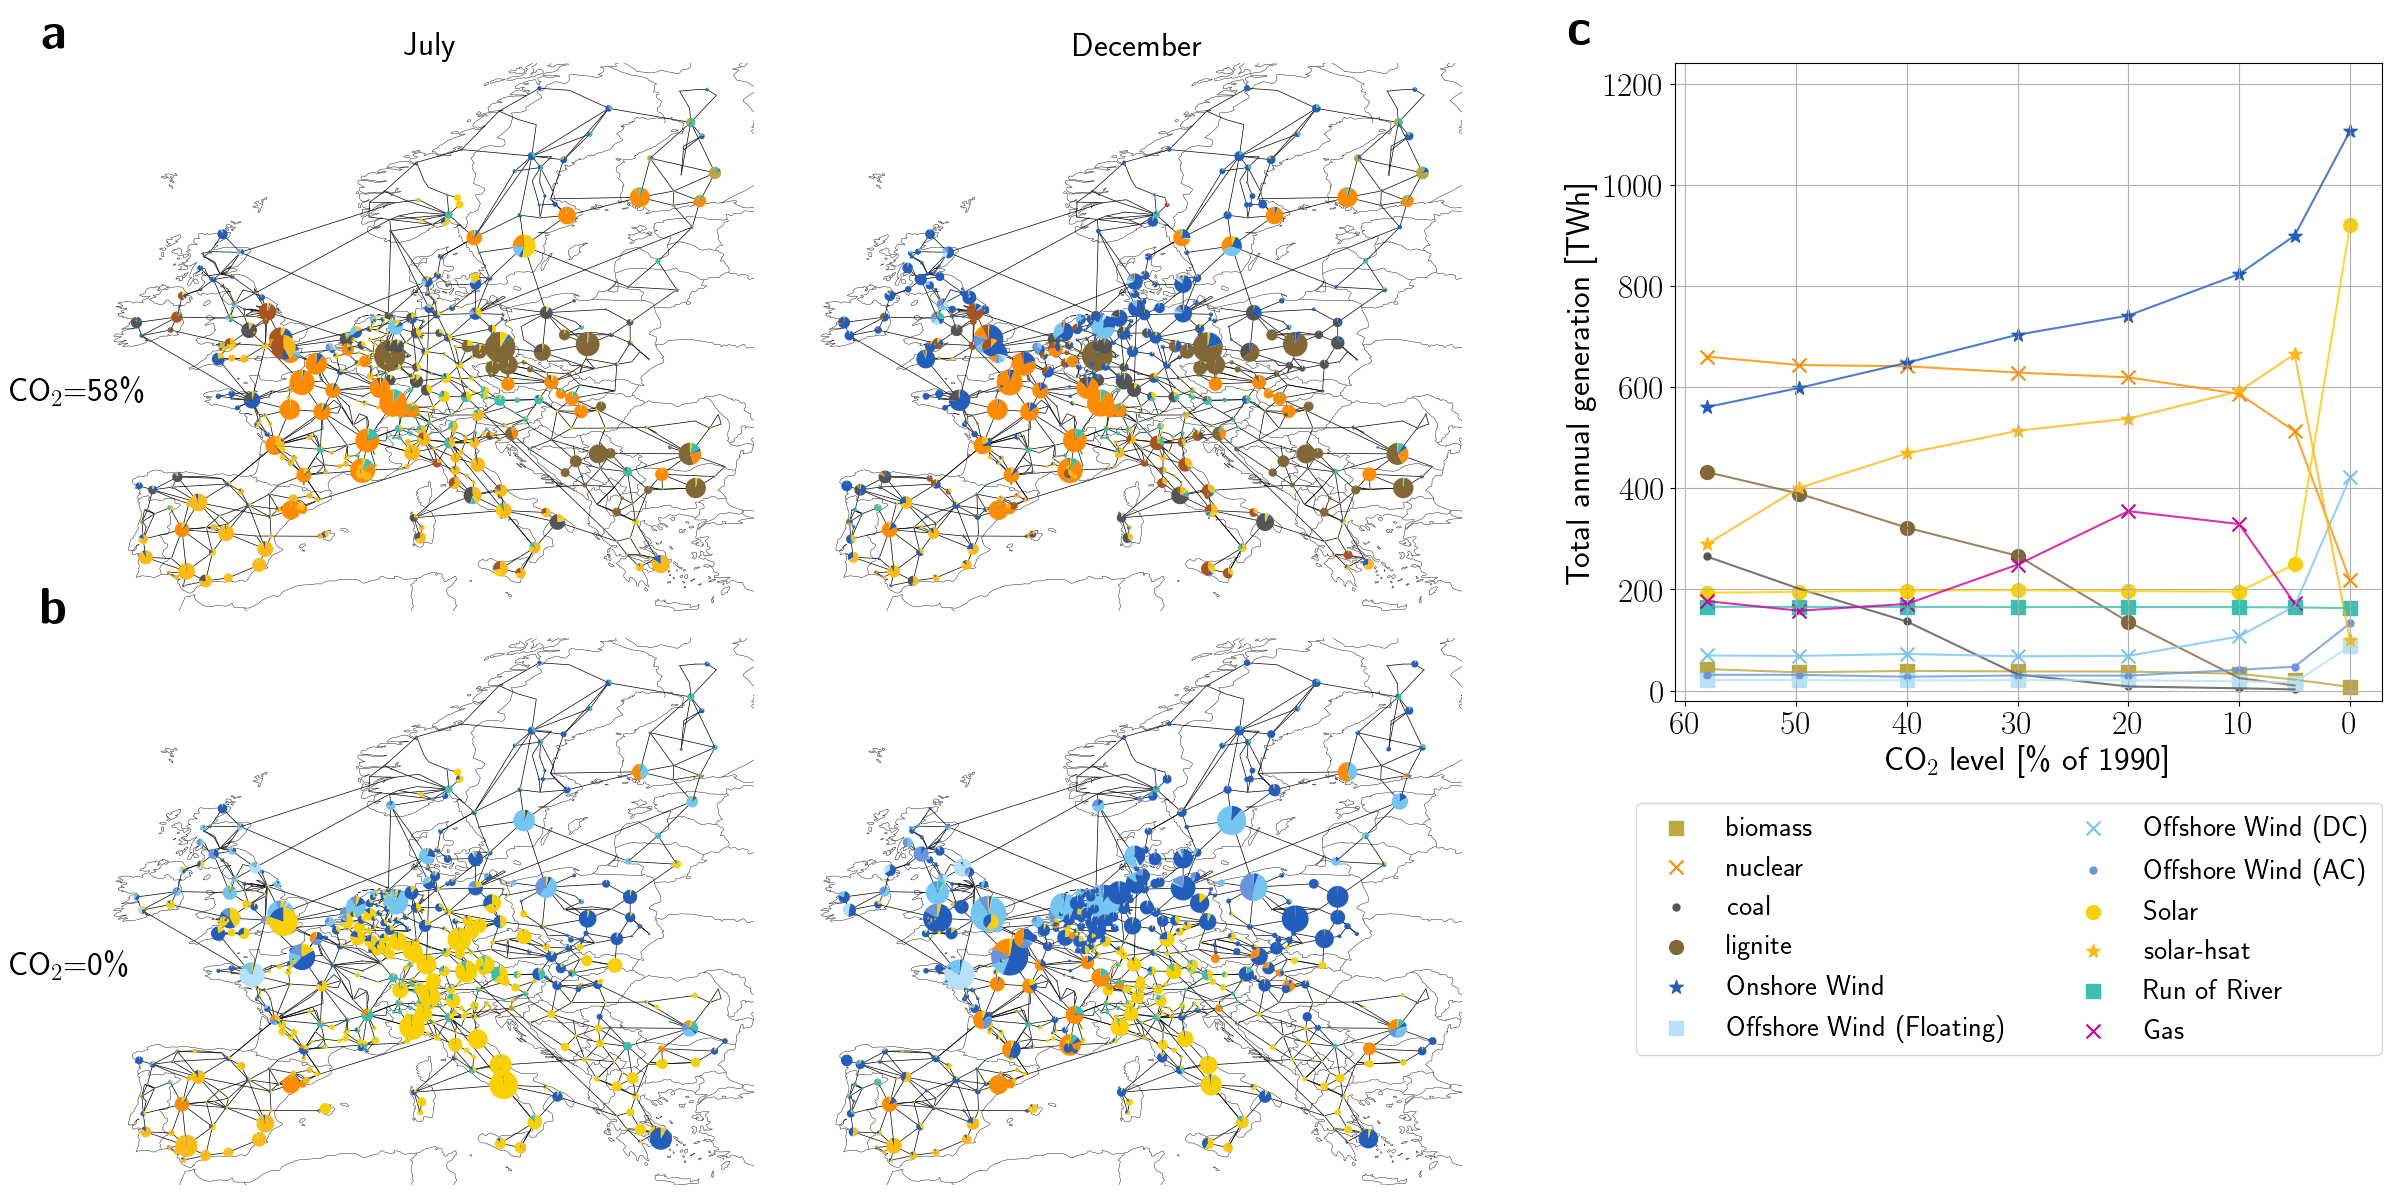

In [ ]:
# drop the 0.7 and 0.8 columns because they carry no relevant information, see old plots
generation_by_carrier_and_co2l = pd.DataFrame(index=networks[0.6].carriers.index,
                                              columns=co2ls)
objectives = np.zeros(len(co2ls))
for i, level in enumerate(co2ls):
    network = networks[level]
    generation_by_carrier_and_co2l[level] = network.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").mul(network.generators.sign).T.groupby(
        network.generators["carrier"]).sum().sum(axis=1)
    objectives[i] = network.objective
generation_by_carrier_and_co2l.dropna(axis=0, inplace=True)

plot_generator_type_threshold = 0.01
max_carrier_share = (generation_by_carrier_and_co2l/generation_by_carrier_and_co2l.sum(axis=0)).max(axis=1)
carrier_mask = max_carrier_share > plot_generator_type_threshold
carrier_mask["OCGT"] = True # keep gas carriers, add them together later
dropped_carriers = carrier_mask[~carrier_mask].index
print(f"Dropping {len(dropped_carriers)} carriers: {dropped_carriers}")
generation_by_carrier_and_co2l = generation_by_carrier_and_co2l[carrier_mask]


mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

target_levels = [0.6, 0.0]

f = plt.figure(figsize=(24, 12))
# gs = GridSpec(2, 3, figure=f)
# ax1 = [f.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# ax2 = [f.add_subplot(gs[1, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# axs_clust = [ax1, ax2]
# ax3 = f.add_subplot(gs[0, 2])
outer = GridSpec(1, 2, width_ratios = [2, 1]) 
# gs = GridSpec(2, 3, figure=f)
gs_left = GridSpecFromSubplotSpec(2, 2, subplot_spec = outer[0], wspace=-0.0, hspace=0.05)
gs_right = GridSpecFromSubplotSpec(2, 1, subplot_spec = outer[1], height_ratios=[1, 0.6])

ax1 = [f.add_subplot(gs_left[0, i], projection=ccrs.PlateCarree())
       for i in range(2)]
ax2 = [f.add_subplot(gs_left[1, i], projection=ccrs.PlateCarree())
       for i in range(2)]
axs_primary = [ax1, ax2]
ax3 = f.add_subplot(gs_right[0, 0])
ax3_legend = f.add_subplot(gs_right[1, 0])
# ax4 = f.add_subplot(outer[1, 1])
labels = [[r'\textbf{a}', r'', r'\textbf{c}'],
          [r'\textbf{b}', '', r'\textbf{d}', '', '']]

##### panal a and b #######

vmax = 3.2e2
months = [7, 12]

for i, target_level in enumerate(target_levels):
       # fpath = data_path + "European_networks_lopf/elec_s_800_ec_lv1.0_Co2L0.1-3H.nc"
       # n = data_handling.load_pypsa_network(fpath, False)
       
       # n = data_handling.load_pypsa_network(path_to_pypsa_network_sclopf +
       #                  f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc", True)
       n = data_handling.load_pypsa_network(target_level, n_nodes, True)
       for ii, month in enumerate(months):

              axs_primary[i][ii].set_ylim([0, vmax])
              current_snapshots = n.snapshots[n.snapshots.month == month]
              current_gen = n.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").loc[current_snapshots].sum().mul(network.generators.sign)
              current_gen = current_gen.groupby([n.generators["bus"], n.generators["carrier"]]).sum()
              n.plot(bus_sizes=current_gen/7e6,
                     line_colors='black',
                     link_colors='black',
                     link_widths=0.5,
                     line_widths=0.5,
                     ax=axs_primary[i][ii])

              if i == 0:
                     axs_primary[i][ii].set_title(current_snapshots.month_name()[0], fontsize=24)

              axs_primary[i][ii].text(0 - 0.1, 1+0.05,
                            labels[i][ii],
                            fontsize=36,
                            weight='bold',
                            verticalalignment='center',
                            transform=axs_primary[i][ii].transAxes)


       axs_primary[i][0].text(0 - 0.15, 0.4,
                     rf'CO$_2$={get_actual_co2_level(target_level, percent=True)}\% ',
                     fontsize=24,
                     verticalalignment='center',
                     transform=axs_primary[i][0].transAxes)

import itertools
marker = itertools.cycle((',', 'x', '.', 'o', '*')) 

colors_gens = network.carriers.set_index('nice_name').color
colors_gens["Open-Cycle Gas"] = "#cc0099"
colors_gens["Gas"] = "#cc0099"

co2s = generation_by_carrier_and_co2l.columns.astype('float')
index = np.argsort(co2s)
jitter = iter(np.linspace(-1,1,generation_by_carrier_and_co2l.shape[0]))

generation_by_carrier_and_co2l = generation_by_carrier_and_co2l.rename(index=network.carriers.nice_name)
gas_gen = generation_by_carrier_and_co2l.loc["Combined-Cycle Gas"] + generation_by_carrier_and_co2l.loc["Open-Cycle Gas"]
generation_by_carrier_and_co2l_plot = generation_by_carrier_and_co2l.copy()
# generation_by_carrier_and_co2l_plot.index = generation_by_carrier_and_co2l_plot.index.str.apply(lambda x: x.upper())


for col in generation_by_carrier_and_co2l_plot.index:
    if "Gas" in col:
        generation_by_carrier_and_co2l_plot.drop(col, axis=0, inplace=True)
generation_by_carrier_and_co2l_plot = generation_by_carrier_and_co2l_plot.rename(index=network.carriers.nice_name)
# generation_by_carrier_and_co2l_plot.drop("Oil", axis=0, inplace=True)
generation_by_carrier_and_co2l_plot.loc["Gas"] = gas_gen 
for ind,data in generation_by_carrier_and_co2l_plot.iterrows():
    # jit = next(jitter)
    jit = 0
    plot_inds = (data.values)[index]>0
    # print(plot_inds.sum())
    ax3.scatter((get_actual_co2_level(co2s[index])*100 + jit)[plot_inds],
                ((data.values)[index]*1e-6)[plot_inds],
                color=colors_gens.loc[ind],
                label=ind,
                s=100,
                marker= next(marker)
                )

    ax3.plot((get_actual_co2_level(co2s[index])*100 + jit)[plot_inds],
             ((data.values)[index]*1e-6)[plot_inds],
             color=colors_gens.loc[ind],
             alpha=0.8)
# plt.gca().set_yscale("log")
# ax3.scatter([], [], label=r"Oil$\textless 0.6$", marker="")


ax3.invert_xaxis()
ax3.tick_params(axis='both', which='both', labelsize=24)
ax3.set_xlabel(r'$\text{CO}_2$ level [\% of 1990]',  fontsize=24)
ax3.set_ylabel(r'Total annual generation [TWh]', fontsize=24)

ax3.grid(True)
ax3.yaxis.offsetText.set_fontsize(24)
ax3.text(0 - 0.15, 1+0.05,
         labels[0][2],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax3.transAxes)
# ax3.plot([746/1251*100, 746/1251*100],[-2e1,1000], '--', lw=4, c='r', zorder=-1000) # TODO: Insert CO2 limit that corresponds to todays amount
# co2 emissions from https://www.umweltbundesamt.de/daten/klima/treibhausgas-emissionen-in-deutschland#emissionsentwicklung
# ax3.text(50,12e2*0.9, r'\textbf{2022`s emissions}', fontsize=24, color='r')
# ax3.text(746/1251*100,1050, r'\textbf{2022`s emissions}', fontsize=24, color='r', horizontalalignment='left')
ax3.set_ylim([-2e1,12.4e2])
# ax3.set_yscale('log')

# f.subplots_adjust(hspace=0.05, wspace=0.2)
h, l = ax3.get_legend_handles_labels()
ax3_legend.legend(h, l, borderaxespad=0, fontsize=20.5, ncol=2)
ax3_legend.axis("off")
# ax3.legend(fontsize=20.5, bbox_to_anchor=(1.02,0), ncol=2, loc="upper left")
# plt.tight_layout()
# ax3.legend(fontsize=20.5, ncol=2, columnspacing=0.5, handletextpad=0.1, borderpad=0.3)
plt.tight_layout()

plt.savefig(save_path+'generation_mix_versus_co2level.pdf', bbox_inches='tight')

# Storage map plots

/home/mtitz/.conda/envs/system_split/lib/python3.11/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.5-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.4-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.3-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.2-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.1-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.05-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


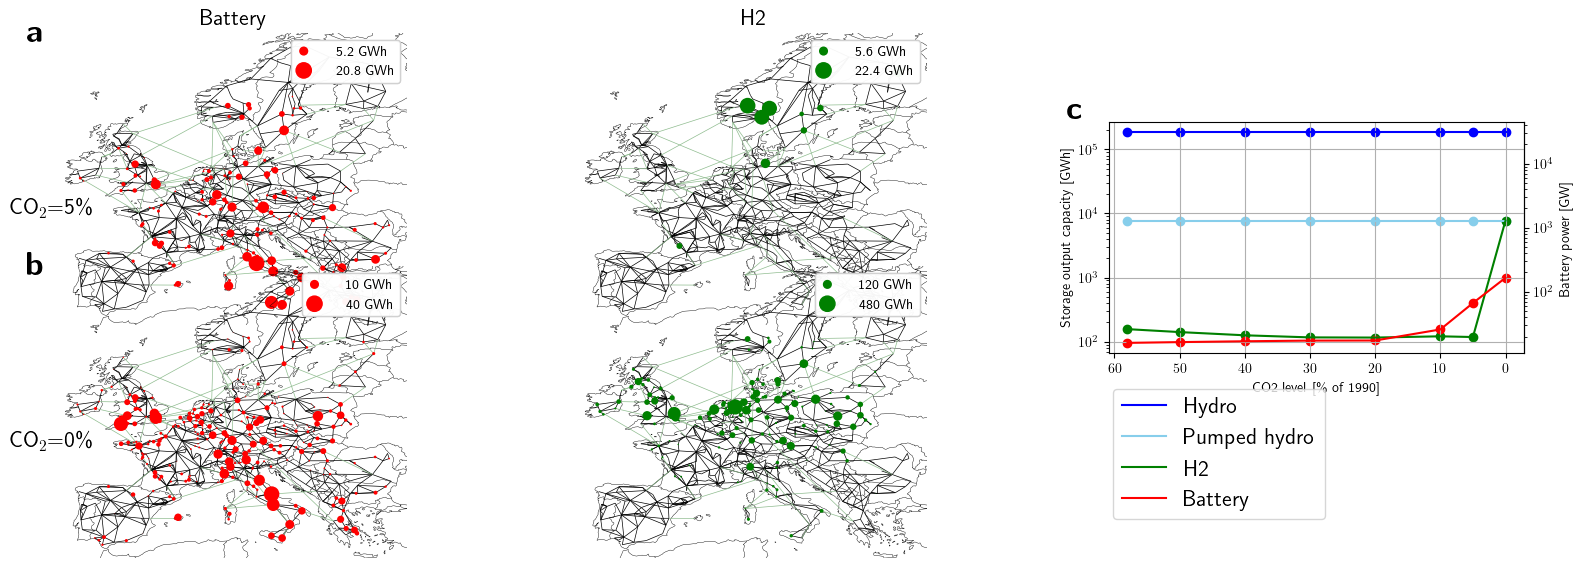

In [13]:
# select whether to plot the storage OUTPUT capacity (capacity * output efficiency) or the storage capacity
for plot_output_capacity in [True]:

       mpl.style.use('default')
       plt.rc('text', usetex=True)
       plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

       target_levels = [0.05, 0.0]
       unit = "GWh"
       unit_factor = 1e-3

       f = plt.figure(figsize=(20,15))

       gs_vertical = GridSpec(2, 2, width_ratios=[2,0.8], wspace=0.13)
       gs_maps = GridSpecFromSubplotSpec(2, 2, subplot_spec = gs_vertical[0], wspace=-0.0, hspace=-0.2)
       gs_lines = GridSpecFromSubplotSpec(3, 1, subplot_spec = gs_vertical[1], height_ratios=[0.1,0.4,0.3])

       axs_maps = np.array([[f.add_subplot(gs_maps[j, i], projection=ccrs.PlateCarree())
              for i in range(2)] for j in range(2)])
       ax_line = f.add_subplot(gs_lines[1])

       ##### panal a, b: maps #######

       buses = list(network.buses.index)
       storage_types = network.storage_units["carrier"].unique()
       multi_index = pd.MultiIndex.from_product([buses, storage_types], names=["bus", "carrier"])

       battery_color = "red"
       h2_color = "green"
       for i, target_level in enumerate(target_levels):
              for ii, (current_store_type, current_color) in enumerate(zip(["battery", "H2"], [battery_color, h2_color])):
                     n = networks[target_level]
                     storage_capacities = n.storage_units.max_hours * n.storage_units.p_nom
                     if plot_output_capacity:
                            storage_capacities = n.storage_units.max_hours * n.storage_units.p_nom * n.storage_units.efficiency_dispatch
                     storage_capacities_grouped = storage_capacities.groupby([n.storage_units["bus"], n.storage_units["carrier"]]).sum()
                     max_node_size = 0.85
                     max_capacity = storage_capacities_grouped[:,current_store_type].max()
                     max_capacity_rounded = round(max_capacity, -int(round(np.log10(max_capacity),0))+1)
                     n.plot(bus_sizes=storage_capacities_grouped[:,current_store_type]/max_capacity_rounded*max_node_size,
                            line_colors='black',
                            bus_colors=current_color,
                            link_widths=0.5,
                            line_widths=0.5,
                            ax=axs_maps[i,ii])
                     legend_relative_circle_size = np.array([0.25, 1])
                     legend_circle_size = [size*max_node_size for size in legend_relative_circle_size]
                     legend_circle_size = [round(size, -int(np.floor(np.log10(size)))) for size in legend_circle_size]
                     axs_maps[i,ii].legend(loc="upper left")
                     pypsa.plot.add_legend_circles(axs_maps[i,ii], sizes=legend_circle_size, labels=[f"{size*max_capacity_rounded*unit_factor:2g} {unit}" for size in legend_circle_size], patch_kw={"color":current_color})
                     

                     # set current_store_type to upper case
                     current_store_type_string = current_store_type[0].upper() + current_store_type[1:]
                     axs_maps[0,ii].set_title(current_store_type_string, fontsize=16)
                     
       axs_maps[0,0].text(0 - 0.1, 1,
                     r'\textbf{a}',
                     fontsize=24,
                     weight='bold',
                     verticalalignment='center',
                     transform=axs_maps[0,0].transAxes)
       axs_maps[1,0].text(0 - 0.1, 1,
                     r'\textbf{b}',
                     fontsize=24,
                     weight='bold',
                     verticalalignment='center',
                     transform=axs_maps[1,0].transAxes)


       axs_maps[0,0].text(0 - 0.15, 0.4,
                     fr'CO$_2$={get_actual_co2_level(target_levels[0], percent=True)}\% ',
                     fontsize=16,
                     verticalalignment='center',
                     transform=axs_maps[0,0].transAxes)
       axs_maps[1,0].text(0 - 0.15, 0.4,
                     fr'CO$_2$={get_actual_co2_level(target_levels[1], percent=True)}\%',
                     fontsize=16,
                     verticalalignment='center',
                     transform=axs_maps[1,0].transAxes)


       ###### panel c: total capacity line plot #####

       ax_line.text(0 - 0.1, 1+0.05,
                     r'\textbf{c}',
                     fontsize=24,
                     weight='bold',
                     verticalalignment='center',
                     transform=ax_line.transAxes)

       capacity_by_type_by_lvl = pd.DataFrame(index=storage_types, columns=co2ls[::-1])
       for target_level in co2ls:
              n = networks[target_level]
              print(f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc")
              storage_capacities_all_lvl = pd.Series(index=multi_index, data=0)
              storage_capacities_lvl = n.storage_units.max_hours * n.storage_units.p_nom
              if plot_output_capacity:
                     storage_capacities_lvl = storage_capacities_lvl * n.storage_units.efficiency_dispatch
              storage_capacities_grouped_lvl = storage_capacities_lvl.groupby([n.storage_units["carrier"]]).sum()
              capacity_by_type_by_lvl.loc[storage_capacities_grouped_lvl.index,target_level] = storage_capacities_grouped_lvl

              capacity_by_type_by_lvl_plotting = capacity_by_type_by_lvl.T.copy()
       try:
              capacity_by_type_by_lvl_plotting.drop(index=[0.7,0.8], inplace=True)
       except:
              pass

       capacity_by_type_by_lvl_plotting.rename(columns={"battery": "Battery", "hydro": "Hydro", "PHS": "Pumped hydro"},inplace=True)
       colors = ["blue", "skyblue", h2_color, battery_color]
       ax_line.plot(get_actual_co2_level(capacity_by_type_by_lvl.columns,percent=True) ,capacity_by_type_by_lvl_plotting.loc[:,['Hydro', 'Pumped hydro', 'H2','Battery']].values*unit_factor, label=['Hydro', 'Pumped hydro', 'H2','Battery'])
       for feat_count in range(capacity_by_type_by_lvl_plotting.shape[1]):
              plt.scatter(get_actual_co2_level(capacity_by_type_by_lvl.columns,percent=True) ,(capacity_by_type_by_lvl_plotting.loc[:,['Hydro', 'Pumped hydro', 'H2','Battery']].values*unit_factor)[:,feat_count], color=colors[feat_count])
       secax = ax_line.secondary_yaxis('right', functions=(lambda x: x*(1/6), lambda x: x*6))
       secax.set_ylabel('Battery power [GW]')#, weight='normal')
       # secax.tick_params(labelsize=16)
       # secax.tick_params(axis='y', which='both', labelsize=10, width=1)

       for i,ii in enumerate(ax_line.lines):
              ii.set_color(colors[i])

       ax_line.invert_xaxis()
       ax_line.grid(True)
       plt.yscale('log')
       if plot_output_capacity:
              plt.ylabel(f"Storage output capacity [{unit}]")
       else:
              plt.ylabel(f"Storage capacity [{unit}]")
       plt.xlabel(r"CO2 level [\% of 1990]")
       plt.legend()
       h, l = ax_line.get_legend_handles_labels()
       ax_line.get_legend().remove()
       ax_line_legend = f.add_subplot(gs_lines[2])
       ax_line_legend.legend(h, l, borderaxespad=0.2, fontsize=16, ncol=1, loc="upper left")
       ax_line_legend.axis("off")

       if plot_output_capacity:
              file_name = "storage_output_capacity_vs_co2level"
       else:
              file_name = "storage_capacityvs_co2level"

       plt.savefig(save_path+file_name + '.pdf', bbox_inches='tight')

In [11]:
[(size*max_node_size) for size in legend_relative_circle_size]

[0.2125, 0.85]

In [ ]:
n = networks[0.1]
state_of_charge_by_carrier = n.storage_units_t["state_of_charge"].groupby(n.storage_units.carrier, axis=1).sum()
state_of_charge_by_carrier.drop(columns=["battery"]).plot()
plt.yscale('log')

In [ ]:
state_of_charge_by_carrier.groupby(state_of_charge_by_carrier.index.hour).mean().plot()
plt.yscale('log')

In [ ]:
state_of_charge_by_carrier.groupby(state_of_charge_by_carrier.index.dayofyear).mean().plot()
plt.yscale('log')

/home/mtitz/.conda/envs/system_split/lib/python3.11/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.5-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.4-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.3-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.2-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.1-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.05-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


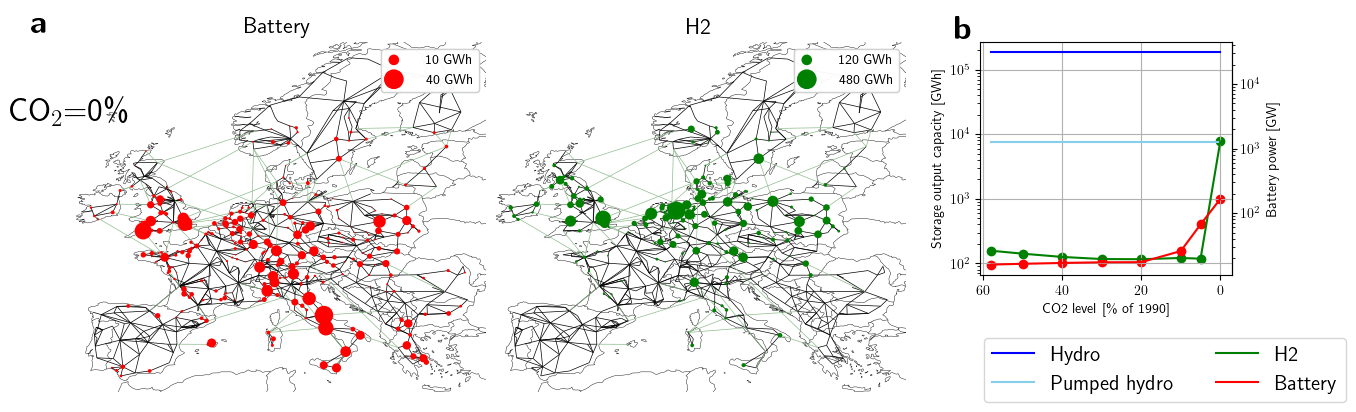

In [41]:
# select whether to plot the storage OUTPUT capacity (capacity * output efficiency) or the storage capacity
for plot_output_capacity in [True]:

       mpl.style.use('default')
       plt.rc('text', usetex=True)
       plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

       target_levels = [0.0]
       unit = "GWh"
       unit_factor = 1e-3

       f = plt.figure(figsize=(15,10))

       gs_vertical = GridSpec(2, 2, width_ratios=[2,0.6], wspace=0.13)
       gs_maps = GridSpecFromSubplotSpec(1, 2, subplot_spec = gs_vertical[0], wspace=-0.0, hspace=-0.2)
       gs_lines = GridSpecFromSubplotSpec(2, 1, subplot_spec = gs_vertical[1], height_ratios=[0.8,0.2], hspace=0.4)

       axs_maps = np.array([f.add_subplot(gs_maps[i], projection=ccrs.PlateCarree())
              for i in range(2)])
       ax_line = f.add_subplot(gs_lines[0])

       ##### panal a, b: maps #######

       buses = list(network.buses.index)
       storage_types = network.storage_units["carrier"].unique()
       multi_index = pd.MultiIndex.from_product([buses, storage_types], names=["bus", "carrier"])

       battery_color = "red"
       h2_color = "green"
       for i, target_level in enumerate(target_levels):
              for ii, (current_store_type, current_color) in enumerate(zip(["battery", "H2"], [battery_color, h2_color])):
                     n = networks[target_level]
                     storage_capacities = n.storage_units.max_hours * n.storage_units.p_nom
                     if plot_output_capacity:
                            storage_capacities = n.storage_units.max_hours * n.storage_units.p_nom * n.storage_units.efficiency_dispatch
                     storage_capacities_grouped = storage_capacities.groupby([n.storage_units["bus"], n.storage_units["carrier"]]).sum()
                     max_node_size = 0.85
                     max_capacity = storage_capacities_grouped[:,current_store_type].max()
                     max_capacity_rounded = round(max_capacity, -int(round(np.log10(max_capacity),0))+1)
                     n.plot(bus_sizes=storage_capacities_grouped[:,current_store_type]/max_capacity_rounded*max_node_size,
                            line_colors='black',
                            bus_colors=current_color,
                            link_widths=0.5,
                            line_widths=0.5,
                            ax=axs_maps[ii])
                     legend_relative_circle_size = np.array([0.25, 1])
                     legend_circle_size = [size*max_node_size for size in legend_relative_circle_size]
                     axs_maps[ii].legend(loc="upper left")
                     legend_circle_size = [round(size, -int(np.floor(np.log10(size)))) for size in legend_circle_size]
                     pypsa.plot.add_legend_circles(axs_maps[ii], sizes=legend_circle_size, labels=[f"{size*max_capacity_rounded*unit_factor:2g} {unit}" for size in legend_circle_size], patch_kw={"color":current_color})
                     

                     # set current_store_type to upper case
                     current_store_type_string = current_store_type[0].upper() + current_store_type[1:]
                     axs_maps[ii].set_title(current_store_type_string, fontsize=16)
                     
       axs_maps[0].text(0 - 0.1, 1+0.05,
                     r'\textbf{a}',
                     fontsize=24,
                     weight='bold',
                     verticalalignment='center',
                     transform=axs_maps[0].transAxes)
       # axs_maps[0].text(0 - 0.1, 1,
       #               r'\textbf{b}',
       #               fontsize=24,
       #               weight='bold',
       #               verticalalignment='center',
       #               transform=axs_maps[0].transAxes)


       axs_maps[0].text(0 - 0.15, 0.8,
                     fr'CO$_2$={get_actual_co2_level(target_levels[0], percent=True)}\% ',
                     fontsize=24,
                     fontweight='bold',
                     verticalalignment='center',
                     transform=axs_maps[0].transAxes)
       # axs_maps[0].text(0 - 0.15, 0.4,
       #               fr'CO$_2$={get_actual_co2_level(target_levels[1], percent=True)}\%',
       #               fontsize=16,
       #               verticalalignment='center',
       #               transform=axs_maps[0].transAxes)


       ###### panel c: total capacity line plot #####

       ax_line.text(0 - 0.1, 1+0.05,
                     r'\textbf{b}',
                     fontsize=24,
                     weight='bold',
                     verticalalignment='center',
                     transform=ax_line.transAxes)

       capacity_by_type_by_lvl = pd.DataFrame(index=storage_types, columns=co2ls[::-1])
       for target_level in co2ls:
              n = networks[target_level]
              print(f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc")
              storage_capacities_all_lvl = pd.Series(index=multi_index, data=0)
              storage_capacities_lvl = n.storage_units.max_hours * n.storage_units.p_nom
              if plot_output_capacity:
                     storage_capacities_lvl = storage_capacities_lvl * n.storage_units.efficiency_dispatch
              storage_capacities_grouped_lvl = storage_capacities_lvl.groupby([n.storage_units["carrier"]]).sum()
              capacity_by_type_by_lvl.loc[storage_capacities_grouped_lvl.index,target_level] = storage_capacities_grouped_lvl

              capacity_by_type_by_lvl_plotting = capacity_by_type_by_lvl.T.copy()
       try:
              capacity_by_type_by_lvl_plotting.drop(index=[0.7,0.8], inplace=True)
       except:
              pass

       capacity_by_type_by_lvl_plotting.rename(columns={"battery": "Battery", "hydro": "Hydro", "PHS": "Pumped hydro"},inplace=True)
       colors = ["blue", "skyblue", h2_color, battery_color]
       ax_line.plot(get_actual_co2_level(capacity_by_type_by_lvl.columns,percent=True) ,capacity_by_type_by_lvl_plotting.loc[:,['Hydro', 'Pumped hydro', 'H2','Battery']].values*unit_factor, label=['Hydro', 'Pumped hydro', 'H2','Battery'])
       for feat_count in range(capacity_by_type_by_lvl_plotting.shape[1]):
              if "ydro" in capacity_by_type_by_lvl_plotting.columns[feat_count]:
                     continue
              plt.scatter(get_actual_co2_level(capacity_by_type_by_lvl.columns,percent=True) ,(capacity_by_type_by_lvl_plotting.loc[:,['Hydro', 'Pumped hydro', 'H2','Battery']].values*unit_factor)[:,feat_count], color=colors[feat_count])
       secax = ax_line.secondary_yaxis('right', functions=(lambda x: x*(1/6), lambda x: x*6))
       secax.set_ylabel('Battery power [GW]')#, weight='normal')
       # secax.tick_params(labelsize=16)
       # secax.tick_params(axis='y', which='both', labelsize=10, width=1)

       for i,ii in enumerate(ax_line.lines):
              ii.set_color(colors[i])

       ax_line.invert_xaxis()
       ax_line.grid(True)
       plt.yscale('log')
       if plot_output_capacity:
              plt.ylabel(f"Storage output capacity [{unit}]")
       else:
              plt.ylabel(f"Storage capacity [{unit}]")
       plt.xlabel(r"CO2 level [\% of 1990]")
       plt.legend()
       h, l = ax_line.get_legend_handles_labels()
       ax_line.get_legend().remove()
       ax_line_legend = f.add_subplot(gs_lines[1])
       ax_line_legend.legend(h, l, borderaxespad=0.2, fontsize=15, ncol=2, loc="upper left")
       ax_line_legend.axis("off")

       if plot_output_capacity:
              file_name = "storage_output_capacity_vs_co2level"
       else:
              file_name = "storage_capacity_vs_co2level"

       plt.savefig(save_path+file_name + 'singleLvl.pdf', bbox_inches='tight')

/home/mtitz/.conda/envs/system_split/lib/python3.11/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.5-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.4-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.3-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.2-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.1-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.05-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


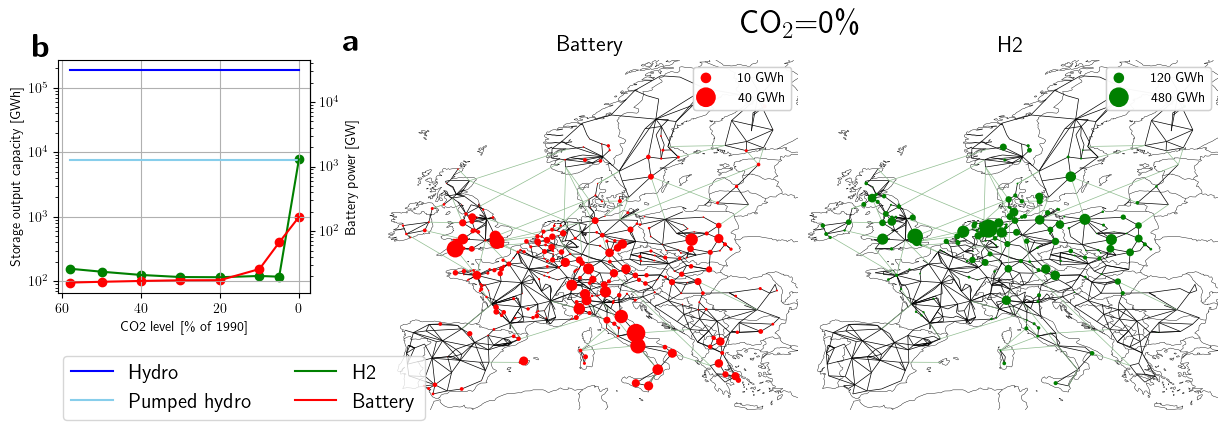

In [56]:
# select whether to plot the storage OUTPUT capacity (capacity * output efficiency) or the storage capacity
for plot_output_capacity in [True]:

       mpl.style.use('default')
       plt.rc('text', usetex=True)
       plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

       target_levels = [0.0]
       unit = "GWh"
       unit_factor = 1e-3

       f = plt.figure(figsize=(15,10))

       gs_vertical = GridSpec(2, 2, width_ratios=[0.6,2], wspace=0.13)
       gs_lines = GridSpecFromSubplotSpec(2, 1, subplot_spec = gs_vertical[0], height_ratios=[0.8,0.2], hspace=0.4)
       gs_maps = GridSpecFromSubplotSpec(1, 2, subplot_spec = gs_vertical[1], wspace=-0.0, hspace=-0.2)

       axs_maps = np.array([f.add_subplot(gs_maps[i], projection=ccrs.PlateCarree())
              for i in range(2)])
       ax_line = f.add_subplot(gs_lines[0])

       ##### panal a, b: maps #######

       buses = list(network.buses.index)
       storage_types = network.storage_units["carrier"].unique()
       multi_index = pd.MultiIndex.from_product([buses, storage_types], names=["bus", "carrier"])

       battery_color = "red"
       h2_color = "green"
       for i, target_level in enumerate(target_levels):
              for ii, (current_store_type, current_color) in enumerate(zip(["battery", "H2"], [battery_color, h2_color])):
                     n = networks[target_level]
                     storage_capacities = n.storage_units.max_hours * n.storage_units.p_nom
                     if plot_output_capacity:
                            storage_capacities = n.storage_units.max_hours * n.storage_units.p_nom * n.storage_units.efficiency_dispatch
                     storage_capacities_grouped = storage_capacities.groupby([n.storage_units["bus"], n.storage_units["carrier"]]).sum()
                     max_node_size = 0.85
                     max_capacity = storage_capacities_grouped[:,current_store_type].max()
                     max_capacity_rounded = round(max_capacity, -int(round(np.log10(max_capacity),0))+1)
                     n.plot(bus_sizes=storage_capacities_grouped[:,current_store_type]/max_capacity_rounded*max_node_size,
                            line_colors='black',
                            bus_colors=current_color,
                            link_widths=0.5,
                            line_widths=0.5,
                            ax=axs_maps[ii])
                     legend_relative_circle_size = np.array([0.25, 1])
                     legend_circle_size = [size*max_node_size for size in legend_relative_circle_size]
                     axs_maps[ii].legend(loc="upper left")
                     legend_circle_size = [round(size, -int(np.floor(np.log10(size)))) for size in legend_circle_size]
                     pypsa.plot.add_legend_circles(axs_maps[ii], sizes=legend_circle_size, labels=[f"{size*max_capacity_rounded*unit_factor:2g} {unit}" for size in legend_circle_size], patch_kw={"color":current_color})
                     

                     # set current_store_type to upper case
                     current_store_type_string = current_store_type[0].upper() + current_store_type[1:]
                     axs_maps[ii].set_title(current_store_type_string, fontsize=16)
                     
       axs_maps[0].text(0 - 0.1, 1+0.05,
                     r'\textbf{a}',
                     fontsize=24,
                     weight='bold',
                     verticalalignment='center',
                     transform=axs_maps[0].transAxes)
       # axs_maps[0].text(0 - 0.1, 1,
       #               r'\textbf{b}',
       #               fontsize=24,
       #               weight='bold',
       #               verticalalignment='center',
       #               transform=axs_maps[0].transAxes)


    #    axs_maps[0].text(0 - 0.15, 0.8,
    #                  fr'CO$_2$={get_actual_co2_level(target_levels[0], percent=True)}\% ',
    #                  fontsize=24,
    #                  fontweight='bold',
    #                  verticalalignment='center',
    #                  transform=axs_maps[0].transAxes)
    # Add a suptitle axis without projection for annotation purposes
    #    ax_suptitle = f.add_subplot(gs_vertical[:, 1])
    # #    ax_suptitle = f.add_subplot(gs_maps[0, 1])
    #    ax_suptitle.set_title(fr'CO$_2$={get_actual_co2_level(target_levels[0], percent=True)}\% ', fontsize=24, weight='bold', verticalalignment='center', transform=ax_suptitle.transAxes)
    #    ax_suptitle.axis("off")
       # axs_maps[0].text(0 - 0.15, 0.4,
       #               fr'CO$_2$={get_actual_co2_level(target_levels[1], percent=True)}\%',
       #               fontsize=16,
       #               verticalalignment='center',
       #               transform=axs_maps[0].transAxes)


       ###### panel c: total capacity line plot #####

       ax_line.text(0 - 0.1, 1+0.05,
                     r'\textbf{b}',
                     fontsize=24,
                     weight='bold',
                     verticalalignment='center',
                     transform=ax_line.transAxes)

       capacity_by_type_by_lvl = pd.DataFrame(index=storage_types, columns=co2ls[::-1])
       for target_level in co2ls:
              n = networks[target_level]
              print(f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc")
              storage_capacities_all_lvl = pd.Series(index=multi_index, data=0)
              storage_capacities_lvl = n.storage_units.max_hours * n.storage_units.p_nom
              if plot_output_capacity:
                     storage_capacities_lvl = storage_capacities_lvl * n.storage_units.efficiency_dispatch
              storage_capacities_grouped_lvl = storage_capacities_lvl.groupby([n.storage_units["carrier"]]).sum()
              capacity_by_type_by_lvl.loc[storage_capacities_grouped_lvl.index,target_level] = storage_capacities_grouped_lvl

              capacity_by_type_by_lvl_plotting = capacity_by_type_by_lvl.T.copy()
       try:
              capacity_by_type_by_lvl_plotting.drop(index=[0.7,0.8], inplace=True)
       except:
              pass

       capacity_by_type_by_lvl_plotting.rename(columns={"battery": "Battery", "hydro": "Hydro", "PHS": "Pumped hydro"},inplace=True)
       colors = ["blue", "skyblue", h2_color, battery_color]
       ax_line.plot(get_actual_co2_level(capacity_by_type_by_lvl.columns,percent=True) ,capacity_by_type_by_lvl_plotting.loc[:,['Hydro', 'Pumped hydro', 'H2','Battery']].values*unit_factor, label=['Hydro', 'Pumped hydro', 'H2','Battery'])
       for feat_count in range(capacity_by_type_by_lvl_plotting.shape[1]):
              if "ydro" in capacity_by_type_by_lvl_plotting.columns[feat_count]:
                     continue
              plt.scatter(get_actual_co2_level(capacity_by_type_by_lvl.columns,percent=True) ,(capacity_by_type_by_lvl_plotting.loc[:,['Hydro', 'Pumped hydro', 'H2','Battery']].values*unit_factor)[:,feat_count], color=colors[feat_count])
       secax = ax_line.secondary_yaxis('right', functions=(lambda x: x*(1/6), lambda x: x*6))
       secax.set_ylabel('Battery power [GW]')#, weight='normal')
       # secax.tick_params(labelsize=16)
       # secax.tick_params(axis='y', which='both', labelsize=10, width=1)

       for i,ii in enumerate(ax_line.lines):
              ii.set_color(colors[i])

       ax_line.invert_xaxis()
       ax_line.grid(True)
       plt.yscale('log')
       if plot_output_capacity:
              plt.ylabel(f"Storage output capacity [{unit}]")
       else:
              plt.ylabel(f"Storage capacity [{unit}]")
       plt.xlabel(r"CO2 level [\% of 1990]")
       plt.legend()
       h, l = ax_line.get_legend_handles_labels()
       ax_line.get_legend().remove()
       ax_line_legend = f.add_subplot(gs_lines[1])
       ax_line_legend.legend(h, l, borderaxespad=0.2, fontsize=15, ncol=2, loc="upper left")
       ax_line_legend.axis("off")

       ax_suptitle = f.add_subplot(gs_vertical[0, 1])
    #    ax_suptitle = f.add_subplot(gs_maps[0, 1])
       ax_suptitle.set_title(fr'CO$_2$={get_actual_co2_level(target_levels[0], percent=True)}\% ', fontsize=24, weight='bold', verticalalignment='center', transform=ax_suptitle.transAxes, y=1.1)
       ax_suptitle.axis("off")
       
       if plot_output_capacity:
              file_name = "storage_output_capacity_vs_co2level"
       else:
              file_name = "storage_capacity_vs_co2level"

       plt.savefig(save_path+file_name + 'singleLvl.pdf', bbox_inches='tight')

# node power balance

In [57]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import AxesGrid

def shiftedColorMap(cmap, start=0, midpoint=0.5, stop=1.0, name='shiftedcmap'):
    '''
    Function to offset the "center" of a colormap. Useful for
    data with a negative min and positive max and you want the
    middle of the colormap's dynamic range to be at zero.

    Input
    -----
      cmap : The matplotlib colormap to be altered
      start : Offset from lowest point in the colormap's range.
          Defaults to 0.0 (no lower offset). Should be between
          0.0 and `midpoint`.
      midpoint : The new center of the colormap. Defaults to 
          0.5 (no shift). Should be between 0.0 and 1.0. In
          general, this should be  1 - vmax / (vmax + abs(vmin))
          For example if your data range from -15.0 to +5.0 and
          you want the center of the colormap at 0.0, `midpoint`
          should be set to  1 - 5/(5 + 15)) or 0.75
      stop : Offset from highest point in the colormap's range.
          Defaults to 1.0 (no upper offset). Should be between
          `midpoint` and 1.0.
    '''
    cdict = {
        'red': [],
        'green': [],
        'blue': [],
        'alpha': []
    }

    # regular index to compute the colors
    reg_index = np.linspace(start, stop, 257)

    # shifted index to match the data
    shift_index = np.hstack([
        np.linspace(0.0, midpoint, 128, endpoint=False), 
        np.linspace(midpoint, 1.0, 129, endpoint=True)
    ])

    for ri, si in zip(reg_index, shift_index):
        r, g, b, a = cmap(ri)

        cdict['red'].append((si, r, r))
        cdict['green'].append((si, g, g))
        cdict['blue'].append((si, b, b))
        cdict['alpha'].append((si, a, a))

    newcmap = matplotlib.colors.LinearSegmentedColormap(name, cdict)
    # plt.register_cmap(cmap=newcmap)

    return newcmap


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.05-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.05-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/tmp/ipykernel_1422954/3001813574.py:132: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap("bwr")


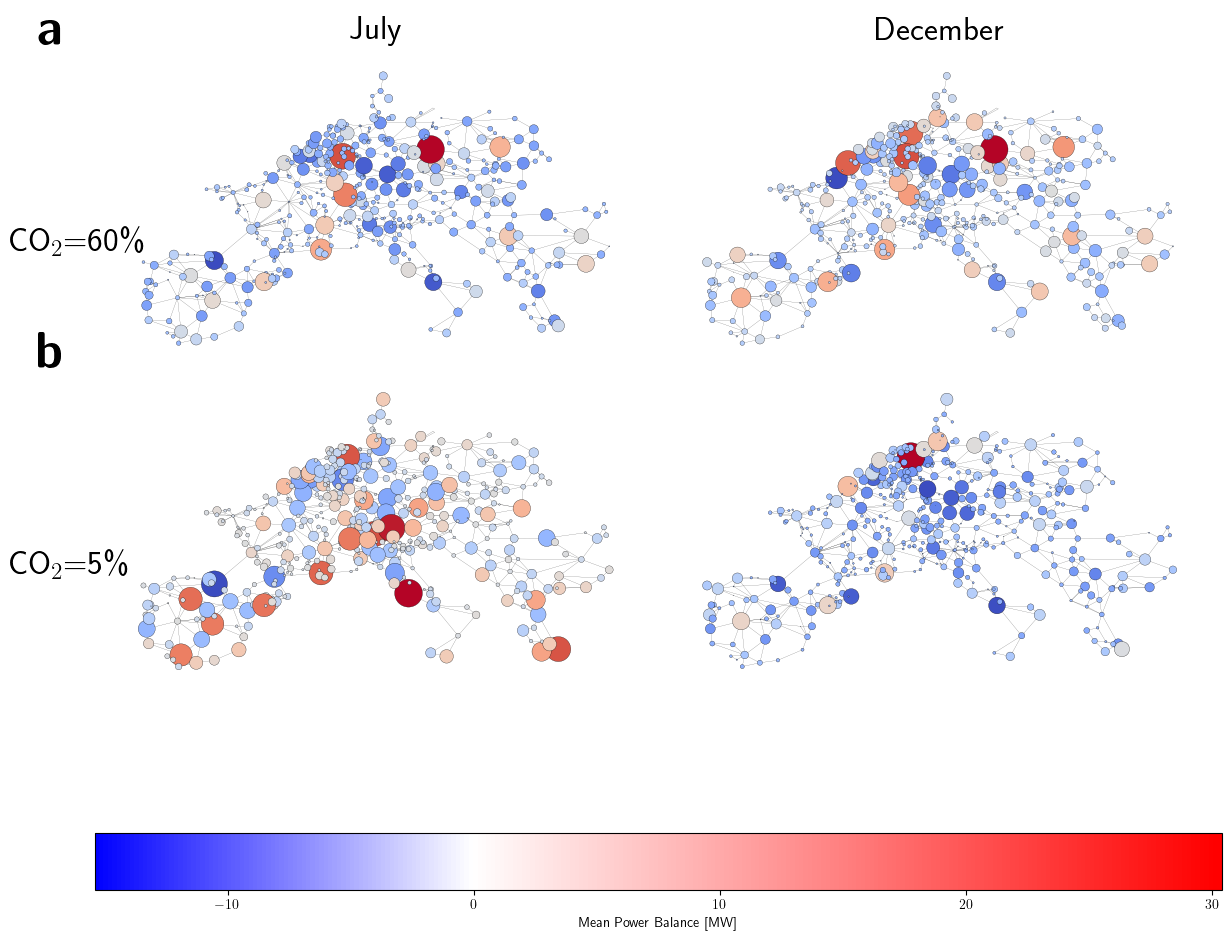

In [58]:
import matplotlib.cm


mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

target_levels = [0.6, 0.05]

f = plt.figure(figsize=(24, 12))
# gs = GridSpec(2, 3, figure=f)
# ax1 = [f.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# ax2 = [f.add_subplot(gs[1, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# axs_clust = [ax1, ax2]
# ax3 = f.add_subplot(gs[0, 2])
outer = GridSpec(1, 2, width_ratios = [2, 1]) 
# gs = GridSpec(2, 3, figure=f)
gs_left = GridSpecFromSubplotSpec(2, 2, subplot_spec = outer[0], wspace=-0.0, hspace=0.0)
gs_right = GridSpecFromSubplotSpec(2, 1, subplot_spec = outer[1], height_ratios=[1, 0.6])

# ax1 = [f.add_subplot(gs_left[0, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# ax2 = [f.add_subplot(gs_left[1, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
ax1 = [f.add_subplot(gs_left[0, i])
       for i in range(2)]
ax2 = [f.add_subplot(gs_left[1, i])
       for i in range(2)]
axs_primary = [ax1, ax2]
# ax3 = f.add_subplot(gs_right[0, 0])
# ax3_legend = f.add_subplot(gs_right[1, 0])
# ax4 = f.add_subplot(outer[1, 1])
labels = [[r'\textbf{a}', r'', r'\textbf{c}'],
          [r'\textbf{b}', '', r'\textbf{d}', '', '']]

##### panal a and b #######

vmax = -np.inf
vmin = np.inf
months = [7, 12]

for i, target_level in enumerate(target_levels):
    n = network = data_handling.load_pypsa_network_from_path(path_to_pypsa_network_sclopf +
                        f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc", True)
    nodal_balance = (
        n.generators_t.p.mul(n.generators.sign)
        .T.groupby(n.generators["bus"])
        .sum()
    )
    nodal_balance = nodal_balance.add(
        n.storage_units_t.p.T.groupby(n.storage_units["bus"]).sum(),
        fill_value=0,
    ).add(-n.loads_t.p.T.groupby(n.loads["bus"]).sum(), fill_value=0)

    ## add hvdc link subtraction/addition
    nodal_balance = nodal_balance.add(
        -n.links_t.p0.T.groupby(n.links["bus0"]).sum(), fill_value=0
    )
    nodal_balance = nodal_balance.add(
        -n.links_t.p1.T.groupby(n.links["bus1"]).sum(), fill_value=0
    )
    nodal_balance = nodal_balance.mul(network.snapshot_weightings.generators, axis="columns")

    # nodal_balance = -nodal_balance
    nodal_balance = nodal_balance.T
    
    for ii, month in enumerate(months):

       axs_primary[i][ii].axis("off")
       current_snapshots = n.snapshots[n.snapshots.month == month]
    #    current_gen = n.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").loc[current_snapshots].sum().mul(network.generators.sign)
    #    current_gen = current_gen.groupby([n.generators["bus"], n.generators["carrier"]]).sum()
    #    n.plot(bus_sizes=nodal_balance[nodal_balance.index.month==month].abs()/7e6,
    #           color=nodal_balance[nodal_balance.index.month==month],
    #           cmap="coolwarm",
    #           line_colors='black',
    #           link_colors='black',
    #           link_widths=0.5,
    #           line_widths=0.5,
    #           ax=axs_primary[i][j])
       nodal_balance_month = nodal_balance[nodal_balance.index.month==month].mean(axis=0).loc[list(nx_graph.nodes)]/network.snapshot_weightings.generators[current_snapshots].sum()
       vmax = max(vmax,nodal_balance_month.max())
       vmin = min(vmin,nodal_balance_month.min())
       nodes = nx.draw_networkx_nodes(
        nx_graph,
        pos=pos,
        ax=axs_primary[i][ii],
        node_size=nodal_balance_month.abs()/nodal_balance_month.abs().max()*400,
        node_color=nodal_balance_month,
        cmap="coolwarm",
        # vmax=np.log10(vmax_node),
        # vmin=np.log10(vmin_node),

        )
       nodes.set_edgecolor("black")
       nodes.set_linewidth(0.2)
       edges = nx.draw_networkx_edges(
            nx_graph,
            pos=pos,
            ax=axs_primary[i][ii],
            width=0.1,
            edge_color="black",
       )

       if i == 0:
              axs_primary[i][ii].set_title(current_snapshots.month_name()[0], fontsize=24)

       axs_primary[i][ii].text(0 - 0.1, 1+0.05,
                     labels[i][ii],
                     fontsize=36,
                     weight='bold',
                     verticalalignment='center',
                     transform=axs_primary[i][ii].transAxes)


axs_primary[0][0].text(0 - 0.15, 0.4,
               rf'CO$_2$={int(round(target_levels[0]*100))}\% ',
               fontsize=24,
               verticalalignment='center',
               transform=axs_primary[0][0].transAxes)
axs_primary[1][0].text(0 - 0.15, 0.4,
               rf'CO$_2$={int(round(target_levels[1]*100))}\% ',
               fontsize=24,
               verticalalignment='center',
               transform=axs_primary[1][0].transAxes)

# sm = plt.cm.ScalarMappable(
#     cmap="coolwarm", norm=mplcolors.Normalize(vmin=vmin, vmax=vmax))
# cb = f.colorbar(sm, ax=np.array(axs_primary), orientation="horizontal")
cmap = matplotlib.cm.get_cmap("bwr")
cmap = shiftedColorMap(cmap, start=0, midpoint=1 - vmax / (vmax + abs(vmin)), stop=1)
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.Normalize(vmin=vmin, vmax=vmax))
    # cmap=cmap, norm=mplcolors.TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax))

    # cmap="coolwarm", norm=mplcolors.CenteredNorm(vcenter=0))
# colorbar_axis = f.add_axes([0.2, 0.0, 0.5, 0.02])
cb = f.colorbar(sm, ax=np.array(axs_primary), orientation="horizontal", location="bottom", label="Mean Power Balance [MW]")
# cb.set_ylim(vmin,vmax)
# add ticks
# cb.set_ticks([vmin, vmax])

plt.savefig(save_path+'nodal_balance_versus_co2level.pdf', bbox_inches='tight')

/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/tmp/ipykernel_1422954/983545778.py:136: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap("bwr")


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/tmp/ipykernel_1422954/983545778.py:136: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap("bwr")


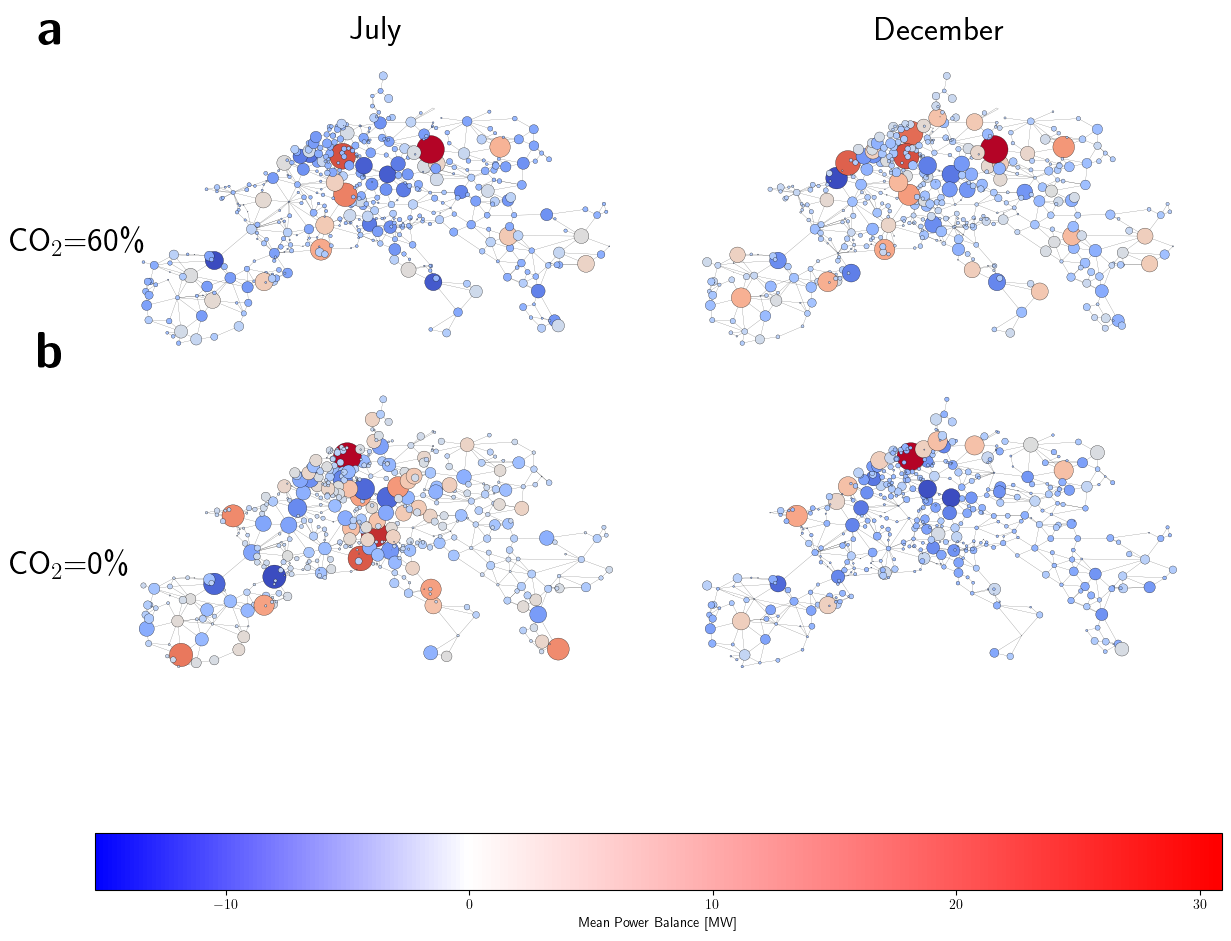

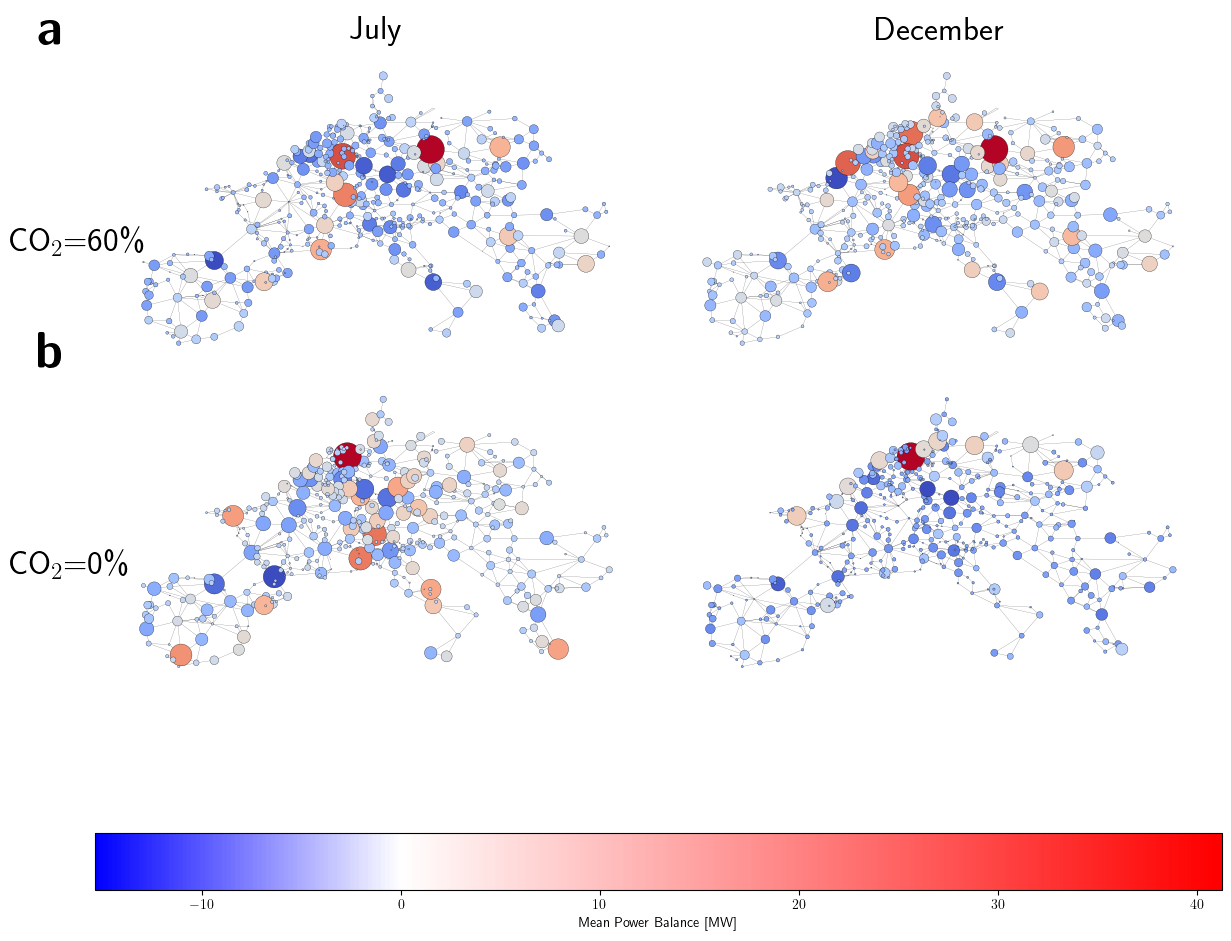

In [59]:
import matplotlib.cm


mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

for ignore_storage in [True, False]:
    
    target_levels = [0.6, 0.0]

    f = plt.figure(figsize=(24, 12))
    # gs = GridSpec(2, 3, figure=f)
    # ax1 = [f.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
    #        for i in range(2)]
    # ax2 = [f.add_subplot(gs[1, i], projection=ccrs.PlateCarree())
    #        for i in range(2)]
    # axs_clust = [ax1, ax2]
    # ax3 = f.add_subplot(gs[0, 2])
    outer = GridSpec(1, 2, width_ratios = [2, 1]) 
    # gs = GridSpec(2, 3, figure=f)
    gs_left = GridSpecFromSubplotSpec(2, 2, subplot_spec = outer[0], wspace=-0.0, hspace=0.0)
    gs_right = GridSpecFromSubplotSpec(2, 1, subplot_spec = outer[1], height_ratios=[1, 0.6])

    # ax1 = [f.add_subplot(gs_left[0, i], projection=ccrs.PlateCarree())
    #        for i in range(2)]
    # ax2 = [f.add_subplot(gs_left[1, i], projection=ccrs.PlateCarree())
    #        for i in range(2)]
    ax1 = [f.add_subplot(gs_left[0, i])
        for i in range(2)]
    ax2 = [f.add_subplot(gs_left[1, i])
        for i in range(2)]
    axs_primary = [ax1, ax2]
    # ax3 = f.add_subplot(gs_right[0, 0])
    # ax3_legend = f.add_subplot(gs_right[1, 0])
    # ax4 = f.add_subplot(outer[1, 1])
    labels = [[r'\textbf{a}', r'', r'\textbf{c}'],
            [r'\textbf{b}', '', r'\textbf{d}', '', '']]

    ##### panal a and b #######

    vmax = -np.inf
    vmin = np.inf
    months = [7, 12]

    for i, target_level in enumerate(target_levels):
        n = network = data_handling.load_pypsa_network_from_path(path_to_pypsa_network_sclopf +
                            f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc", True)
        nodal_balance = (
            n.generators_t.p.mul(n.generators.sign)
            .T.groupby(n.generators["bus"])
            .sum()
        )
        if ignore_storage:
            nodal_balance = nodal_balance.add(
                n.storage_units_t.p.T.groupby(n.storage_units["bus"]).sum(),
                fill_value=0,
            )
        nodal_balance = nodal_balance.add(-n.loads_t.p.T.groupby(n.loads["bus"]).sum(), fill_value=0)

        ## add hvdc link subtraction/addition
        nodal_balance = nodal_balance.add(
            -n.links_t.p0.T.groupby(n.links["bus0"]).sum(), fill_value=0
        )
        nodal_balance = nodal_balance.add(
            -n.links_t.p1.T.groupby(n.links["bus1"]).sum(), fill_value=0
        )
        nodal_balance = nodal_balance.mul(network.snapshot_weightings.generators, axis="columns")

        # nodal_balance = -nodal_balance
        nodal_balance = nodal_balance.T
        
        for ii, month in enumerate(months):

            axs_primary[i][ii].axis("off")
            current_snapshots = n.snapshots[n.snapshots.month == month]
            #    current_gen = n.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").loc[current_snapshots].sum().mul(network.generators.sign)
            #    current_gen = current_gen.groupby([n.generators["bus"], n.generators["carrier"]]).sum()
            #    n.plot(bus_sizes=nodal_balance[nodal_balance.index.month==month].abs()/7e6,
            #           color=nodal_balance[nodal_balance.index.month==month],
            #           cmap="coolwarm",
            #           line_colors='black',
            #           link_colors='black',
            #           link_widths=0.5,
            #           line_widths=0.5,
            #           ax=axs_primary[i][j])
            nodal_balance_month = nodal_balance[nodal_balance.index.month==month].mean(axis=0).loc[list(nx_graph.nodes)]/network.snapshot_weightings.generators[current_snapshots].sum()
            vmax = max(vmax,nodal_balance_month.max())
            vmin = min(vmin,nodal_balance_month.min())
            nodes = nx.draw_networkx_nodes(
                nx_graph,
                pos=pos,
                ax=axs_primary[i][ii],
                node_size=nodal_balance_month.abs()/nodal_balance_month.abs().max()*400,
                node_color=nodal_balance_month,
                cmap="coolwarm",
                # vmax=np.log10(vmax_node),
                # vmin=np.log10(vmin_node),

                )
            nodes.set_edgecolor("black")
            nodes.set_linewidth(0.2)
            edges = nx.draw_networkx_edges(
                    nx_graph,
                    pos=pos,
                    ax=axs_primary[i][ii],
                    width=0.1,
                    edge_color="black",
            )

            if i == 0:
                    axs_primary[i][ii].set_title(current_snapshots.month_name()[0], fontsize=24)

            axs_primary[i][ii].text(0 - 0.1, 1+0.05,
                            labels[i][ii],
                            fontsize=36,
                            weight='bold',
                            verticalalignment='center',
                            transform=axs_primary[i][ii].transAxes)


    axs_primary[0][0].text(0 - 0.15, 0.4,
                rf'CO$_2$={int(round(target_levels[0]*100))}\% ',
                fontsize=24,
                verticalalignment='center',
                transform=axs_primary[0][0].transAxes)
    axs_primary[1][0].text(0 - 0.15, 0.4,
                rf'CO$_2$={int(round(target_levels[1]*100))}\% ',
                fontsize=24,
                verticalalignment='center',
                transform=axs_primary[1][0].transAxes)

    # sm = plt.cm.ScalarMappable(
    #     cmap="coolwarm", norm=mplcolors.Normalize(vmin=vmin, vmax=vmax))
    # cb = f.colorbar(sm, ax=np.array(axs_primary), orientation="horizontal")
    cmap = matplotlib.cm.get_cmap("bwr")
    cmap = shiftedColorMap(cmap, start=0, midpoint=1 - vmax / (vmax + abs(vmin)), stop=1)
    sm = plt.cm.ScalarMappable(
        cmap=cmap, norm=mplcolors.Normalize(vmin=vmin, vmax=vmax))
        # cmap=cmap, norm=mplcolors.TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax))

        # cmap="coolwarm", norm=mplcolors.CenteredNorm(vcenter=0))
    # colorbar_axis = f.add_axes([0.2, 0.0, 0.5, 0.02])
    cb = f.colorbar(sm, ax=np.array(axs_primary), orientation="horizontal", location="bottom", label="Mean Power Balance [MW]")
    # cb.set_ylim(vmin,vmax)
    # add ticks
    # cb.set_ticks([vmin, vmax])

    fig_path = save_path+'nodal_balance_versus_co2level'
    if ignore_storage:
        fig_path += "_no_storage"
    fig_path += '.pdf'
    plt.savefig(fig_path, bbox_inches='tight')

<Axes: xlabel='snapshot'>

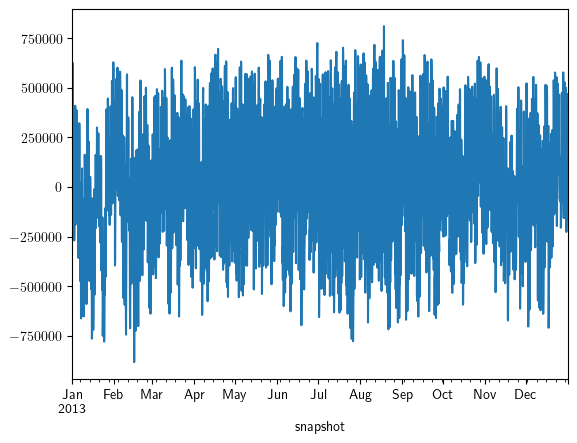

In [60]:
nodal_balance.sum(axis=1).plot()

<Axes: xlabel='snapshot'>

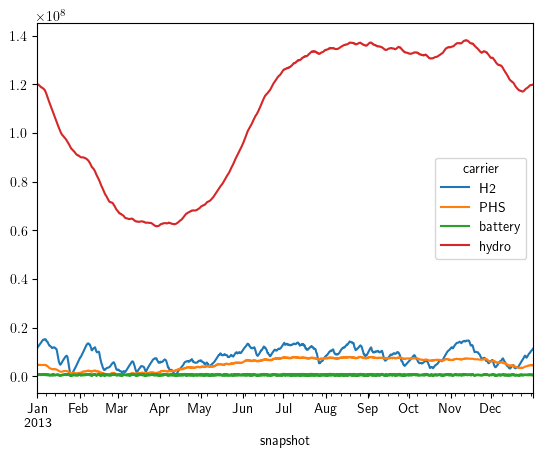

In [61]:
n = networks[0.0]
state_of_charge_by_carrier = n.storage_units_t["state_of_charge"].groupby(n.storage_units.carrier, axis=1)
state_of_charge_by_carrier.sum().plot()

# Figure 4: inertia

In [62]:
inertia_time = np.load(path_to_pre_outage_sclopf +
                       f'inertia_time_series_all_co2ls_{n_nodes}.npy')
inertia_generation = np.load(
    path_to_pre_outage_sclopf + f'min_max_nodal_inertia_generation_all_co2ls_{n_nodes}.npy')


co2 level: 0.6
1636.6884269866744
977.3197127080118
268.8614760357189
co2 level: 0.0
855.3728622039505
370.05327903239083
89.76995870578266


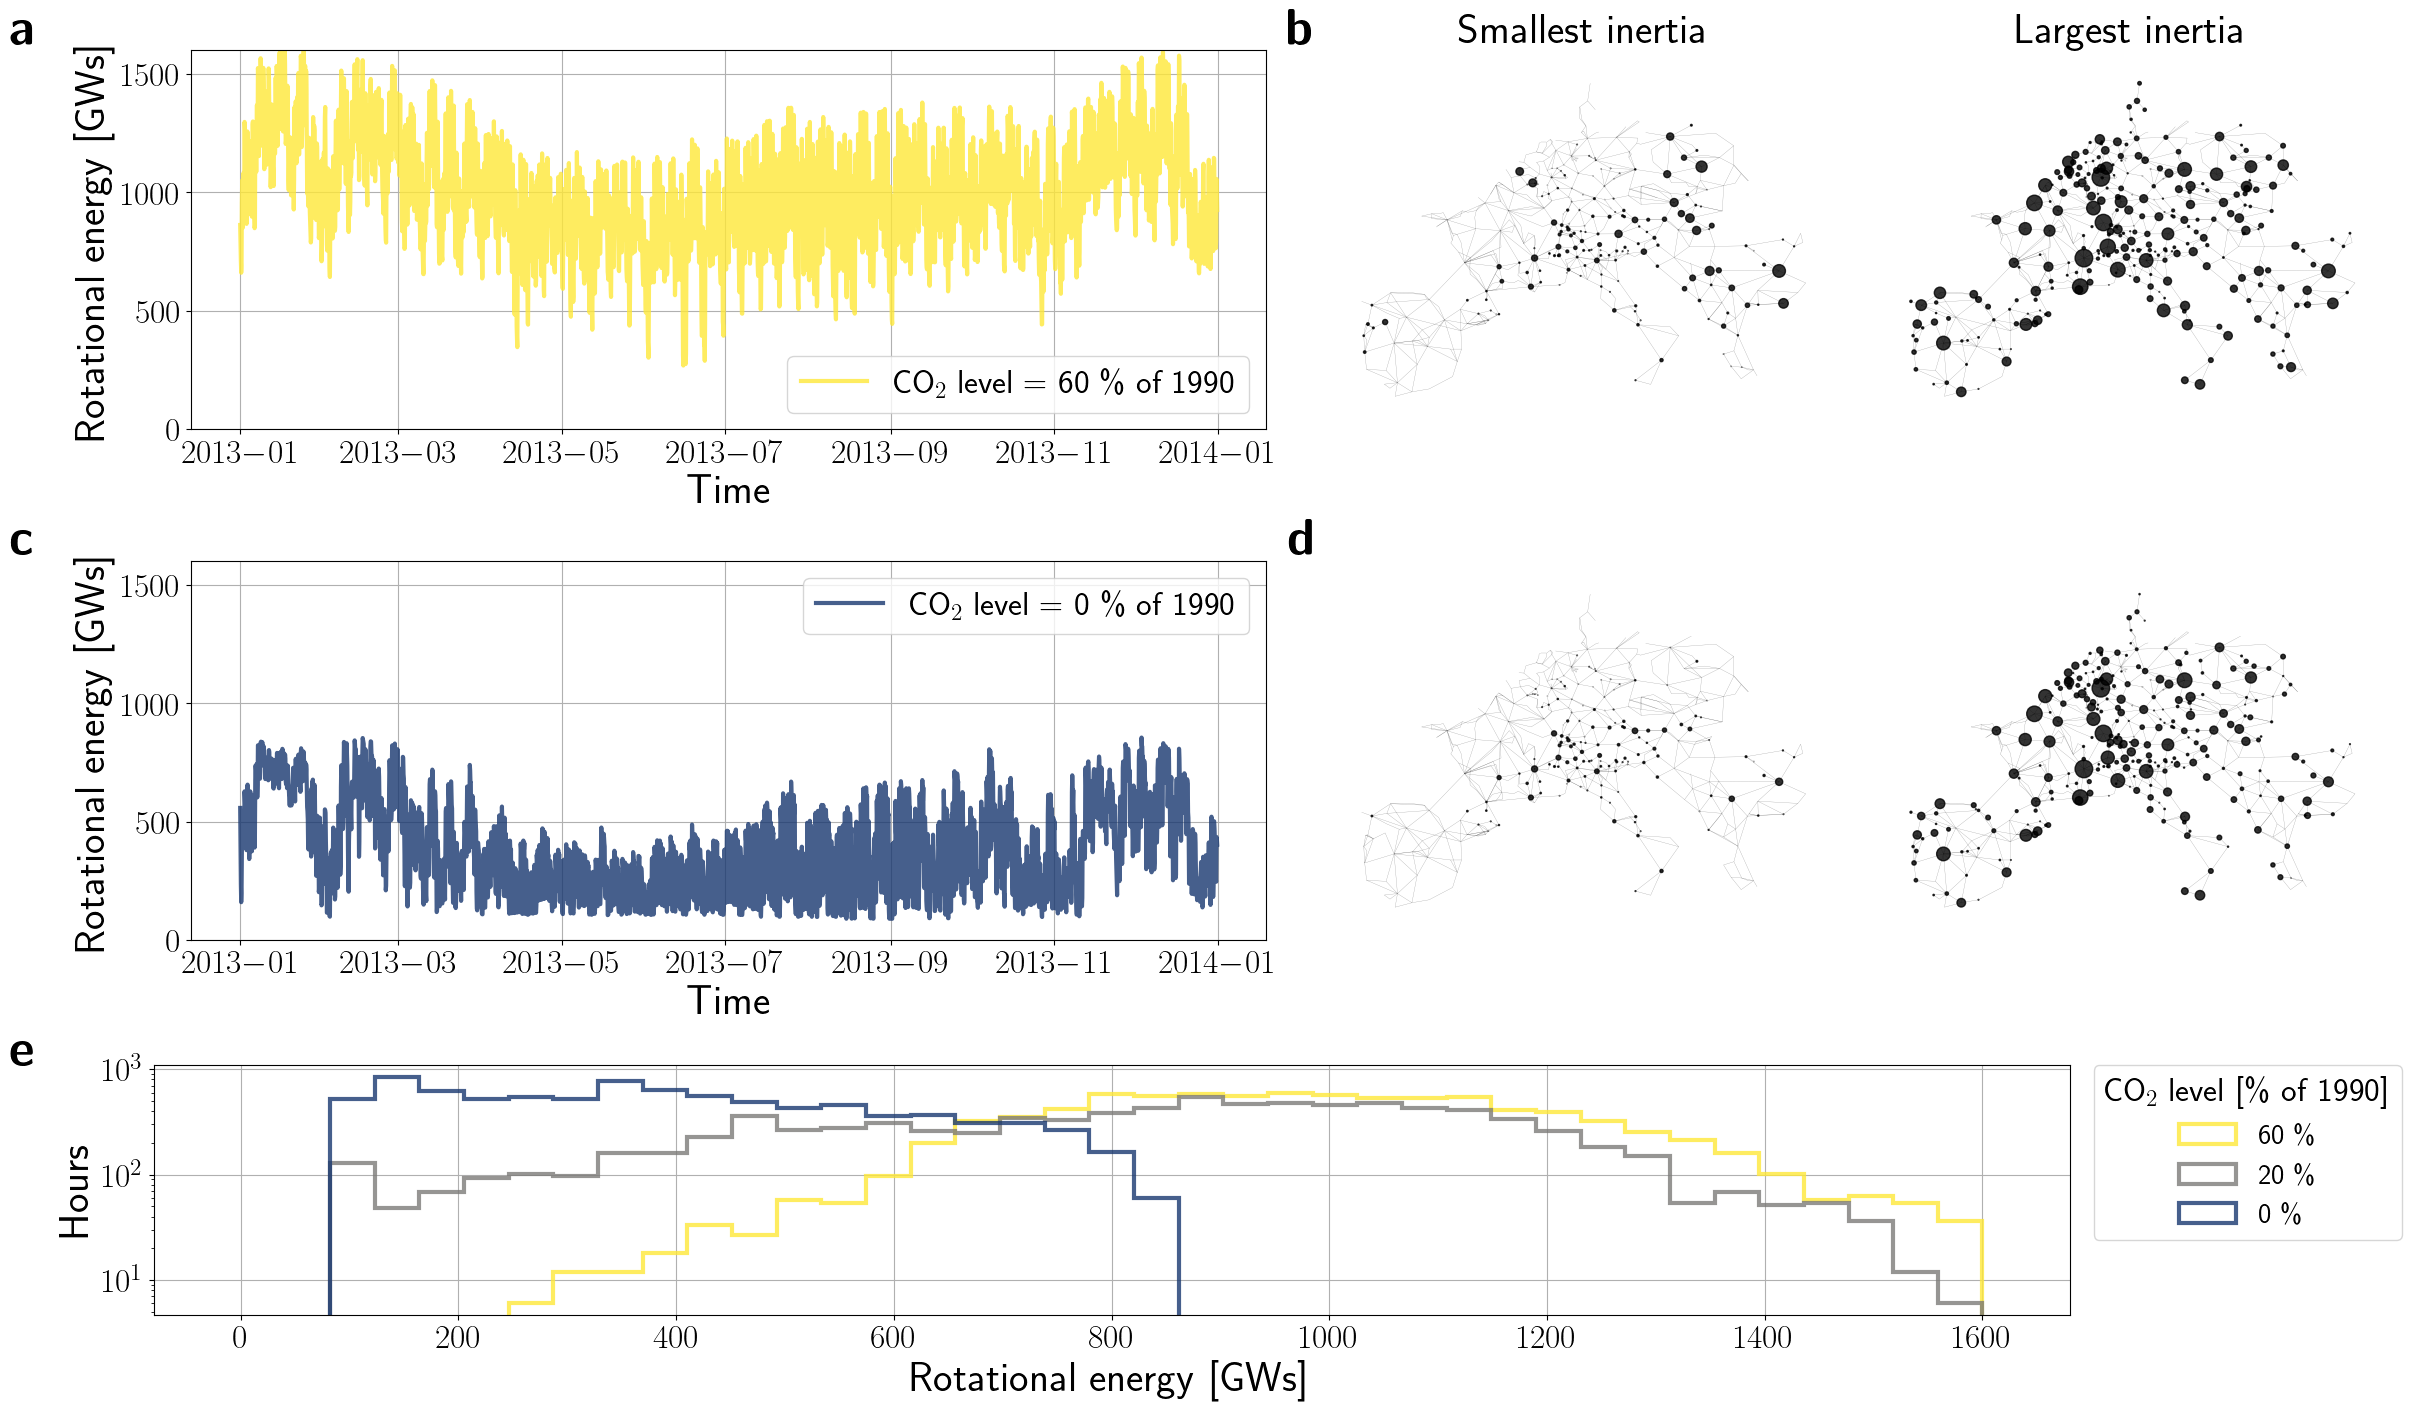

In [63]:
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')
labels = [[r'\textbf{a}', r'\textbf{b}'], [
    r'\textbf{c}', r'\textbf{d}'], [r'\textbf{e}']]
f = plt.figure(figsize=(24, 14), constrained_layout=True)
gs_maps = GridSpec(3, 4, figure=f)
gs_probs = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_maps[2, :], width_ratios=[8, 1])
axs_probs_plot = f.add_subplot(gs_probs[0, 0])
axs_probs_legend = f.add_subplot(gs_probs[0, 1])
ax2 = f.add_subplot(gs_maps[0, :2])
ax3 = f.add_subplot(gs_maps[1, :2])
ax21 = f.add_subplot(gs_maps[0, 2])
ax22 = f.add_subplot(gs_maps[0, 3])
ax31 = f.add_subplot(gs_maps[1, 2])
ax32 = f.add_subplot(gs_maps[1, 3])
axs_primary = [[ax21, ax22], [ax31, ax32]]

target_levels = [0.60, 0.0]

########## panel  e: inertia histograms ############

cmap = plt.get_cmap('cividis_r')
bins = np.linspace(0, 1600, 40)

for count, level in enumerate(selected_co2ls[::-1]):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    # ax.hist(np.repeat(inertia_time[ind], network.snapshot_weightings.generators)/1000,
    axs_probs_plot.hist(inertia_time[ind]/1000,
            weights=network.snapshot_weightings.generators,
            bins=bins,
            histtype='step',
            label=r'{} \%'.format(int(round(level*100))),
            linewidth=3,
            color=cmap(ind/len(co2ls)),
            alpha=0.8)
axs_probs_plot.xaxis.offsetText.set_fontsize(24)

leg = axs_probs_plot.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')
h, l = axs_probs_plot.get_legend_handles_labels()
leg = axs_probs_legend.legend(h, l, borderaxespad=0, fontsize=20.5, title=r'CO$_2$ level [\% of 1990]')
# axs_probs_legend.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')
axs_probs_legend.axis("off")
# leg=axs_probs_plot.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')

plt.setp(leg.get_title(),fontsize=24)
axs_probs_plot.tick_params(axis='both', which='both', labelsize=24)
axs_probs_plot.set_xlabel('Rotational energy [GWs]',  fontsize=30)
axs_probs_plot.set_ylabel('Hours', fontsize=30)
axs_probs_plot.set_yscale('log')
axs_probs_plot.grid()
axs_probs_plot.get_legend().remove()


############# panels a and c: inertia time series ################

axes = [ax2, ax3]

for j, level in enumerate(target_levels):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    print(f"co2 level: {level}")
    print(np.amax(inertia_time[ind]/1000))
    print(np.median(inertia_time[ind]/1000))
    print(np.amin(inertia_time[ind]/1000))
    axes[j].plot(network.snapshots,
                 inertia_time[ind]/1000,
                 color=cmap(ind/len(co2ls)),
                 lw=3,
                 alpha=0.8,
                 label=r'$\text{CO}_2\text{ level} =$ '+ '{} \% of 1990'.format(int(round(level*100))))
    axes[j].legend(fontsize=24)
    axes[j].tick_params(axis='both', which='both', labelsize=24)
    axes[j].set_ylabel('Rotational energy [GWs]', fontsize=30)
    axes[j].set_xlabel('Time', fontsize=30)
    axes[j].set_ylim([0, 1600])
    axes[j].yaxis.offsetText.set_fontsize(24)
    axes[j].grid()


########### panels b and d: maps with nodal inertia ###############

target_levels = [0.60, 0.05]
titles = ['Smallest inertia', 'Largest inertia']

for j, level in enumerate(target_levels):

    ind = np.where(co2ls == level)[0][0]
    
    for i in range(len(titles)):
        nx.draw_networkx_nodes(nx_graph,
                               pos,
                               ax=axs_primary[j][i],
                               node_size=inertia_generation[ind, i]/300,
                               alpha=0.8,
                               node_color='black')
        nx.draw_networkx_edges(nx_graph,
                               pos,
                               ax=axs_primary[j][i],
                               alpha=0.4,
                               width=0.2)
        if j == 0:
            axs_primary[j][i].set_title(titles[i], fontsize=30)
        axs_primary[j][i].axis('off')

# panel labels
ax3.text(0 - 2.25*0.075, 1+0.05,
         labels[1][0],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax3.transAxes)
ax2.text(0 - 2.25*0.075, 1+0.05,
         labels[0][0],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax2.transAxes)
ax31.text(0 - 0.05, 1+0.05,
          labels[1][1],
          fontsize=36,
          weight='bold',
          verticalalignment='center',
          transform=ax31.transAxes)
ax21.text(0 - 0.05, 1+0.05,
          labels[0][1],
          fontsize=36,
          weight='bold',
          verticalalignment='center',
          transform=ax21.transAxes)
axs_probs_plot.text(0 - 0.075, 1+0.05,
        labels[2][0],
        fontsize=36,
        weight='bold',
        verticalalignment='center',
        transform=axs_probs_plot.transAxes)


plt.savefig(save_path+'total_system_inertia.pdf',bbox_inches = 'tight')


# Figure 3: SPI

In [64]:
mean_consumption_vector = np.load(
    path_to_pre_outage_sclopf + f'mean_nodal_consumption_all_co2ls_{n_nodes}.npy')
weighted_mean_consumption_vector = np.load(
    path_to_pre_outage_sclopf + f'weighted_mean_nodal_consumption_all_co2ls_{n_nodes}.npy')
dipole_vector = np.load(path_to_pre_outage_sclopf +
                        f'dipole_vector_time_series_all_co2ls_{n_nodes}.npy')
vec_norm = np.load(path_to_pre_outage_sclopf + f'spi_time_series_all_co2ls_{n_nodes}.npy')

## original figure

Figure 3


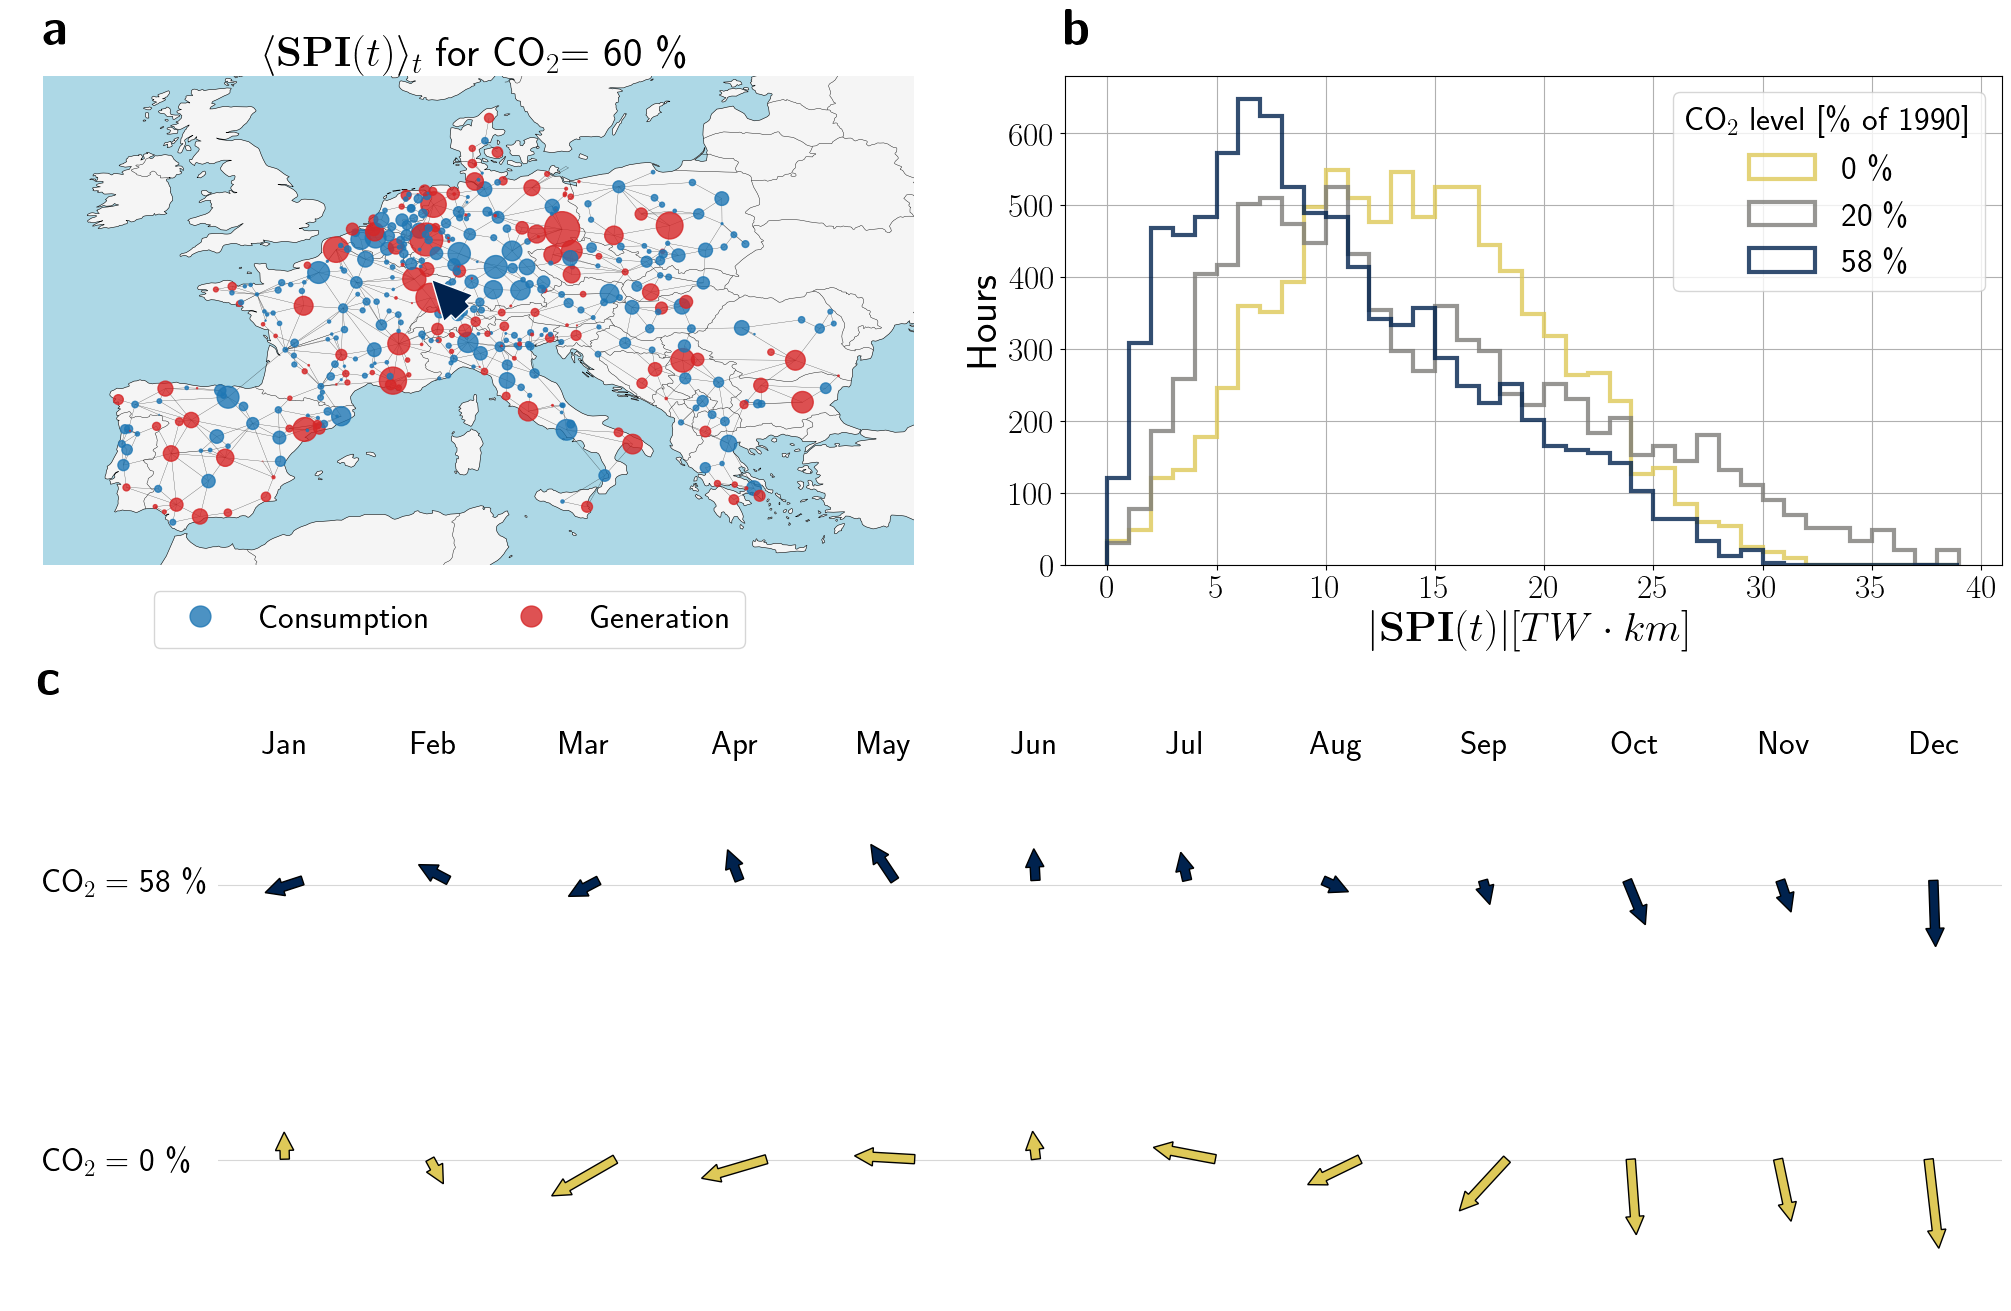

In [66]:
print("Figure 3")

mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
labels = [[r'\textbf{a}', r'\textbf{b}'], [
    r'\textbf{c}', r'\textbf{d}', r'\textbf{e}', r'\textbf{f}']]

f = plt.figure(figsize=(20, 13), constrained_layout=True)
gs0= GridSpec(2,1, figure=f, hspace=0.9) # outer grid
gs_horizontal_hists = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs0[0])
axs_probs = f.add_subplot(gs_horizontal_hists[0], projection=ccrs.PlateCarree())
ax2 = f.add_subplot(gs_horizontal_hists[1])
gs_vectors = GridSpecFromSubplotSpec(2, 13, subplot_spec=gs0[1], hspace=0)
# axs_leg = f.add_subplot(gs0[0,0])
# axs_leg.axis('off')
ax_vec_0 = f.add_subplot(gs_vectors[0, 0])
axs_co2_1 = f.add_subplot(gs_vectors[1, 0])
ax_vec_0.axis('off')
axs_co2_1.axis('off')

axs_primary = [f.add_subplot(gs_vectors[0, i+1], projection=ccrs.PlateCarree())
       for i in range(12)]
axs_secondary = [f.add_subplot(gs_vectors[1, i+1], projection=ccrs.PlateCarree())
        for i in range(12)]


##########  panel a : Mean SPI on map for 60% co2 level  ###################

resolution = "50m"
color_geomap = {'ocean': 'lightblue', 'land': 'whitesmoke'}

axs_probs.add_feature(cartopy.feature.LAND.with_scale(resolution),
               facecolor=color_geomap['land'])
axs_probs.add_feature(cartopy.feature.OCEAN.with_scale(resolution),
               facecolor=color_geomap['ocean'])
axs_probs.coastlines(linewidth=0.4, zorder=2, resolution=resolution)
border = cartopy.feature.BORDERS.with_scale(resolution)
axs_probs.add_feature(border, linewidth=0.3)
cmap = plt.get_cmap('cividis')
position_vector = np.array([pos[n] for n in nx_graph.nodes()])
mean_pos = [np.mean(position_vector[:, 0]), np.mean(position_vector[:, 1])]


nx.draw_networkx_edges(nx_graph,
                       pos,
                       ax=axs_probs,
                       alpha=0.8,
                       width=0.2)

scale_factor = 2e4

# current_vec = np.mean(dipole_vector, axis=2)
# use average weighted by snapshot weight
current_vec = np.average(dipole_vector, weights=network.snapshot_weightings.generators, axis=2)
vec = weighted_mean_consumption_vector
plot_co2ls = [0.6]

for i, level in enumerate(plot_co2ls):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    node_colours = ['tab:red' if vec[ind, i] <
                    0 else 'tab:blue' for i in range(len(nx_graph.nodes()))]

    nx.draw_networkx_nodes(nx_graph,
                           pos,
                           ax=axs_probs,
                           node_size=np.abs(vec[ind])/30,
                           node_color=node_colours,
                           alpha=0.8)

    axs_probs.arrow(mean_pos[0],
             mean_pos[1],
             current_vec[ind, 0]/scale_factor,
             current_vec[ind, 1]/scale_factor,
             head_width=2.0,
             width=1.0,
             head_length=2.0,
            #  alpha  = 1,
             facecolor=cmap(ind/len(co2ls)),
            #  facecolor="cmap(ind/len(co2ls))",
             edgecolor="white",
             zorder=np.inf)
    axs_probs.axis('off')


# add legend

blue_circle = mlines.Line2D([], [], color='tab:blue', marker='o', linestyle='None',
                          markersize=15, label='Consumption', alpha=0.8)
red_circle = mlines.Line2D([], [], color='tab:red', marker='o', linestyle='None',
                          markersize=15, label='Generation', alpha=0.8)
axs_probs.legend(handles=[blue_circle,red_circle], bbox_to_anchor=(0.825,-0.02,0,0), ncol=2, fontsize=24)


########### panel b: Histogrms of SPI norm ##############

bins = np.arange(0, np.quantile(vec_norm, 0.9999), 1)  # np.arange(0,0.08,0.001)#


for i, level in enumerate(selected_co2ls):

    # weighted_vec_norm = np.repeat(vec_norm[np.where(co2ls == level)[0][0],:], network.snapshot_weightings.generators.values.astype(int))
    
    ind = np.where(co2ls == level)[0][0]
    ax2.hist(
            # weighted_vec_norm,
            vec_norm[ind],
            weights=network.snapshot_weightings.generators.values.astype(int),
             bins=bins,
             histtype='step',
             label='{} \%'.format(int(round(get_actual_co2_level(level)*100))),
             linewidth=3,
             color=cmap(ind/len(co2ls)),
             #density=True,
             alpha=0.8)
leg=ax2.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')
plt.setp(leg.get_title(),fontsize=24)
ax2.tick_params(axis='both', which='both', labelsize=24)
ax2.set_xlabel(r'$|\mathbf{SPI}(t)| [TW\cdot km]$', fontsize=30)
ax2.set_ylabel('Hours', fontsize=30)
ax2.grid(True)
ax2.yaxis.offsetText.set_fontsize(24)

############   panel c: Seasonal dependency of SPI vectors ##################

old_ind = 0
co2lvls_spi_plot = [0.6, 0.0]
for ii in range(12):

    new_ind = old_ind + \
        len(network.snapshots[network.snapshots.month == int(ii+1)])

    current_level = co2lvls_spi_plot[0]
    ind = np.where(co2ls == current_level)[0][0]

    current_vec_0 = np.median(np.repeat(dipole_vector[ind, 0, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
    current_vec_1 = np.median(np.repeat(dipole_vector[ind, 1, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
    # for mean use np.average with weights

    axs_primary[ii].arrow(mean_pos[0],
                                    mean_pos[1],
                                    current_vec_0/scale_factor,
                                    current_vec_1/scale_factor,
                                    head_width=2.0,
                                    width=1.0,
                                    head_length=2.0,
                                    #alpha  = .8,
                                    facecolor=cmap(ind/len(co2ls)))


    current_vec = np.median(dipole_vector[:, :, old_ind:new_ind], axis=2) # maybe take mean?!
    
    current_level = co2lvls_spi_plot[1]

    ind = np.where(co2ls == current_level)[0][0]

    current_vec_0 = np.median(np.repeat(dipole_vector[ind, 0, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
    current_vec_1 = np.median(np.repeat(dipole_vector[ind, 1, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
    axs_secondary[ii].arrow(mean_pos[0],
                                    mean_pos[1],
                                    current_vec_0/scale_factor,
                                    current_vec_1/scale_factor,
                                    head_width=2.0,
                                    width=1.0,
                                    head_length=2.0,
                                    #alpha  = .8,
                                    facecolor=cmap(ind/len(co2ls)))
    
    
    axs_primary[ii].axis('off')
    axs_secondary[ii].axis('off')
    
    axs_primary[ii].set_ylim([31.707498915424157, 60.29928495567561])
    axs_secondary[ii].set_ylim([31.707498915424157, 60.29928495567561])

    old_ind = new_ind

# common grid behind spi vectors
axs_grid = f.add_subplot(gs_vectors[:,1:], zorder=-1)
for _, spine in axs_grid.spines.items():
    spine.set_visible(False)
axs_grid.tick_params(labelleft=False, labelbottom=False, bottom=False, left=False, right=False )
axs_grid.set_yticks([0.26, 0.77])
#axs_grid.set_xlim([0,12])
#axs_grid.set_xticks(np.arange(1,12)-0.2)
axs_grid.grid(axis='y', alpha=0.5)



###########  panel labels ###################

ax2.text(0, 1+0.09,
         labels[0][1],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax2.transAxes)

axs_probs.text(0, 1+0.09,
        labels[0][0],
        fontsize=36,
        weight='bold',
        verticalalignment='center',
        transform=axs_probs.transAxes)

ax_vec_0.text(0.2, 1+0.3,
                    labels[1][0],
                    fontsize=36,
                    weight='bold',
                    verticalalignment='center',
                    transform=ax_vec_0.transAxes)

# axs_co2.text(0.5, 0.25, r'\textbf{c}', fontsize=36,
#                     weight='bold',
#                     verticalalignment='center',)#, rotation=90, horizontalalignment='center')
# axs_co2_0.text(0.5, 0.25, r'\textbf{c}', fontsize=24, rotation=90, horizontalalignment='center')
ax_vec_0.text(0.25, 0.5, rf'CO$_2 =$ {int(round(get_actual_co2_level(co2lvls_spi_plot[0])*100))} \%', fontsize=24, rotation=0, horizontalalignment='left')
axs_co2_1.text(0.25, 0.5, rf'CO$_2 =$ {int(round(get_actual_co2_level(co2lvls_spi_plot[1])*100))} \%', fontsize=24, rotation=0, horizontalalignment='left')
ax_vec_0.axis('off')

axs_probs.set_title(r'$\langle \mathbf{SPI}(t)\rangle_t$ for CO$_2$= 60 \%', fontsize=30)


for ii in range(12):
    axs_primary[ii].set_title(network.snapshots[network.snapshots.month == ii+1][0].month_name()[:3],
                                       fontsize=24,
                                       pad=0)
plt.savefig(save_path+'inital_grid_situation.pdf',bbox_inches = 'tight')

## 3 vectors

/home/mtitz/.conda/envs/system_split/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mtitz/.conda/envs/system_split/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


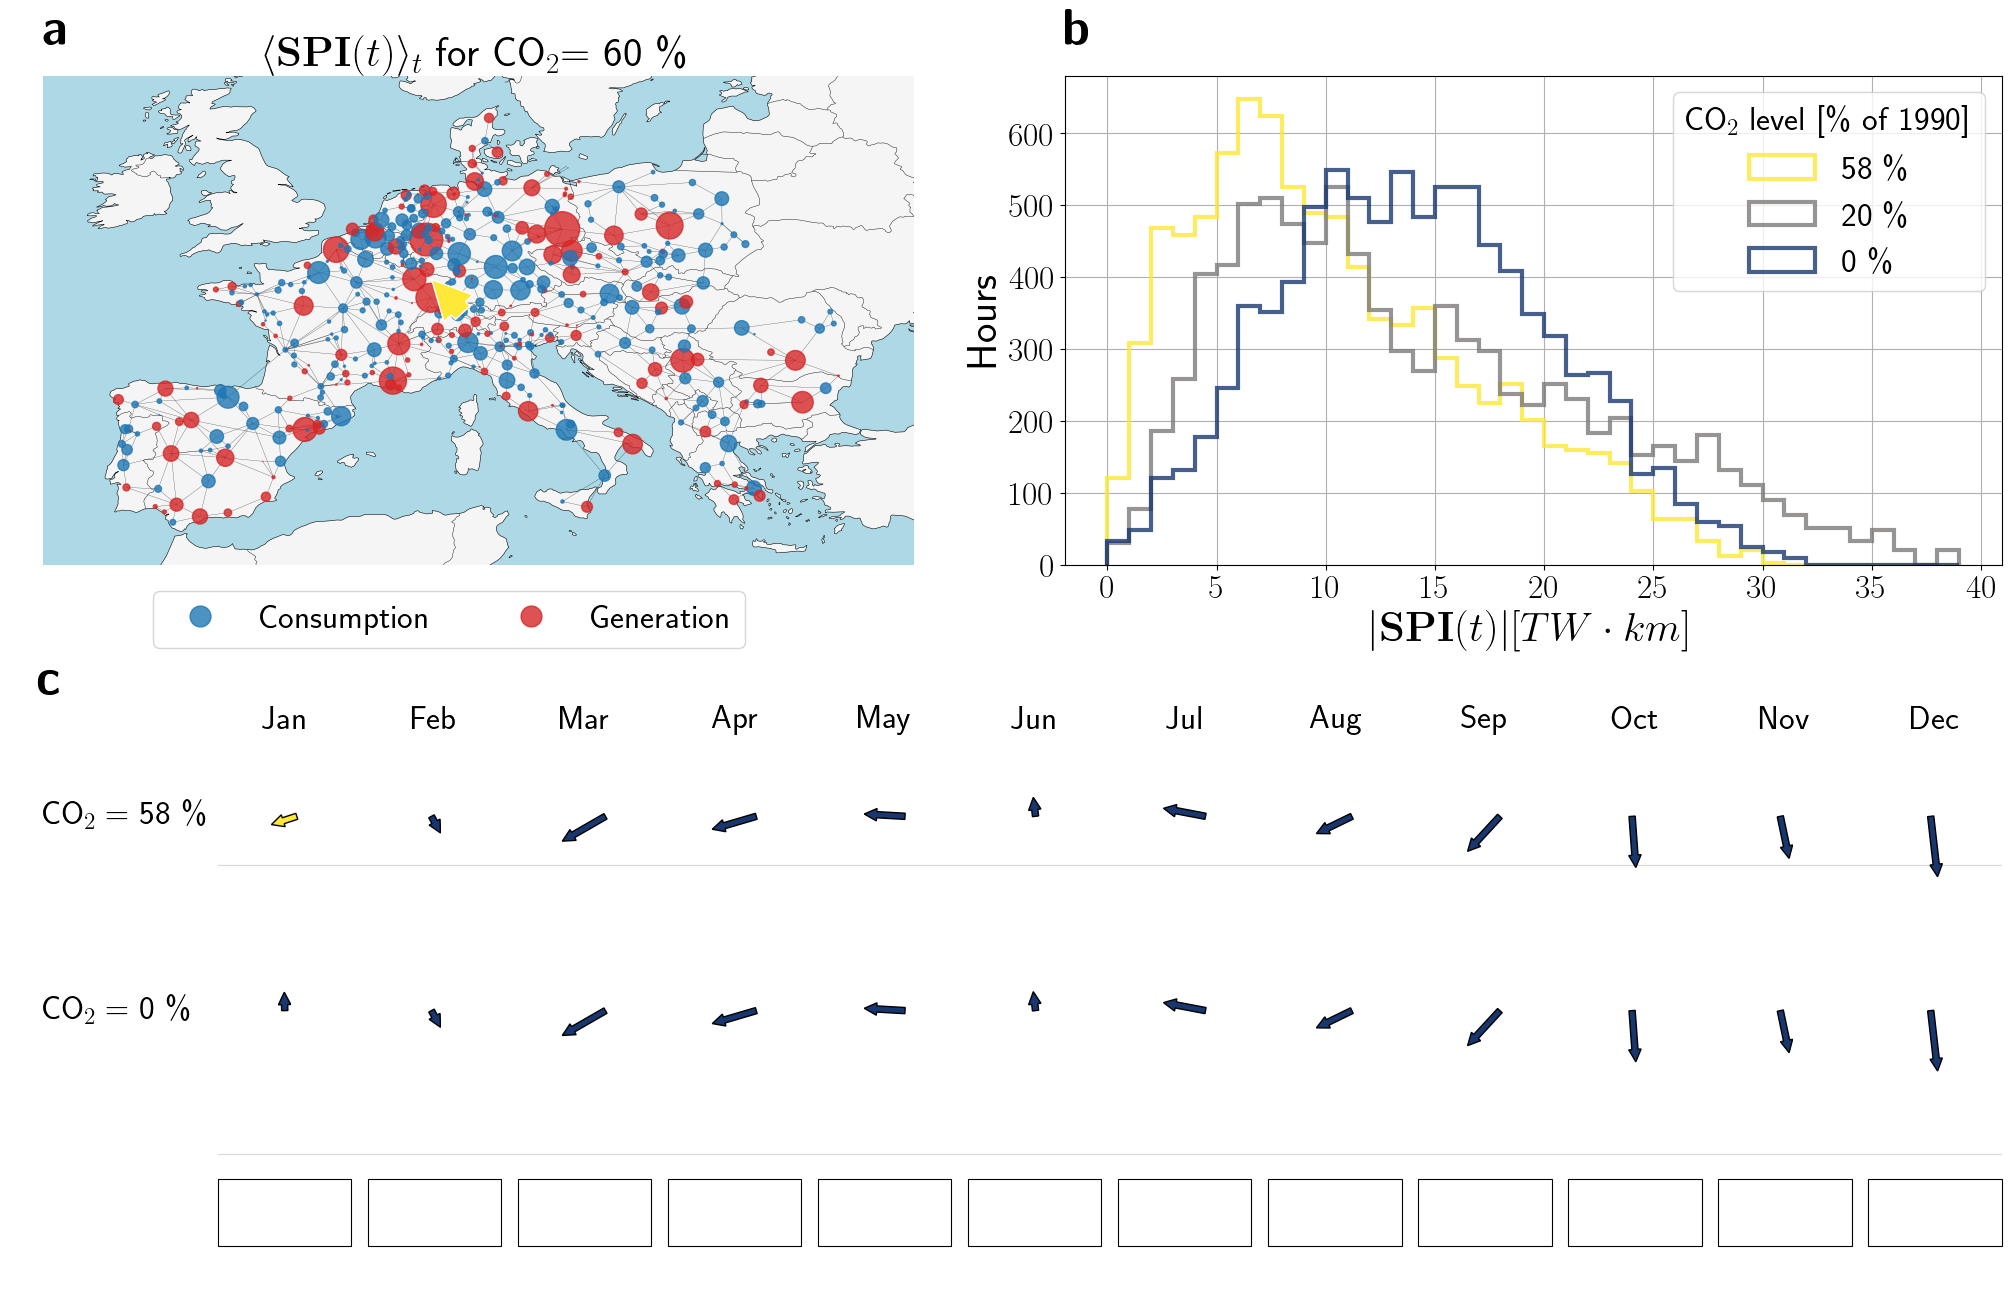

In [67]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
labels = [[r'\textbf{a}', r'\textbf{b}'], [
    r'\textbf{c}', r'\textbf{d}', r'\textbf{e}', r'\textbf{f}']]

f = plt.figure(figsize=(20, 13), constrained_layout=True)
gs0= GridSpec(2,1, figure=f, hspace=0.9) # outer grid
gs_horizontal_hists = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs0[0])
axs_probs = f.add_subplot(gs_horizontal_hists[0], projection=ccrs.PlateCarree())
ax2 = f.add_subplot(gs_horizontal_hists[1])
gs_vectors = GridSpecFromSubplotSpec(3, 13, subplot_spec=gs0[1], hspace=0)
# axs_leg = f.add_subplot(gs0[0,0])
# axs_leg.axis('off')
ax_vec_0 = f.add_subplot(gs_vectors[0, 0])
axs_co2_1 = f.add_subplot(gs_vectors[1, 0])
ax_vec_0.axis('off')
axs_co2_1.axis('off')

axs_primary = [f.add_subplot(gs_vectors[0, i+1], projection=ccrs.PlateCarree())
       for i in range(12)]
axs_secondary = [f.add_subplot(gs_vectors[1, i+1], projection=ccrs.PlateCarree())
        for i in range(12)]
axs_tertiary = [f.add_subplot(gs_vectors[2, i+1], projection=ccrs.PlateCarree())
        for i in range(12)]


##########  panel a : Mean SPI on map for 60% co2 level  ###################

resolution = "50m"
color_geomap = {'ocean': 'lightblue', 'land': 'whitesmoke'}

axs_probs.add_feature(cartopy.feature.LAND.with_scale(resolution),
               facecolor=color_geomap['land'])
axs_probs.add_feature(cartopy.feature.OCEAN.with_scale(resolution),
               facecolor=color_geomap['ocean'])
axs_probs.coastlines(linewidth=0.4, zorder=2, resolution=resolution)
border = cartopy.feature.BORDERS.with_scale(resolution)
axs_probs.add_feature(border, linewidth=0.3)
cmap = plt.get_cmap('cividis_r')
position_vector = np.array([pos[n] for n in nx_graph.nodes()])
mean_pos = [np.mean(position_vector[:, 0]), np.mean(position_vector[:, 1])]


nx.draw_networkx_edges(nx_graph,
                       pos,
                       ax=axs_probs,
                       alpha=0.8,
                       width=0.2)

scale_factor = 2e4

# current_vec = np.mean(dipole_vector, axis=2)
# use average weighted by snapshot weight
current_vec = np.average(dipole_vector, weights=network.snapshot_weightings.generators, axis=2)
vec = weighted_mean_consumption_vector
plot_co2ls = [0.6]

for i, level in enumerate(plot_co2ls):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    node_colours = ['tab:red' if vec[ind, i] <
                    0 else 'tab:blue' for i in range(len(nx_graph.nodes()))]

    nx.draw_networkx_nodes(nx_graph,
                           pos,
                           ax=axs_probs,
                           node_size=np.abs(vec[ind])/30,
                           node_color=node_colours,
                           alpha=0.8)

    axs_probs.arrow(mean_pos[0],
             mean_pos[1],
             current_vec[ind, 0]/scale_factor,
             current_vec[ind, 1]/scale_factor,
             head_width=2.0,
             width=1.0,
             head_length=2.0,
            #  alpha  = 1,
             facecolor=cmap(ind/len(co2ls)),
            #  facecolor="cmap(ind/len(co2ls))",
             edgecolor="white",
             zorder=np.inf)
    axs_probs.axis('off')


# add legend

blue_circle = mlines.Line2D([], [], color='tab:blue', marker='o', linestyle='None',
                          markersize=15, label='Consumption', alpha=0.8)
red_circle = mlines.Line2D([], [], color='tab:red', marker='o', linestyle='None',
                          markersize=15, label='Generation', alpha=0.8)
axs_probs.legend(handles=[blue_circle,red_circle], bbox_to_anchor=(0.825,-0.02,0,0), ncol=2, fontsize=24)


########### panel b: Histogrms of SPI norm ##############

bins = np.arange(0, np.quantile(vec_norm, 0.9999), 1)  # np.arange(0,0.08,0.001)#


for i, level in enumerate(selected_co2ls[::-1]):

    # weighted_vec_norm = np.repeat(vec_norm[np.where(co2ls == level)[0][0],:], network.snapshot_weightings.generators.values.astype(int))
    
    ind = np.where(co2ls == level)[0][0]
    ax2.hist(
            # weighted_vec_norm,
            vec_norm[ind],
            weights=network.snapshot_weightings.generators.values.astype(int),
             bins=bins,
             histtype='step',
             label='{} \%'.format(int(round(get_actual_co2_level(level)*100))),
             linewidth=3,
             color=cmap(ind/len(co2ls)),
             #density=True,
             alpha=0.8)
leg=ax2.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')
plt.setp(leg.get_title(),fontsize=24)
ax2.tick_params(axis='both', which='both', labelsize=24)
ax2.set_xlabel(r'$|\mathbf{SPI}(t)| [TW\cdot km]$', fontsize=30)
ax2.set_ylabel('Hours', fontsize=30)
ax2.grid(True)
ax2.yaxis.offsetText.set_fontsize(24)

############   panel c: Seasonal dependency of SPI vectors ##################

old_ind = 0
# co2lvls_spi_plot = [0.6, 0.0]
for current_level in target_levels:
    for ii in range(12):

        new_ind = old_ind + \
            len(network.snapshots[network.snapshots.month == int(ii+1)])

        ind = np.where(co2ls == current_level)[0][0]

        current_vec_0 = np.median(np.repeat(dipole_vector[ind, 0, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
        current_vec_1 = np.median(np.repeat(dipole_vector[ind, 1, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
        # for mean use np.average with weights

        axs_primary[ii].arrow(mean_pos[0],
                                        mean_pos[1],
                                        current_vec_0/scale_factor,
                                        current_vec_1/scale_factor,
                                        head_width=2.0,
                                        width=1.0,
                                        head_length=2.0,
                                        #alpha  = .8,
                                        facecolor=cmap(ind/len(co2ls)))


        
        current_level = co2lvls_spi_plot[1]

        ind = np.where(co2ls == current_level)[0][0]

        current_vec_0 = np.median(np.repeat(dipole_vector[ind, 0, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
        current_vec_1 = np.median(np.repeat(dipole_vector[ind, 1, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
        axs_secondary[ii].arrow(mean_pos[0],
                                        mean_pos[1],
                                        current_vec_0/scale_factor,
                                        current_vec_1/scale_factor,
                                        head_width=2.0,
                                        width=1.0,
                                        head_length=2.0,
                                        #alpha  = .8,
                                        facecolor=cmap(ind/len(co2ls)))
        
        
        axs_primary[ii].axis('off')
        axs_secondary[ii].axis('off')
        
        axs_primary[ii].set_ylim([31.707498915424157, 60.29928495567561])
        axs_secondary[ii].set_ylim([31.707498915424157, 60.29928495567561])

        old_ind = new_ind

# common grid behind spi vectors
axs_grid = f.add_subplot(gs_vectors[:,1:], zorder=-1)
for _, spine in axs_grid.spines.items():
    spine.set_visible(False)
axs_grid.tick_params(labelleft=False, labelbottom=False, bottom=False, left=False, right=False )
axs_grid.set_yticks([0.26, 0.77])
#axs_grid.set_xlim([0,12])
#axs_grid.set_xticks(np.arange(1,12)-0.2)
axs_grid.grid(axis='y', alpha=0.5)



###########  panel labels ###################

ax2.text(0, 1+0.09,
         labels[0][1],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax2.transAxes)

axs_probs.text(0, 1+0.09,
        labels[0][0],
        fontsize=36,
        weight='bold',
        verticalalignment='center',
        transform=axs_probs.transAxes)

ax_vec_0.text(0.2, 1+0.3,
                    labels[1][0],
                    fontsize=36,
                    weight='bold',
                    verticalalignment='center',
                    transform=ax_vec_0.transAxes)

# axs_co2.text(0.5, 0.25, r'\textbf{c}', fontsize=36,
#                     weight='bold',
#                     verticalalignment='center',)#, rotation=90, horizontalalignment='center')
# axs_co2_0.text(0.5, 0.25, r'\textbf{c}', fontsize=24, rotation=90, horizontalalignment='center')
ax_vec_0.text(0.25, 0.5, rf'CO$_2 =$ {int(round(get_actual_co2_level(co2lvls_spi_plot[0])*100))} \%', fontsize=24, rotation=0, horizontalalignment='left')
axs_co2_1.text(0.25, 0.5, rf'CO$_2 =$ {int(round(get_actual_co2_level(co2lvls_spi_plot[1])*100))} \%', fontsize=24, rotation=0, horizontalalignment='left')
ax_vec_0.axis('off')

axs_probs.set_title(r'$\langle \mathbf{SPI}(t)\rangle_t$ for CO$_2$= 60 \%', fontsize=30)


for ii in range(12):
    axs_primary[ii].set_title(network.snapshots[network.snapshots.month == ii+1][0].month_name()[:3],
                                       fontsize=24,
                                       pad=0)
# plt.savefig(save_path+'inital_grid_situation.pdf',bbox_inches = 'tight')

## new figure, no map

In [68]:
inertia_time = np.load(path_to_pre_outage_sclopf +
                       f'inertia_time_series_all_co2ls_{n_nodes}.npy')/1000

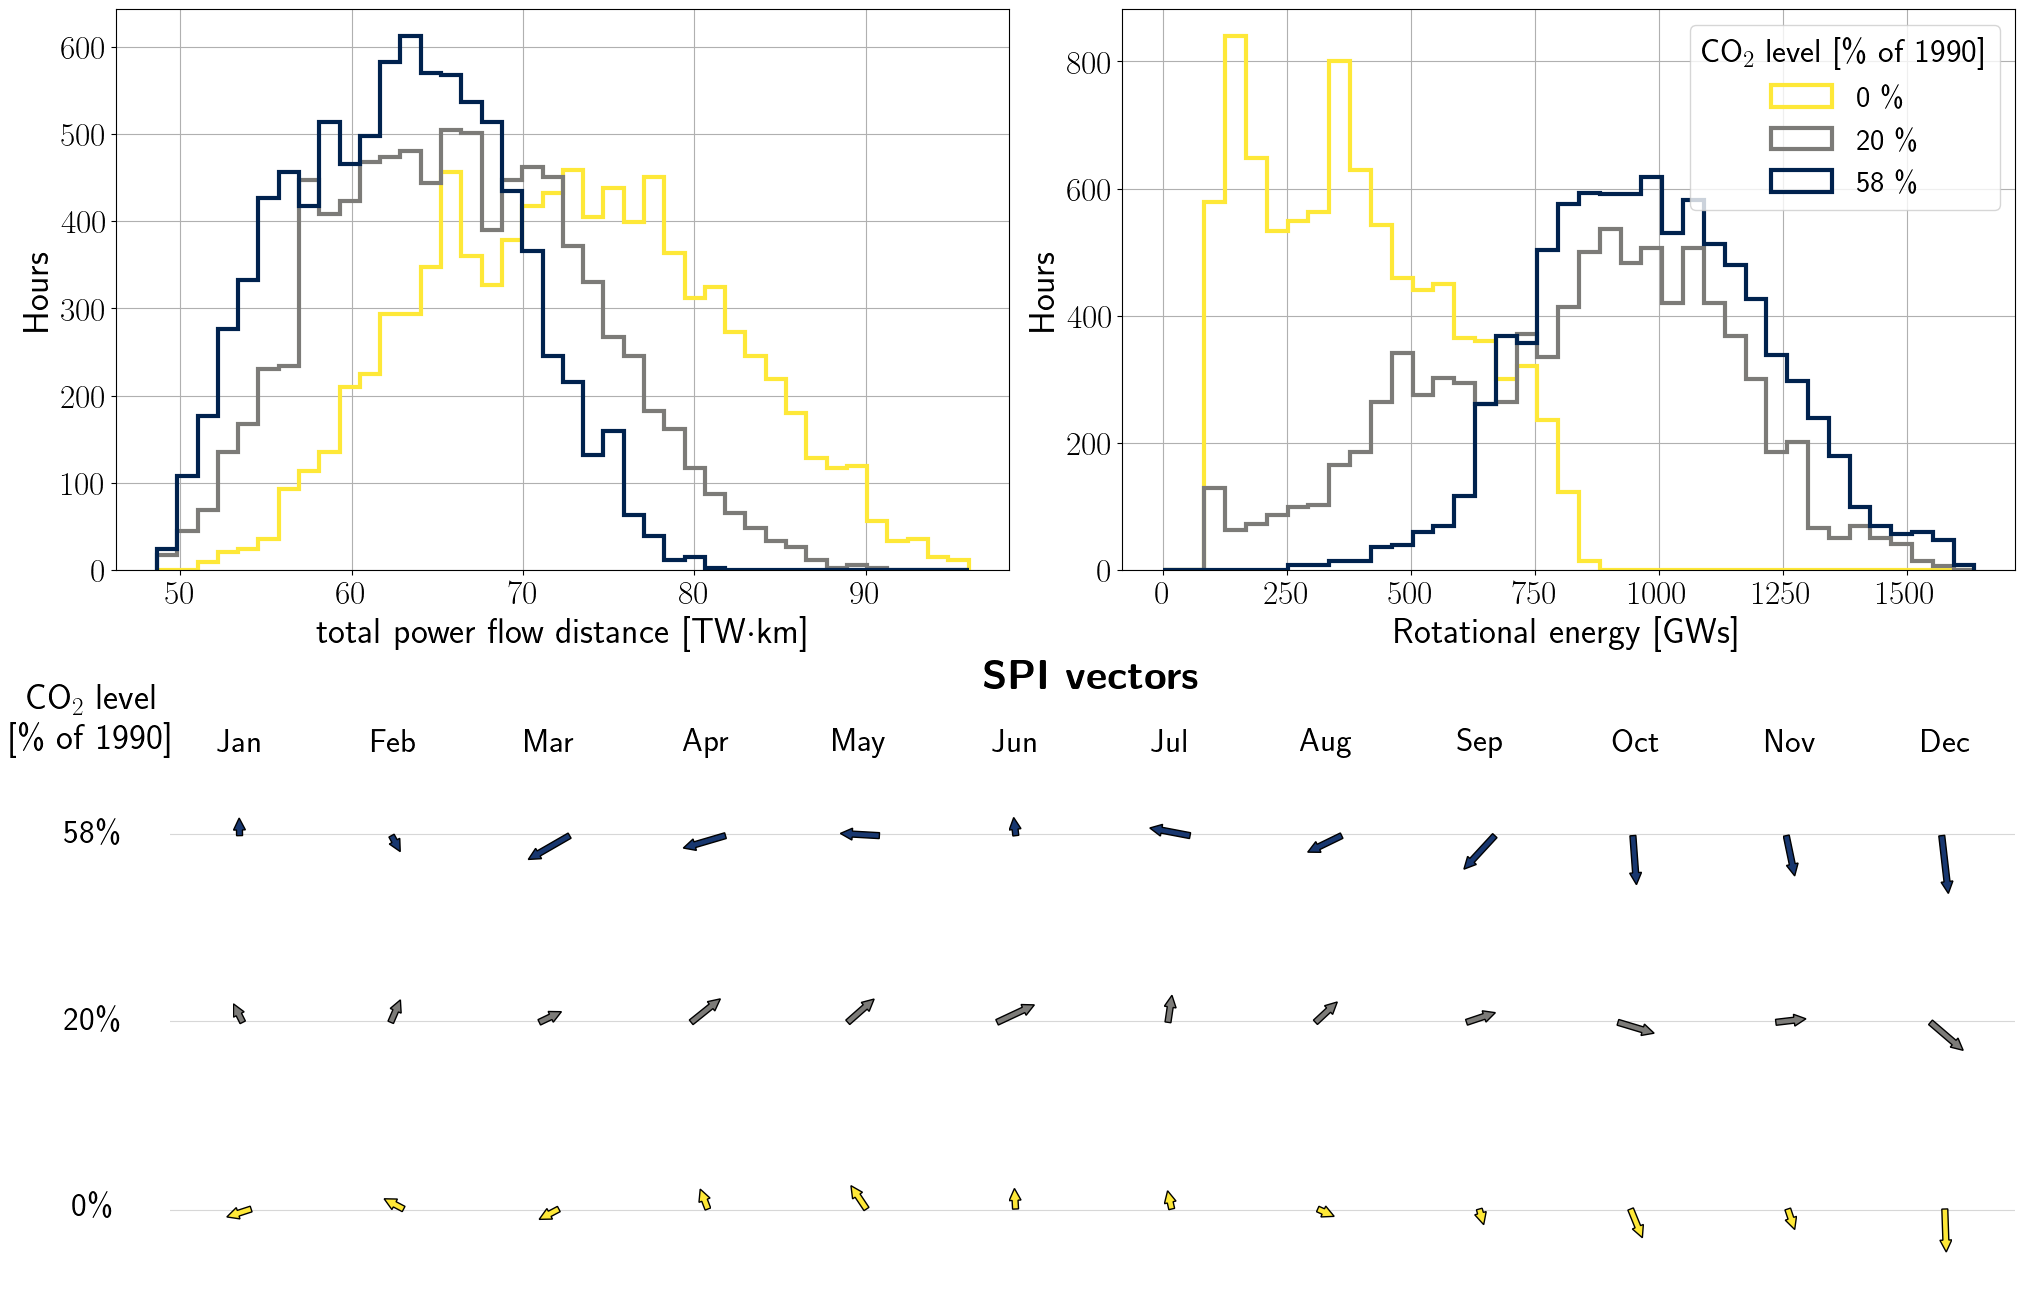

In [69]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
labels = [[r'\textbf{a}', r'\textbf{b}'], [
    r'\textbf{c}', r'\textbf{d}', r'\textbf{e}', r'\textbf{f}']]

f = plt.figure(figsize=(20, 13), constrained_layout=True)
gs_vertical= GridSpec(2,1, figure=f, hspace=0.8, height_ratios=[1,1]) # outer grid
gs_horizontal_hists = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_vertical[0])
ax_flow = f.add_subplot(gs_horizontal_hists[0])
ax_inertia = f.add_subplot(gs_horizontal_hists[1])
# axs_hist_legend = f.add_subplot(gs_horizontal_hists[2])

position_vector = np.array([pos[n] for n in nx_graph.nodes()])
mean_pos = [np.mean(position_vector[:, 0]), np.mean(position_vector[:, 1])]

gs_vectors = GridSpecFromSubplotSpec(3, 13, subplot_spec=gs_vertical[1], hspace=-0.6, )
ax_vectors_lvls = [f.add_subplot(gs_vectors[i, 0]) for i in range(3)]
for ax in ax_vectors_lvls:
    ax.axis('off')

gs_vecs_all = [[f.add_subplot(gs_vectors[j, i+1], projection=ccrs.PlateCarree())
       for i in range(12)] for j in range(3)]
gs_vecs_all = np.array(gs_vecs_all)
for ax in gs_vecs_all.flatten():
    ax.axis('off')
    ax.set_aspect('equal')

scale_factor_spi = 2e4

################# panel a: total flow histograms ####################

# calculate line flows
cmap = plt.get_cmap('cividis_r')

unit_factor = 1e6

bins = np.arange(0, 1.02, 0.02)


hist_vals = np.zeros((len(selected_co2ls), len(bins)-1))



flows_lvls = []
for count, co2l in enumerate(selected_co2ls):

   
    n = networks[co2l]

    indices = nx.get_edge_attributes(nx_graph, 'line_index')

    # flows = n.lines_t.p0.abs().sum(axis=1)
    # distances = n.lines.length
    flow_distance = n.lines_t.p0.abs().mul(network.lines.length)/unit_factor
    # flows.hist(ax=axs_probs, bins=10, alpha=0.5, color=cmap(ind/len(co2ls), 0.8), label=r'{}\%'.format(int(100*co2l)))
    flows_lvls.append(flow_distance.sum(axis=1))

bins=np.histogram(np.hstack(flows_lvls), bins=40)[1]

mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

for count, co2l in enumerate(selected_co2ls):

    ind = np.where(np.round(co2ls, 2) == co2l)[0][0]

    ax_flow.hist(flows_lvls[count],
            weights=network.snapshot_weightings.generators,
            bins=bins,
            histtype='step',
            label=r'{}\%'.format(int(round(100*co2l))),
            # density=True,
            linewidth=3,
            color=cmap(np.where(selected_co2ls == co2l)[0][0]/(len(selected_co2ls)-1)),
            alpha=1)
    
# ax_flow.legend(fontsize=16, title='CO$_2$ level [\% of 1990]')
ax_flow.tick_params(axis='both', which='both', labelsize=24)
ax_flow.set_xlabel(r'total power flow distance [TW$\cdot$km]', fontsize=26)
ax_flow.set_ylabel(r'Hours', fontsize=26)
ax_flow.grid(True)



################### panel b: rotational energy ####################


inertia_time = np.load(path_to_pre_outage_sclopf +
                       f'inertia_time_series_all_co2ls_{n_nodes}.npy')/1000
bins = np.linspace(0, inertia_time.max(), 40)

for count, co2l in enumerate(selected_co2ls):

    ind = np.where(np.round(co2ls, 2) == co2l)[0][0]

    # ax.hist(np.repeat(inertia_time[ind], network.snapshot_weightings.generators)/1000,
    ax_inertia.hist(inertia_time[ind],
            weights=network.snapshot_weightings.generators,
            bins=bins,
            histtype='step',
            label=r'{} \%'.format(int(round(get_actual_co2_level(co2l)*100))),
            linewidth=3,
            color=cmap(np.where(selected_co2ls == co2l)[0][0]/(len(selected_co2ls)-1)),
            alpha=1)
# ax_inertia.xaxis.offsetText.set_fontsize(24)

leg = ax_inertia.legend(fontsize=22, title=r'CO$_2$ level [\% of 1990]')
# h, l = ax_inertia.get_legend_handles_labels()
# leg = axs_hist_legend.legend(h, l, borderaxespad=0, fontsize=20.5, title=r'CO$_2$ level [\% of 1990]')
# axs_probs_legend.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')
# axs_hist_legend.axis("off")
# leg=ax_inertia.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')

plt.setp(leg.get_title(),fontsize=24)
ax_inertia.tick_params(axis='both', which='both', labelsize=24)
ax_inertia.set_xlabel('Rotational energy [GWs]',  fontsize=26)
ax_inertia.set_ylabel('Hours', fontsize=26)
# ax_inertia.set_yscale('log')
ax_inertia.grid()
# ax_inertia.get_legend().remove()


################## panel c: SPI vectors ####################

# scale_factor_vecs = max(max(np.abs(x_vals)), max(np.abs(y_vals)))
scale_factor_vecs = 2e4
y_lims = np.array([31.707498915424157, 60.29928495567561])
# y_lims = y_lims/2
# co2lvls_spi_plot = [0.6, 0.0]
for lvl_count, current_level in enumerate(selected_co2ls):
    old_ind = 0
    for ii in range(12):

        new_ind = old_ind + \
            len(network.snapshots[network.snapshots.month == int(ii+1)])

        ind = np.where(co2ls == current_level)[0][0]

        current_vec_0 = np.median(np.repeat(dipole_vector[ind, 0, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
        current_vec_1 = np.median(np.repeat(dipole_vector[ind, 1, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
        # for mean use np.average with weights

        gs_vecs_all[lvl_count,ii].arrow(mean_pos[0],
                                        mean_pos[1],
                                        current_vec_0/scale_factor_vecs,
                                        current_vec_1/scale_factor_vecs,
                                        head_width=2.0,
                                        width=1.0,
                                        head_length=2.0,

                                        #alpha  = .8,
                                        facecolor=cmap(ind/len(co2ls)))
        
        gs_vecs_all[lvl_count,ii].set_ylim(y_lims)

        old_ind = new_ind

for ii,ax in enumerate(gs_vecs_all[0,:]):
    ax.set_title(network.snapshots[network.snapshots.month == int(ii+1)].month_name()[0][:3], fontsize=24, pad=0)
    
for ax,co2l in zip(ax_vectors_lvls[::-1],selected_co2ls):
    ax.text(0.5, 0.5, rf"{int(round(get_actual_co2_level(co2l)*100))}\%", fontsize=24, ha='center', )
ax_vectors_lvls[0].set_title('CO$_2$ level\n'+r'[\% of 1990]', fontsize=26, rotation=0, weight='bold', pad=-40)

# common grid behind spi vectors
axs_grid = f.add_subplot(gs_vectors[:,1:], zorder=-1)
for _, spine in axs_grid.spines.items():
    spine.set_visible(False)
axs_grid.tick_params(labelleft=False, labelbottom=False, bottom=False, left=False, right=False )
axs_grid.set_title(r"\textbf{SPI vectors}", fontsize=30, pad=50)

ii = 7
ticks = [
    # 0.0,
 0.16666666666666666,
 0.515,
 0.86,
 ]
axs_grid.set_yticks(ticks)
#axs_grid.set_xlim([0,12])
#axs_grid.set_xticks(np.arange(1,12)-0.2)
axs_grid.grid(axis='y', alpha=0.5)

plt.savefig(save_path+'flow_inertia_spi.pdf', bbox_inches='tight')

# Figure 7: line failures

## split likelihood

Note: These are the likelihoods for ANY split that occured, i.e., also those with only 1 or 2 nodes being split off. Should we keep it like this?

Important: When setting vmin larger then the minimum probability, then edges with likelihood below vmin appear as gray, which might be confused with a line that never leads to a blackout. So: Check vmin/vmax configuration and maybe explain in figure legend. 

In [ ]:
edge_likelihoods_primary = pickle.load(
    open(path_to_vis_results_sclopf+f'edge_likelihoods_primary_all_co2ls_n{n_nodes}.pickle', 'rb'))
edge_likelihoods_secondary = pickle.load(
    open(path_to_vis_results_sclopf+f'edge_likelihoods_secondary_all_co2ls_n{n_nodes}.pickle', 'rb'))


In [ ]:
##### setup figure #####
f = plt.figure(figsize=(21, 10))
gs_vertical = GridSpec(1, 2, figure=f, width_ratios=[3, 0.05], wspace=-0.02)
gs_maps = GridSpecFromSubplotSpec(2, 3, subplot_spec=gs_vertical[0], wspace=-0.1, hspace=-0.1)
axs_primary = [f.add_subplot(gs_maps[0, i]) for i in range(3)]
axs_secondary = [f.add_subplot(gs_maps[1, i]) for i in range(3)]
gs_colorbars = GridSpecFromSubplotSpec(5, 1, subplot_spec=gs_vertical[1], height_ratios=[0.2, 1, 0.2, 1, 0.2])
axs_colorbars = [f.add_subplot(gs_colorbars[i]) for i in [1, 3]]
# f.subplots_adjust(hspace=-0.1, wspace=0.0)
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

##### setup parameters #####
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']
vmaxvals = []
vminvals = []

#### Primary failures ######

cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
cmap.set_under('gainsboro', 1.0)

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_p = [edge_likelihoods_primary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_p_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_p])

    print('Min val prim: {:e}'.format(np.amin(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    print('Max val prim: {:e}'.format(np.amax(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    
    vmax = 1e-3
    # vmax = 10**max(c_H_p_log)
    vmin =  1e-6

    nodes = nx.draw_networkx_nodes(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                node_color='black',
                                node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                edge_color=c_H_p_log,
                                width=3.5,
                                edge_cmap=cmap,
                                edge_vmin=np.log10(vmin),
                                edge_vmax=np.log10(vmax))

    axs_primary[count].axis('off')


# cbar_ax = f.add_axes([0.9, 0.57, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=axs_colorbars[0])
cb.ax.tick_params(labelsize=26, width=1.0, which='both')
axs_colorbars[0].set_title(r'$\langle p_{\ell}^{\text{p}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)

###### Secondary failures #####

cmap = copy.copy(mpl.cm.get_cmap("viridis_r"))
cmap.set_under('gainsboro', 1.0)

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_s = [edge_likelihoods_secondary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_s_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_s])
    
    print('Min val sec: {:e}'.format(np.amin(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
    print('Max val sec: {:e}'.format(np.amax(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
    # vmax = 1e-3
    # vmax = 10**max(c_H_s_log)
    vmax = 1e-3
    vmin = 1e-5
    vmaxvals.append(vmax)
    vminvals.append(vmin)

    nodes = nx.draw_networkx_nodes(nx_graph,
                                   pos=pos,
                                   ax=axs_secondary[count],
                                   node_color='black',
                                   node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                   pos=pos,
                                   ax=axs_secondary[count],
                                   edge_color=c_H_s_log,
                                   width=3.5,
                                   edge_cmap=cmap,
                                   edge_vmin=np.log10(vmin),
                                   edge_vmax=np.log10(vmax))

    axs_secondary[count].axis('off')

    axs_primary[count].set_title(r'CO$_2 =$ ' + '{} \%'.format(int(round(co2l*100))), fontsize=28)
    axs_primary[count].text(0+0.1, 1+0.05,
                    labels[count],
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs_primary[count].transAxes)


# cbar_ax = f.add_axes([0.9, 0.19, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=axs_colorbars[1])
# cb.set_ticks([1e-5,1e-4, 1e-3, vmax], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$',r'$1.5\cdot10^{-3}$'])
cb.set_ticks([1e-5,1e-4, 1e-3], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$'])
cb.ax.tick_params(labelsize=26, width=1.0, which='major')
axs_colorbars[1].set_title(r'$\langle p_{\ell}^{\textrm{s}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)
print(np.max(vmaxvals), np.min(vminvals))


plt.savefig(save_path+'line_failure_probs.pdf',bbox_inches = 'tight')

In [ ]:
##### setup figure #####
f = plt.figure(figsize=(21, 10))
gs_vertical = GridSpec(1, 2, figure=f, width_ratios=[3, 0.05], wspace=-0.02)
gs_maps = GridSpecFromSubplotSpec(2, 3, subplot_spec=gs_vertical[0], wspace=-0.1, hspace=-0.1)
axs_primary = [f.add_subplot(gs_maps[0, i]) for i in range(3)]
axs_secondary = [f.add_subplot(gs_maps[1, i]) for i in range(3)]
gs_colorbars = GridSpecFromSubplotSpec(5, 1, subplot_spec=gs_vertical[1], height_ratios=[0.2, 1, 0.2, 1, 0.2])
axs_colorbars = [f.add_subplot(gs_colorbars[i]) for i in [1, 3]]
# f.subplots_adjust(hspace=-0.1, wspace=0.0)
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
level
##### setup parameters #####
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']
vmaxvals = []
vminvals = []

#### Primary failures ######

cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
cmap.set_under('gainsboro', 1.0)

probs_all = np.concatenate([np.array(list(edge_likelihoods_primary[level].values())) for level in selected_co2ls])
vmin = 0
vmax = probs_all.max()

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_p = [edge_likelihoods_primary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_p_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_p])

    print('Min val prim: {:e}'.format(np.amin(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    print('Max val prim: {:e}'.format(np.amax(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    
    # vmax = 1e-3
    # # vmax = 10**max(c_H_p_log)
    # vmin =  1e-6

    nodes = nx.draw_networkx_nodes(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                node_color='black',
                                node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                edge_color=c_H_p,
                                width=3.5,
                                edge_cmap=cmap,
                                edge_vmin=vmin,
                                edge_vmax=vmax)

    axs_primary[count].axis('off')


# cbar_ax = f.add_axes([0.9, 0.57, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.Normalize(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=axs_colorbars[0])
cb.ax.tick_params(labelsize=26, width=1.0, which='both')
axs_colorbars[0].set_title(r'$\langle p_{\ell}^{\text{p}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)

###### Secondary failures #####

cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
cmap.set_under('gainsboro', 1.0)

# vmax = 1e-3
# vmin = 1e-5

probs_all = np.concatenate([np.array(list(edge_likelihoods_secondary[level].values())) for level in selected_co2ls])
vmin = 0
vmax = probs_all.max()


for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_s = [edge_likelihoods_secondary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_s_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_s])
    
    print('Min val sec: {:e}'.format(np.amin(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
    print('Max val sec: {:e}'.format(np.amax(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
    # vmax = 1e-3
    # vmax = 10**max(c_H_s_log)
    # vmax = 1e-3
    # vmin = 1e-5
    # vmaxvals.append(vmax)
    # vminvals.append(vmin)

    nodes = nx.draw_networkx_nodes(nx_graph,
                                   pos=pos,
                                   ax=axs_secondary[count],
                                   node_color='black',
                                   node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                   pos=pos,
                                   ax=axs_secondary[count],
                                   edge_color=c_H_s,
                                   width=3.5,
                                   edge_cmap=cmap,
                                   edge_vmin=vmin,
                                   edge_vmax=vmax)

    axs_secondary[count].axis('off')

    axs_primary[count].set_title(r'CO$_2 =$ ' + '{} \%'.format(int(round(co2l*100))), fontsize=28)
    axs_primary[count].text(0+0.1, 1+0.05,
                    labels[count],
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs_primary[count].transAxes)


# cbar_ax = f.add_axes([0.9, 0.19, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.Normalize(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=axs_colorbars[1])
# cb.set_ticks([1e-5,1e-4, 1e-3, vmax], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$',r'$1.5\cdot10^{-3}$'])
# cb.set_ticks([1e-5,1e-4, 1e-3], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$'])
cb.ax.tick_params(labelsize=26, width=1.0, which='major')
axs_colorbars[1].set_title(r'$\langle p_{\ell}^{\textrm{s}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)
# print(np.max(vmaxvals), np.min(vminvals))


plt.savefig(save_path+'line_failure_probs_linear.pdf',bbox_inches = 'tight')

inspect ration between primary and secondary failure probabilities

In [ ]:
level = 0.0
c_H_p = np.array([edge_likelihoods_primary[level][(u, v)] for u, v in nx_graph.edges()])
c_H_s = np.array([edge_likelihoods_secondary[level][(u, v)] for u, v in nx_graph.edges()])
ratio = c_H_s/c_H_p
plt.hist(ratio)#, bins=np.logspace(-3, 3, 50))

In [ ]:
##### setup figure #####
f = plt.figure(figsize=(21, 10))
gs_vertical = GridSpec(1, 2, figure=f, width_ratios=[3, 0.05], wspace=-0.02)
gs_maps = GridSpecFromSubplotSpec(2, 3, subplot_spec=gs_vertical[0], wspace=-0.1, hspace=-0.1)
axs_primary = [f.add_subplot(gs_maps[0, i]) for i in range(3)]
# axs_secondary = [f.add_subplot(gs_maps[1, i]) for i in range(3)]
gs_colorbars = GridSpecFromSubplotSpec(5, 1, subplot_spec=gs_vertical[1], height_ratios=[0.2, 1, 0.2, 1, 0.2])
axs_colorbars = [f.add_subplot(gs_colorbars[i]) for i in [1, 3]]
# f.subplots_adjust(hspace=-0.1, wspace=0.0)
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

##### setup parameters #####
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']
vmaxvals = []
vminvals = []

#### Primary failures ######

cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
cmap.set_under('gainsboro', 1.0)

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_p = [edge_likelihoods_primary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_p_sec = [edge_likelihoods_secondary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_p = [a/b if b!=0 else 0 for a,b in zip(c_H_p_sec,c_H_p)]
    c_H_p_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_p])

    print('Min val prim: {:e}'.format(np.amin(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    print('Mac_H_p_secx val prim: {:e}'.format(np.amax(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    
    # vmax = 1e-3
    # # vmax = 10**max(c_H_p_log)
    # vmin =  1e-6
    vmax = 10**max(c_H_p_log)
    vmin =  vmax * 1e-5

    nodes = nx.draw_networkx_nodes(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                node_color='black',
                                node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                edge_color=c_H_p_log,
                                width=3.5,
                                edge_cmap=cmap,
                                edge_vmin=np.log10(vmin),
                                edge_vmax=np.log10(vmax))

    axs_primary[count].axis('off')


# cbar_ax = f.add_axes([0.9, 0.57, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=axs_colorbars[0])
cb.ax.tick_params(labelsize=26, width=1.0, which='both')
axs_colorbars[0].set_title(r'$\langle p_{\ell}^{\text{p}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)

# ###### Secondary failures #####

# cmap = copy.copy(mpl.cm.get_cmap("viridis_r"))
# cmap.set_under('gainsboro', 1.0)

# for count, co2l in enumerate(selected_co2ls[::-1]):

#     level = np.round(co2l, 2)
    
#     # Load likelihoods as dictionary and transform into array
#     c_H_s = [edge_likelihoods_secondary[level][(u, v)] for u, v in nx_graph.edges()]
#     c_H_s_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_s])
    
#     print('Min val sec: {:e}'.format(np.amin(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
#     print('Max val sec: {:e}'.format(np.amax(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
#     # vmax = 1e-3
#     # vmax = 10**max(c_H_s_log)
#     vmax = 1e-3
#     vmin = 1e-5
#     vmaxvals.append(vmax)
#     vminvals.append(vmin)

#     nodes = nx.draw_networkx_nodes(nx_graph,
#                                    pos=pos,
#                                    ax=axs_secondary[count],
#                                    node_color='black',
#                                    node_size=0)

#     edges = nx.draw_networkx_edges(nx_graph,
#                                    pos=pos,
#                                    ax=axs_secondary[count],
#                                    edge_color=c_H_s_log,
#                                    width=3.5,
#                                    edge_cmap=cmap,
#                                    edge_vmin=np.log10(vmin),
#                                    edge_vmax=np.log10(vmax))

#     axs_secondary[count].axis('off')

#     axs_primary[count].set_title(r'CO$_2 =$ ' + '{} \%'.format(int(co2l*100)), fontsize=28)
#     axs_primary[count].text(0+0.1, 1+0.05,
#                     labels[count],
#                     fontsize=30,
#                     weight='bold',
#                     verticalalignment='center',
#                     transform=axs_primary[count].transAxes)


# # cbar_ax = f.add_axes([0.9, 0.19, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
# sm = plt.cm.ScalarMappable(
#     cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
# cb = f.colorbar(sm, cax=axs_colorbars[1])
# # cb.set_ticks([1e-5,1e-4, 1e-3, vmax], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$',r'$1.5\cdot10^{-3}$'])
# cb.set_ticks([1e-5,1e-4, 1e-3], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$'])
# cb.ax.tick_params(labelsize=26, width=1.0, which='major')
# axs_colorbars[1].set_title(r'$\langle p_{\ell}^{\textrm{s}}\rangle$',
#              fontsize=25,
#              weight='bold',
#              verticalalignment='center',
#              pad=20)
# cb.ax.yaxis.set_ticks([1e-6,1e-4,1e-2,1])

# minortcs = np.arange(1,10,1)
# minortcs = np.array([minortcs*1e-7,minortcs*1e-6,minortcs*1e-5,minortcs*1e-4,minortcs*1e-3]).flatten()
# minortcs = minortcs[(minortcs>vmin) & (minortcs<vmax)]
# cb.ax.yaxis.set_ticks(minortcs, minor=True)

# print(np.max(vmaxvals), np.min(vminvals))


# plt.savefig(save_path+'fig7.pdf',bbox_inches = 'tight')

## loss of load

In [ ]:
try:
    with open(path_to_vis_results_sclopf + f'loss_by_trigger_lvls.pickle', 'rb') as f:
        loss_by_trigger_lvls = pickle.load(f)
except FileNotFoundError:
    loss_by_trigger_lvls = {}
    for co2l in selected_co2ls:
        split_props_lvl = pd.read_csv(path_to_evaluation_results_sclopf + f"split_properties_Co2L{co2l}_n{n_nodes}.csv", index_col=0)
        trigger0 = split_props_lvl.loc[:,["lost_load_share_blackout","init_failure_0"],].groupby("init_failure_0").sum()
        trigger1 = split_props_lvl.loc[:,["lost_load_share_blackout","init_failure_1"],].groupby("init_failure_1").sum()
        trigger1.rename_axis("trigger", inplace=True)
        trigger0.rename_axis("trigger", inplace=True)
        loss_by_trigger = pd.Series(index=list(range(n_lines)), data=0)
        loss_by_trigger.rename_axis("trigger", inplace=True)
        loss_by_trigger = loss_by_trigger.add(trigger0.lost_load_share_blackout, fill_value=0)
        loss_by_trigger = loss_by_trigger.add(trigger1.lost_load_share_blackout, fill_value=0)
        
        loss_by_trigger_lvls[co2l] = loss_by_trigger

    with open(path_to_vis_results_sclopf + f'loss_by_trigger_lvls.pickle', 'wb') as f:
        pickle.dump(loss_by_trigger_lvls, f, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
##### setup figure #####
f = plt.figure(figsize=(21, 7.05))
gs_vertical = GridSpec(1, 3, figure=f, width_ratios=[1,1,1], wspace=-0.02)
axs_primary = [f.add_subplot(gs_vertical[i]) for i in range(3)]
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

##### setup parameters #####
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']

cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
cmap.set_under("gainsboro", 1.0)

# alternative to set values have only bridges in grey
# cmap.set_under(cmap(0), 1.0)

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    loss_per_failure = loss_by_trigger_lvls[co2l].values/n_snapshots/(n_lines-1)
    loss_log_per_failure = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in loss_per_failure])
    
    # alternative to set values have only bridges in grey
    # log_min = np.log10(np.min(loss_per_failure[loss_per_failure!=0]))
    # loss_log_per_failure = np.array([np.log10(x) if x > log_min else -np.inf for x in loss_per_failure])
    
    vmax = 10**max(loss_log_per_failure)
    vmin =  vmax * 1e-3

    nodes = nx.draw_networkx_nodes(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                node_color='black',
                                node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                edge_color=loss_log_per_failure,
                                width=3.5,
                                edge_cmap=cmap,
                                edge_vmin=np.log10(vmin),
                                edge_vmax=np.log10(vmax))

    axs_primary[count].axis('off')

    axs_primary[count].set_title(r'CO$_2 =$ ' + '{} \%'.format(int(co2l*100)), fontsize=28, y=0.95)
    axs_primary[count].text(0+0.1, 1,
                    labels[count],
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs_primary[count].transAxes)

sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
# add colorbar axis
axs_colorbars = [f.add_axes([0.9, 0.3, 0.01, 0.4])]
cb = f.colorbar(sm, cax=axs_colorbars[0])
cb.ax.tick_params(labelsize=26, width=1.0, which='both')
axs_colorbars[0].set_title(
                        #    r'$\langle L_{\ell}\rangle$',
                           r'$\langle R_{\ell}^{\text{p}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)
# plt.tight_layout()
plt.savefig(save_path+'loss_by_trigger_map.pdf',bbox_inches = 'tight')

In [ ]:
##### setup figure #####
f = plt.figure(figsize=(21, 7.05))
gs_vertical = GridSpec(1, 3, figure=f, width_ratios=[1,1,1], wspace=-0.02)
axs_primary = [f.add_subplot(gs_vertical[i]) for i in range(3)]
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

##### setup parameters #####
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']

cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
cmap.set_under("gainsboro", 1.0)

# alternative to set values have only bridges in grey
# cmap.set_under(cmap(0), 1.0)

probs_all = np.concatenate([np.array(loss_by_trigger_lvls[co2l].values/n_snapshots/(n_lines-1)) for level in selected_co2ls])
vmin = 0
vmax = probs_all.max()

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    loss_per_failure = loss_by_trigger_lvls[co2l].values/n_snapshots/(n_lines-1)
    # loss_log_per_failure = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in loss_per_failure])
    
    # alternative to set values have only bridges in grey
    # log_min = np.log10(np.min(loss_per_failure[loss_per_failure!=0]))
    # loss_log_per_failure = np.array([np.log10(x) if x > log_min else -np.inf for x in loss_per_failure])
    
    # vmax = 10**max(loss_log_per_failure)
    # vmin =  vmax * 1e-3

    nodes = nx.draw_networkx_nodes(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                node_color='black',
                                node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                edge_color=loss_per_failure,
                                width=3.5,
                                edge_cmap=cmap,
                                edge_vmin=vmin,
                                edge_vmax=vmax)

    axs_primary[count].axis('off')

    axs_primary[count].set_title(r'CO$_2 =$ ' + '{} \%'.format(int(co2l*100)), fontsize=28, y=0.95)
    axs_primary[count].text(0+0.1, 1,
                    labels[count],
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs_primary[count].transAxes)

sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.Normalize(vmin=vmin, vmax=vmax))
# add colorbar axis
axs_colorbars = [f.add_axes([0.9, 0.3, 0.01, 0.4])]
cb = f.colorbar(sm, cax=axs_colorbars[0])
cb.ax.tick_params(labelsize=26, width=1.0, which='both')
axs_colorbars[0].set_title(
                           r'$\langle R_{\ell}^{\text{p}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)
# plt.tight_layout()
plt.savefig(save_path+'loss_by_trigger_map_linear.pdf',bbox_inches = 'tight')

# Nodal Blackout Prob

In [70]:
path_to_evaluation_results_sclopf + f"blackout_prob_dict_n{n_nodes}.pickle"

'/srv/data/jlange/power-system-split/no_extensions//results/sclopf/evaluation_results/blackout_prob_dict_n600.pickle'

In [71]:
try:
    
    with open(path_to_evaluation_results_sclopf + f"bflackout_prob_dict_n{n_nodes}.pickle", "rb") as out:
        blackout_prob_dict = pickle.load(out)
    with open(path_to_evaluation_results_sclopf + f"edge_failure_prob_dict_n{n_nodes}.pickle", "rb") as out:
        edge_failure_prob_dict = pickle.load(out)
        
except FileNotFoundError:
    blackout_prob_dict = {}
    edge_failure_prob_dict = {}
    vmin_node = 1
    vmax_node = 0
    for target_level in selected_co2ls:
        print(target_level)
        
        path = (
                path_to_evaluation_results_sclopf
                + f"/indicator_vector_rocof_Co2L{target_level}_n{n_nodes}.pklz"
        )
        with gzip.open(path, "rb") as out:
            rocof_indicator_vectors = pickle.load(out)[-1]
        path = (
                path_to_evaluation_results_sclopf
                + f"/failed_edges_indicator_vector_Co2L{target_level}_n{n_nodes}.pklz"
        )
        with gzip.open(path, "rb") as out:
            failed_edges_indicator_vectors = pickle.load(out)[-1]

        weights = split_properties[split_properties.co2l==target_level].snapshot_weighting.values
        print(weights.shape, rocof_indicator_vectors.shape, failed_edges_indicator_vectors.shape)
        blackout_prob_dict[target_level] = (weights.reshape(1,-1) @  (rocof_indicator_vectors<-1)).squeeze()/num_failures_weighted
        
        edge_failure_prob_dict[target_level] = (weights.reshape(1,-1) @  failed_edges_indicator_vectors).squeeze()/num_failures_weighted
        
    with open(path_to_evaluation_results_sclopf + f"blackout_prob_dict_n{n_nodes}.pickle", "wb") as out:
        pickle.dump(blackout_prob_dict, out)
    with open(path_to_evaluation_results_sclopf + f"edge_failure_prob_dict_n{n_nodes}.pickle", "wb") as out:
        pickle.dump(edge_failure_prob_dict, out)


0.0
(4709980,) (4709980, 456) (4709980, 815)
0.2
(2801626,) (2801626, 456) (2801626, 815)
0.6
(1799795,) (1799795, 456) (1799795, 815)


In [ ]:
path = (
        path_to_indicator_vectors_sclopf
        + f"/indicator_vector_rocof_Co2L{0.0}_n{400}.pklz"
)
with gzip.open(path, "rb") as out:
    rocof_indicator_vectors = pickle.load(out)[-1]

NameError: name 'path_to_indicator_vectors_sclopf' is not defined

level: 0.6
0.00021792993068726625
4.5446175699881095e-07
level: 0.2
0.00021852405630129408
2.2774076242189183e-05
level: 0.0
0.0004344432708246682
0.00021695339213137385


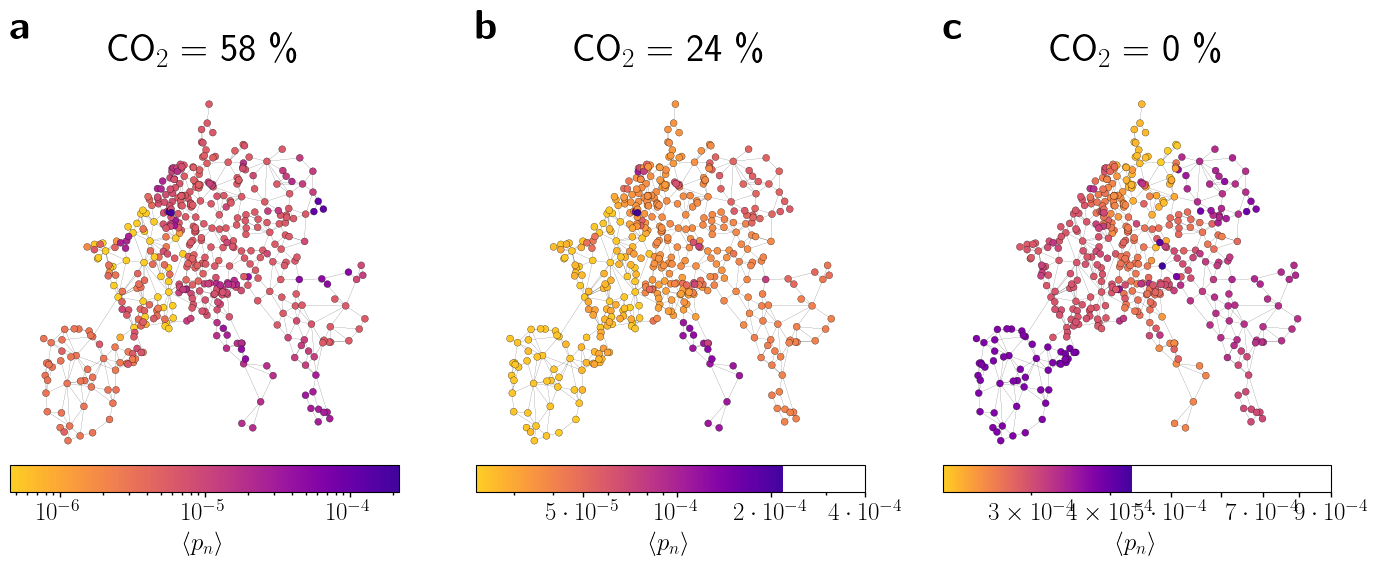

In [ ]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

f = plt.figure(figsize=(15.5*1.1, 5*1.1))

gs_maps = GridSpec(1, len(selected_co2ls), figure=f)
gs_lvls = []
for i, target_level in enumerate(selected_co2ls):
    gs_lvl = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_maps[0, i], height_ratios=[15, 1], hspace=-0.05)
    gs_lvls.append(gs_lvl)

labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']

node_cmap = plt.get_cmap('plasma_r')
node_cmap = truncate_colormap(node_cmap, 0.1, 0.9, 1000)
node_cmap.set_under('gainsboro', 1.0)
node_cbar_label="blackout prob"

# vmax_node = -np.inf
# vmin_node = np.inf
# vmaxes = []

# for i,(gs_lvl,target_level) in enumerate(zip(gs_lvls,selected_co2ls[::-1])):
    
#     ax = f.add_subplot(gs_lvl[0])
#     ax_cbar = f.add_subplot(gs_lvl[1])

#     blackout_prob = blackout_prob_dict[target_level]
#     edge_failure_prob = edge_failure_prob_dict[target_level]
    
#     blackout_prob_log = np.array(
#         [np.log10(x) if x > 1e-12 else -np.inf for x in blackout_prob]
#     )
#     # vmax_node = blackout_prob.max()
#     # vmin_node = blackout_prob.min()
#     vmax_node = max(10**blackout_prob_log.max(), vmax_node)
#     vmin_node = min(10**blackout_prob_log.min(), vmin_node)
    
#     vmaxes.append(vmax_node)
#     # vmin_node = 10**blackout_prob_log.min()

# vmin_node = vmaxes[0]*1e-3

# vmin_node = 1e-4

for i,(gs_lvl,target_level) in enumerate(zip(gs_lvls,selected_co2ls[::-1])):
    
    ax = f.add_subplot(gs_lvl[0])
    ax_cbar = f.add_subplot(gs_lvl[1])

    blackout_prob = blackout_prob_dict[target_level]
    edge_failure_prob = edge_failure_prob_dict[target_level]
    
    blackout_prob_log = np.array(
        [np.log10(x) if x > 1e-12 else -np.inf for x in blackout_prob]
    )
    # vmax_node = blackout_prob.max()
    # vmin_node = blackout_prob.min()
    vmax_node = 10**blackout_prob_log.max()
    vmin_node = 10**blackout_prob_log.min()

    # vmin_node = vmax * 10e-1
    print(f"level: {target_level}")
    print(vmax_node)
    print(vmin_node)
    # vmax_node = 10e-1
    # vmin_node = 10e-8

    nodes = nx.draw_networkx_nodes(
        nx_graph,
        pos=pos,
        ax=ax,
        node_size=25,
        node_color=blackout_prob_log,
        cmap=node_cmap,
        vmax=np.log10(vmax_node),
        vmin=np.log10(vmin_node),

    )
    nodes.set_edgecolor("black")
    nodes.set_linewidth(0.2)

    edges = nx.draw_networkx_edges(
        nx_graph,
        pos=pos,
        ax=ax,
        width=0.1,
        edge_color="black",
    )
    
    ax.set_title(r'CO$_2 =$ ' + '{} \%'.format(int(get_actual_co2_level(target_level)*100)), fontsize=28)
    ax.text(0, 1+0.1,
                    labels[i],
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=ax.transAxes)
    
    # ax.set_title(f"CO2={int(target_level*100)}%", fontsize=24)
    ax.axis("off")

    sm = plt.cm.ScalarMappable(
        cmap=node_cmap, norm=mplcolors.LogNorm(vmin=vmin_node, vmax=vmax_node))
    cb = f.colorbar(sm, cax=ax_cbar, orientation="horizontal")
    if target_level==0.0:
        # ticks = ax_cbar.get_xticks()
        # ax_cbar.set_xticks(ticks, labels=["" for i in range(len(ticks))])
        # ax_cbar.set_xticks([i*1e-4 for i in range(5,10)], labels=["$5\cdot 10^{-4}$", "$6\cdot10^{-4}$","$7\cdot 10^{-4}$","$8\cdot 10^{-4}$", "$9\cdot 10^{-4}$"])
        ax_cbar.set_xticks([i*1e-4 for i in range(5,10)], labels=["$5\cdot 10^{-4}$", "","$7\cdot 10^{-4}$","", "$9\cdot 10^{-4}$"])
    elif target_level==0.2:
        ax_cbar.set_xticks([5e-5,1e-4,2e-4,4e-4], labels=["$5\cdot 10^{-5}$", "$10^{-4}$","$2\cdot 10^{-4}$","$4\cdot 10^{-4}$"])
    ax_cbar.set_xlabel(r'$\langle p_{n}\rangle$', fontsize=18, labelpad=5)
    ax_cbar.tick_params(labelsize=18, width=1.0, which='both')


f.savefig(save_path+'nodal_blackout_prob.pdf',bbox_inches = 'tight')

# Figure 5: split statistics

In [ ]:
# co2ls = np.arange(0.1,0.81,0.1).round(1)
# selected_co2ls = np.array([0.1, 0.3, 0.6, 0.8])

# Load split component properties
component_props = pd.read_hdf(path_to_vis_results_sclopf + f'component_properties_all_n{n_nodes}.h5')
component_props.time_stamp = pd.to_datetime(component_props.time_stamp)
# indicator_vectors = np.load(path_to_vis_results + f'indicator_vectors_all_n400.npy').astype(bool)
split_props = split_properties
# split_vectors = np.load(path_to_vis_results + f'split_vectors_all_n400.npy')

split_props.lost_load_share_blackout = split_props.lost_load_share_blackout.astype(float)

0.6 96.64771291987574
0.5 98.90431495709187
0.4 99.50347896391402
0.3 99.5380692198787
0.2 99.5654873179431
0.1 99.88885253833715
0.0 99.93633489927221


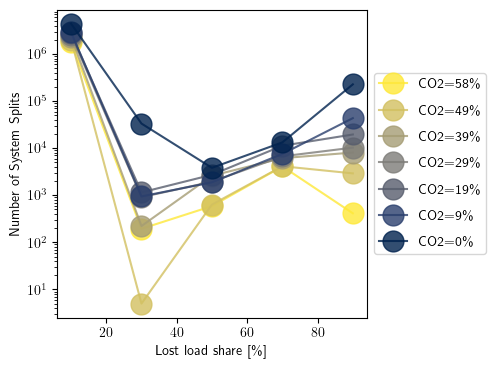

In [ ]:
fig = plt.figure(figsize=(4,4))
cmap = plt.get_cmap("cividis")

bins = np.linspace(0, 100, 6)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
for co2l in co2ls[::-1]:
    vals = split_props[split_props.co2l==co2l].lost_load_share_blackout.values*100
    actual_lvl = get_actual_co2_level(co2l)
    color = cmap(np.where(actual_co2ls == actual_lvl)[0][0] / (len(actual_co2ls) - 1))
    print(co2l, vals.max())
    counts, _ = np.histogram(vals, bins=bins)
    plt.plot(bin_centers, counts, label=rf'CO2={int(actual_lvl*100)}\%', alpha=0.8, color=color, marker=".", markersize=30)
plt.xlabel(r'Lost load share [\%]')
plt.ylabel('Number of System Splits')
plt.yscale("log")
# plt.title('Lost load share distribution for different CO2 levels')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),labelspacing=1)
plt.savefig(save_path + 'lost_load_share_hist.pdf', bbox_inches='tight')

In [ ]:
cmap = plt.get_cmap("cividis")

bins = np.linspace(0, 100, 6).astype(int)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
data = []
for co2l in co2ls[::-1]:
    vals = split_props[split_props.co2l==co2l].lost_load_share_blackout.values*100
    counts, _ = np.histogram(vals, bins=bins)
    data.append(counts)

data = np.stack(data)
data = pd.DataFrame(data, index=co2ls[::-1], columns=bin_centers)
data

,10.0,30.0,50.0,70.0,90.0
0.6,1794498,194,588,4101,414
0.5,2027699,5,634,4133,2915
0.4,2317074,222,2602,6141,8078
0.3,2597669,910,1940,6711,10272
0.2,2766952,1151,2721,11263,19539
0.1,2914914,945,1884,7542,43444
0.0,4432527,33365,3827,13292,226969


<Figure size 400x400 with 0 Axes>

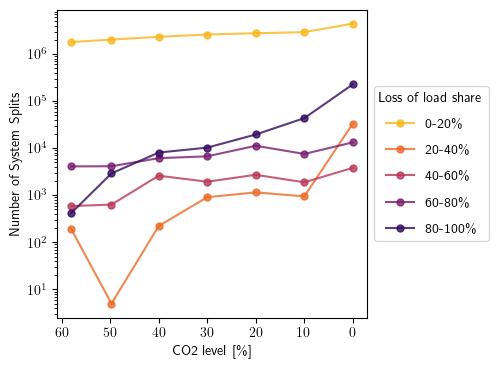

In [ ]:
fig = plt.figure(figsize=(4,4))

cmap = plt.get_cmap("inferno_r")
for i, bin_center in enumerate(bin_centers):
    actual_lvl = get_actual_co2_level(co2l)
    color = cmap(i/(len(bin_centers)+1)+(1/(len(bin_centers)+1)))
    counts = data.loc[:, bin_center]
    plt.plot(get_actual_co2_level(co2ls[::-1])*100, counts, label=rf'{bins[i]}-{bins[i+1]}\%', alpha=0.8, color=color, marker=".", markersize=10)
plt.xlabel(r'CO2 level [\%]')
plt.ylabel('Number of System Splits')
plt.yscale("log")
plt.gca().invert_xaxis()
# plt.title('Lost load share distribution for different CO2 levels')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), labelspacing=1, title='Loss of load share')
plt.savefig(save_path + 'lost_load_share_hist.pdf', bbox_inches='tight')

In [ ]:
split_props.lost_load_share_blackout = split_props.lost_load_share_blackout.astype(float)
split_props["category"] = ""
split_props.loc[split_props.lost_load_share_blackout > 0.5, "category"] = "global_blackout"
split_props.loc[(split_props.lost_load_share_blackout < 0.5) & (split_props.lost_load_share_blackout > 0.01), "category"] = "local_blackout"
split_props.loc[(split_props.lost_load_share_blackout < 0.01) & (split_props.lost_load_share_blackout > 0.0), "category"] = "negligible"
split_props.loc[split_props.lost_load_share_blackout == 0.0, "category"] = "no_blackout"
# if ((split.rocof > -1) & (split.load_share > 0.99)).any():
#     split_props.loc[name, "category"] = "negligible"
# else:
#     split_props.loc[name, "category"] = "no_blackout"

In [ ]:
split_props.rename(columns={"neglidgeable_blackout": "negligible"}, inplace=True)

In [ ]:
#TODO: remove this when all splits were evaluated!!!
# Restricting analysis to minimum of available time steps

# n_steps_to_consider = component_props.groupby('co2l').apply(lambda x:x.time_stamp.unique().shape[0]).min()
# number_of_simulations = n_steps_to_consider*len(n_2_failures)
# component_props = component_props[pd.to_datetime(component_props.time_stamp)<network.snapshots[n_steps_to_consider]]
component_props["snapshot_weighting"] = network.snapshot_weightings.generators[component_props.time_stamp].values
# indicator_vectors = indicator_vectors[:component_props.shape[0]]

# split_props = split_props[pd.to_datetime(split_props.index.get_level_values('time_stamp'))<network.snapshots[n_steps_to_consider]]
# split_vectors = split_vectors[:split_props.shape[0]]

# n_steps_to_consider


# split_props["snapshot_weighting"] = network.snapshot_weightings.generators[split_props.index.get_level_values(1)].values
weighted_split_props_dict = dict({co2l:{category: split_props.loc[(split_props.category==category) & (split_props.index.get_level_values(0)==co2l), "snapshot_weighting"].sum() for category in split_props.category.unique()} for co2l in co2ls})
# for index,row in split_props.iterrows():
#         weighted_split_props_dict[index[0]][row.category] += row.snapshot_weighting

* **negligible**: there is a component with with >99% load that survives
* **relevant split without blackout/ Non-severe**: Not negligible and not blackout.
* **locally severe/ local blackout**: blackout of <99% of CE load
* **globally severe/ global blackout**: Blackout of >99% of CE load.




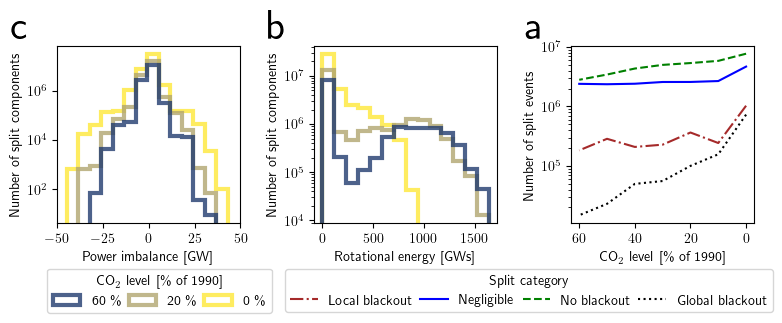

In [ ]:
from cycler import cycler
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

fig = plt.figure(figsize=(9, 3.3))
gs_vertical = GridSpec(2, 1, figure=fig, hspace=0.6, height_ratios=[1,0.1])


# Panel c: split number and categories
n_cols = 3
gsTop = GridSpecFromSubplotSpec(1, n_cols, subplot_spec=gs_vertical[0,:], hspace=0, wspace=0.4)
gs_bottom = GridSpecFromSubplotSpec(1, n_cols, subplot_spec=gs_vertical[1,:])
ax1 = fig.add_subplot(gsTop[2])
ax1_legend = fig.add_subplot(gs_bottom[1:])

data0 = pd.DataFrame(weighted_split_props_dict).transpose()

data0 = data0.rename(columns={'global_blackout':'Global blackout','local_blackout':'Local blackout',
                            'no_blackout':'No blackout','negligible':'Negligible'})
# data0 = data0.rename(columns={'global_blackout':'Globally severe','local_blackout':'Locally severe',
#                             'no_blackout':'Non-severe','negligible':'Negligible'})

# data0 = data0.rename(str.upper().replace("_", " "))
data0 = data0.iloc[:, ::-1]

N = data0.shape[1]
# cc = plt.cycler("color", plt.cm.copper_r(np.linspace(0,1,N)))
cc = ["g", "blue", "brown", "black"]
color_dict = {"No blackout":"g", "Negligible":"blue", "Local blackout":"brown", "Global blackout":"black"}
style_dict = {"No blackout":":", "Negligible":"--", "Local blackout":"-.", "Global blackout":"-"}

linestyle_cycler = [':','--','-','-.']

for d, style, col in zip(cc, linestyle_cycler, data0.columns):
    data_series = data0[col]
    data_series[data_series==0.0] = np.nan
    data_series = data0[col].dropna()
    color = color_dict[col]
    ax1.plot(data_series.index*100, data_series.values, color=color, label=col, linestyle=style)
    # ax1.plot(data_series.index*100, data_series.values, color=d["color"], label=col)

ax1.set_yscale('log')
ax1.set_xlabel(r'CO$_2$ level [\% of 1990]')
ax1.set_ylabel('Number of split events')
ax1.invert_xaxis()

# Legend
# fig.tight_layout()
h, l = ax1.get_legend_handles_labels()
# ax1.get_legend().remove()
ax1_legend.legend(h[::-1], l[::-1], title='Split category', loc='center', ncols=4, columnspacing=0.5)
ax1_legend.axis("off")
# ax1.get_legend().remove()

# filter out very small components
# component_props_filtered = component_props[component_props.load_share>1/200]
component_props_filtered = component_props

# Panel b: Inertia histograms
cmap = plt.get_cmap('cividis_r')

ax2 = fig.add_subplot(gsTop[1])
ax2_legend = fig.add_subplot(gs_bottom[0])
rot_energy = component_props_filtered.rot_energy/1000
bins = np.linspace(rot_energy.min(),rot_energy.max(),15)
intertia_hist_vals = []
for co2l in selected_co2ls:
    vals = ax2.hist(rot_energy[component_props_filtered.co2l==co2l],
            weights=component_props_filtered.snapshot_weighting[component_props_filtered.co2l==co2l],
            bins=bins,
            histtype='step',
            label=r'{} \%'.format(int(100*co2l)),
            linewidth=3,
            color=cmap(np.where(co2ls == co2l)[0][0]/len(co2ls)),
            alpha=0.8,
            density=False)
    intertia_hist_vals.append(vals[0])
ax2.set_yscale('log')
ax2.set_xlabel('Rotational energy [GWs]')
ax2.set_ylabel('Number of split components')

# Panel a: power imbalance histograms

ax3 = fig.add_subplot(gsTop[0])
power_imbalance = component_props_filtered.power_imbalance/1000
bins = np.linspace(power_imbalance.min(),power_imbalance.max(),15)
chandles = []
for co2l in selected_co2ls:
    h= ax3.hist(power_imbalance[component_props_filtered.co2l==co2l],
            weights=component_props_filtered.snapshot_weighting[component_props_filtered.co2l==co2l],
            bins=bins,
            histtype='step',
            linewidth=3,
            label=r'{} \%'.format(int(100*co2l)),
            color=cmap(np.where(co2ls == co2l)[0][0]/len(co2ls)),
            alpha=0.8,
            density=False)
ax3.set_yscale('log')
ax3.set_ylabel('Number of split components')
ax3.set_xlabel('Power imbalance [GW]')
ax3.set_xticks(np.arange(-50,51,step=25))


# h, l = ax4.get_legend_handles_labels()
h, l = ax2.get_legend_handles_labels()
# ax1.get_legend().remove()
ax2_legend.legend(h[::-1], l[::-1], title=r'CO$_2$ level [\% of 1990]', loc='center', ncols=3, columnspacing=0.5)
ax2_legend.axis("off")
# ax2.legend(bbox_to_anchor=(1,-0.35), ncols=4, title=r'CO$_2$ level [\% of 1990]')

# add title to subplots
# for ax,label in zip([ax1, ax2, ax3, ax4], ['a', 'b', 'c','d']):
for ax,label in zip([ax1, ax2, ax3], ['a', 'b', 'c']):
    # ax.set_title('')
    ax.text(0 -0.25, 1+0.1,
                    label,
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=ax.transAxes)

# plt.tight_layout()
plt.savefig(save_path+'split_statistics_categories.pdf',bbox_inches = 'tight')

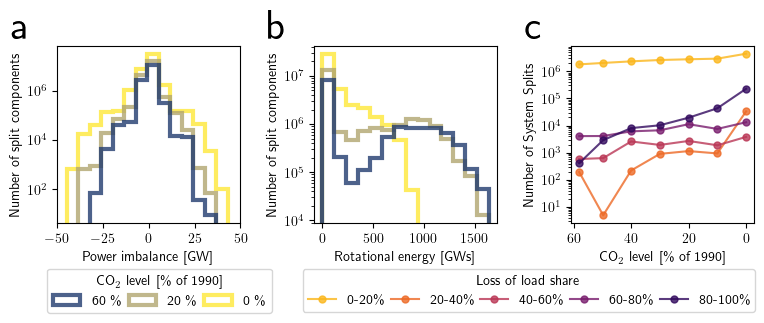

In [ ]:
from cycler import cycler
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

fig = plt.figure(figsize=(9, 3.3))
gs_vertical = GridSpec(2, 1, figure=fig, hspace=0.6, height_ratios=[1,0.1])


# Panel c: split number and categories
n_cols = 3
gsTop = GridSpecFromSubplotSpec(1, n_cols, subplot_spec=gs_vertical[0,:], hspace=0, wspace=0.4)
gs_bottom = GridSpecFromSubplotSpec(1, n_cols, subplot_spec=gs_vertical[1,:])
ax1 = fig.add_subplot(gsTop[2])
ax1_legend = fig.add_subplot(gs_bottom[1:])


cmap = plt.get_cmap("cividis")

bins = np.linspace(0, 100, 6).astype(int)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
data = []
for co2l in co2ls[::-1]:
    vals = split_props[split_props.co2l==co2l].lost_load_share_blackout.values*100
    counts, _ = np.histogram(vals, bins=bins)
    data.append(counts)

data = np.stack(data)
data = pd.DataFrame(data, index=co2ls[::-1], columns=bin_centers)

plt.sca(ax1)
cmap = plt.get_cmap("inferno_r")
for i, bin_center in enumerate(bin_centers):
    actual_lvl = get_actual_co2_level(co2l)
    color = cmap(i/(len(bin_centers)+1)+(1/(len(bin_centers)+1)))
    counts = data.loc[:, bin_center]
    plt.plot(get_actual_co2_level(co2ls[::-1])*100, counts, label=rf'{bins[i]}-{bins[i+1]}\%', alpha=0.8, color=color, marker=".", markersize=10)
plt.xlabel(r'CO$_2$ level [\% of 1990]')
plt.ylabel('Number of System Splits')
plt.yscale("log")
plt.gca().invert_xaxis()
# plt.title('Lost load share distribution for different CO2 levels')
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), labelspacing=1, title='Loss of load share')

# Legend
# fig.tight_layout()
h, l = ax1.get_legend_handles_labels()
# ax1.get_legend().remove()
ax1_legend.legend(h, l, title='Loss of load share', loc='center', ncols=len(bin_centers), columnspacing=0.5)
ax1_legend.axis("off")
# ax1.get_legend().remove()

# filter out very small components
# component_props_filtered = component_props[component_props.load_share>1/200]
component_props_filtered = component_props

# Panel b: Inertia histograms
cmap = plt.get_cmap('cividis_r')

ax2 = fig.add_subplot(gsTop[1])
ax2_legend = fig.add_subplot(gs_bottom[0])
rot_energy = component_props_filtered.rot_energy/1000
bins = np.linspace(rot_energy.min(),rot_energy.max(),15)
intertia_hist_vals = []
for co2l in selected_co2ls:
    vals = ax2.hist(rot_energy[component_props_filtered.co2l==co2l],
            weights=component_props_filtered.snapshot_weighting[component_props_filtered.co2l==co2l],
            bins=bins,
            histtype='step',
            label=r'{} \%'.format(int(100*co2l)),
            linewidth=3,
            color=cmap(np.where(co2ls == co2l)[0][0]/len(co2ls)),
            alpha=0.8,
            density=False)
    intertia_hist_vals.append(vals[0])
ax2.set_yscale('log')
ax2.set_xlabel('Rotational energy [GWs]')
ax2.set_ylabel('Number of split components')

# Panel a: power imbalance histograms

ax3 = fig.add_subplot(gsTop[0])
power_imbalance = component_props_filtered.power_imbalance/1000
bins = np.linspace(power_imbalance.min(),power_imbalance.max(),15)
chandles = []
for co2l in selected_co2ls:
    h= ax3.hist(power_imbalance[component_props_filtered.co2l==co2l],
            weights=component_props_filtered.snapshot_weighting[component_props_filtered.co2l==co2l],
            bins=bins,
            histtype='step',
            linewidth=3,
            label=r'{} \%'.format(int(100*co2l)),
            color=cmap(np.where(co2ls == co2l)[0][0]/len(co2ls)),
            alpha=0.8,
            density=False)
ax3.set_yscale('log')
ax3.set_ylabel('Number of split components')
ax3.set_xlabel('Power imbalance [GW]')
ax3.set_xticks(np.arange(-50,51,step=25))


# h, l = ax4.get_legend_handles_labels()
h, l = ax2.get_legend_handles_labels()
# ax1.get_legend().remove()
ax2_legend.legend(h[::-1], l[::-1], title=r'CO$_2$ level [\% of 1990]', loc='center', ncols=3, columnspacing=0.5)
ax2_legend.axis("off")
# ax2.legend(bbox_to_anchor=(1,-0.35), ncols=4, title=r'CO$_2$ level [\% of 1990]')

# add title to subplots
# for ax,label in zip([ax1, ax2, ax3, ax4], ['a', 'b', 'c','d']):
for ax,label in zip([ax1, ax2, ax3], ['c', 'b', 'a']):
    # ax.set_title('')
    ax.text(0 -0.25, 1+0.1,
                    label,
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=ax.transAxes)

# plt.tight_layout()
plt.savefig(save_path+'split_statistics.pdf',bbox_inches = 'tight')

# Line loading

## max load hist

In [ ]:
# calculate line flows
cmap = plt.get_cmap('cividis_r')


# bins = np.arange(0, 2.0, 0.02)
bin_width = 0.02
bins = np.arange(0, 1.02, bin_width)


hist_vals = np.zeros((len(selected_co2ls), len(bins)-1))
loadings_all = []
for i, co2l in enumerate(selected_co2ls):

    network = networks[co2l]

    indices = nx.get_edge_attributes(nx_graph, 'line_index')
    line_limits_dict = nx.get_edge_attributes(nx_graph, 's_nom')

    # line[0] because line is saved as list of length 1
    loadings = np.array([np.abs(network.lines_t.p0.T.loc[line[0]].values/line_limits_dict[nodes]) for nodes, line in indices.items()])
    print(f"Max loading for {co2l}: {loadings.max()}")
        # loadings = np.abs(
        #     n.lines_t.p0.T.loc[index_list[0]]/line_limits_dict[e])
    loadings_all.append(np.array(loadings))
    current_hist = np.histogram(loadings, bins)[0]
    hist_vals[i] += current_hist
    


Max loading for 0.0: 0.9999999999999035
Max loading for 0.2: 0.9999999999999035
Max loading for 0.6: 0.9999999999999035


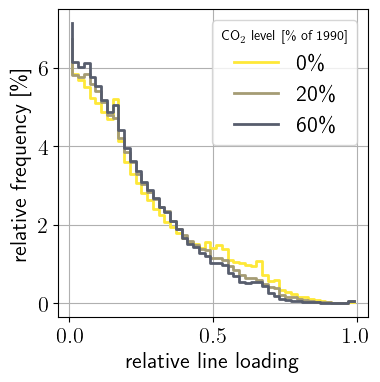

In [ ]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

xpoints = (bins + bin_width/2)[:-1]

# co2lss = np.arange(0.0, 1.0, 0.05)

f, axs_probs = plt.subplots(figsize=(4,4))

for count, co2l in enumerate(selected_co2ls):

    ind = np.where(np.round(co2ls, 2) == co2l)[0][0]

    axs_probs.step(xpoints,
            hist_vals[count]/np.sum(hist_vals[count])*100,
            label=r'{}\%'.format(int(100*co2l)),
            linewidth=2,
            color=cmap(np.where(selected_co2ls == co2l)[0][0]/len(selected_co2ls)),
            alpha=1)
axs_probs.legend(fontsize=16, title='CO$_2$ level [\% of 1990]')
#width = (bins[1]-bins[0])/2,
# label = 'data')
# axs_probs.set_xlim([0, 0.8])
axs_probs.tick_params(axis='both', which='both', labelsize=16)
axs_probs.set_xlabel(r'relative line loading', fontsize=16)
axs_probs.set_ylabel(r'relative frequency [\%]', fontsize=16)
axs_probs.grid(True)
# ax.set_yscale('log')
# ax.set_ylim([4e-3,1e-1])
# plt.savefig(save_path+'line_loadings_versus_CO2.pdf',bbox_inches = 'tight')

plt.savefig(save_path+'line_loadings_versus_CO2.pdf',bbox_inches = 'tight')
plt.show()


## total flow distance

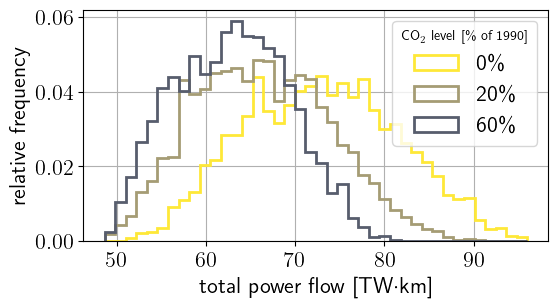

In [ ]:
# calculate line flows
cmap = plt.get_cmap('cividis_r')

unit_factor = 1e6

# bins = np.arange(0, 1.0, 0.02)


hist_vals = np.zeros((len(selected_co2ls), len(bins)-1))



flows_lvls = []
for count, co2l in enumerate(selected_co2ls):

   
    n = networks[co2l]

    indices = nx.get_edge_attributes(nx_graph, 'line_index')

    # flows = n.lines_t.p0.abs().sum(axis=1)
    # distances = n.lines.length
    flow_distance = n.lines_t.p0.abs().mul(network.lines.length)/unit_factor
    # flows.hist(ax=axs_probs, bins=10, alpha=0.5, color=cmap(ind/len(co2ls), 0.8), label=r'{}\%'.format(int(100*co2l)))
    flows_lvls.append(flow_distance.sum(axis=1))

bins=np.histogram(np.hstack(flows_lvls), bins=40)[1]

mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

f, axs_probs = plt.subplots(figsize=(6, 3))

for count, co2l in enumerate(selected_co2ls):

    ind = np.where(np.round(co2ls, 2) == co2l)[0][0]

    axs_probs.hist(flows_lvls[count], bins=bins,
            histtype='step',
            label=r'{}\%'.format(int(100*co2l)),
            density=True,
            linewidth=2,
            color=cmap(np.where(selected_co2ls == co2l)[0][0]/len(selected_co2ls)),
            alpha=1)
    
axs_probs.legend(fontsize=16, title='CO$_2$ level [\% of 1990]')
axs_probs.tick_params(axis='both', which='both', labelsize=16)
axs_probs.set_xlabel(r'total power flow [TW$\cdot$km]', fontsize=16)
axs_probs.set_ylabel(r'relative frequency', fontsize=16)
axs_probs.grid(True)
plt.savefig(save_path+'total_flow_versus_CO2.pdf',bbox_inches = 'tight')

plt.show()

## max vs total load

In [ ]:
nodes, line = list(indices.items())[0]
np.abs(network.lines_t.p0.T.loc[line[0]].values/line_limits_dict[nodes]).shape

(2920,)

In [ ]:
# calculate line flows
cmap = plt.get_cmap('cividis_r')


# bins = np.arange(0, 2.0, 0.02)
bin_width = 0.02
bins = np.arange(0, 1.02, bin_width)

d = {}
hist_vals = np.zeros((len(selected_co2ls), len(bins)-1))


for count, co2l in enumerate(selected_co2ls):

    network = data_handling.load_pypsa_network_from_path(path_to_pypsa_network_sclopf +
                        f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{co2l}-2920SEG.nc", True)

    indices = nx.get_edge_attributes(nx_graph, 'line_index')
    line_limits_dict = nx.get_edge_attributes(nx_graph, 's_nom')

    # line[0] because line is saved as list of length 1
    loadings = np.array([np.abs(network.lines_t.p0.T.loc[line[0]].values/line_limits_dict[nodes]) for nodes, line in indices.items()])
    max_load = loadings.max(axis=0)
    total_load = loadings.sum(axis=0)
    d[co2l] = pd.DataFrame({"max_loadings":max_load, "total_load":total_load})

/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.2-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.2-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


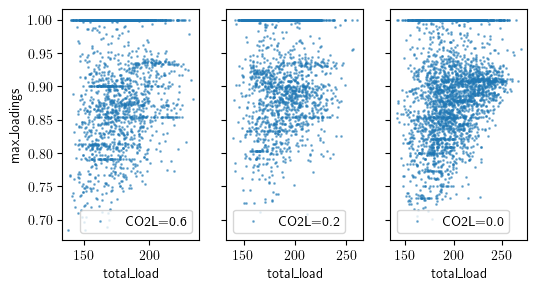

In [ ]:
f, axs = plt.subplots(figsize=(6, 3), nrows=1, ncols=len(selected_co2ls), sharey=True)
for co2l, ax in zip(sorted(selected_co2ls, reverse=True), axs):
    d[co2l].plot(kind="scatter", y='max_loadings', x='total_load', ax=ax, s=1,
            # color=cmap(np.where(co2ls == co2l)[0][0]/len(co2ls)),
            label=f'CO2L={co2l}', alpha=0.5)

/tmp/ipykernel_1122490/3895027944.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
/tmp/ipykernel_1122490/3895027944.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


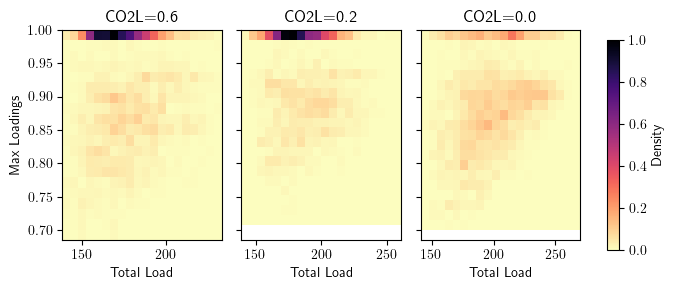

In [ ]:
f, axs = plt.subplots(figsize=(6, 3), nrows=1, ncols=len(selected_co2ls), sharey=True)
norm = plt.Normalize(vmin=0, vmax=1)  # Normalize color scale
cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cmap.set_under("gainsboro", 0)

for co2l, ax in zip(selected_co2ls, axs[::-1]):
    h = ax.hist2d(x=d[co2l].total_load, y=d[co2l].max_loadings, bins=20, cmap=cmap, norm=norm, density=True)
    ax.set_title(f'CO2L={co2l}')
    ax.set_xlabel('Total Load')
    if ax == axs[0]:
        ax.set_ylabel('Max Loadings')

# Add shared colorbar to the right of the figure
cax = f.add_axes([1.02, 0.15, 0.02, 0.7])  # Adjust position and size
cbar = f.colorbar(sm, ax=axs, orientation='vertical', shrink=0.8, pad=0.02, cax=cax)
cbar.set_label('Density')

plt.tight_layout()


# storage time

In [ ]:
types = ["discharging", "start_of_streak", "streak_id"]
n = networks[0.0]
multi_index = pd.MultiIndex.from_product([n.storage_units_t.p.columns,types], names=('units', "storage_state"))
df = pd.DataFrame(index=n.snapshots, columns=multi_index)

idx = pd.IndexSlice
df.loc[idx[:, idx[:,"discharging"]]]= (n.storage_units_t.p<0).values
df.loc[idx[:, idx[:,"start_of_streak"]]] = df.loc[idx[:, idx[:,"discharging"]]].ne(df.loc[idx[:, idx[:,"discharging"]]].shift()).values
df.loc[idx[:, idx[:,"streak_id"]]] = df.loc[idx[:, idx[:,"start_of_streak"]]].cumsum().values

In [ ]:
df_streak_id = df.loc[idx[:, idx[:,"streak_id"]]].copy()
df_streak_id.columns = df_streak_id.columns.droplevel(level=1)
id_counts = df_streak_id.apply(lambda x: x.value_counts())
storage_type_list = [col.split(" ")[-1] for col in df_streak_id.columns]
streak_lenghts = id_counts.groupby(storage_type_list, axis=1).sum()

In [ ]:
for target_level in selected_co2ls:
    n = networks[target_level].copy()
    discharging_ratios.columns = discharging_ratios.columns.droplevel(level=1)
    state_counts = discharging_ratios.apply(lambda x: x.value_counts())
    storage_type_list = [col.split(" ")[-1] for col in discharging_ratios.columns]
    discharging_ratios_types = discharging_ratios.groupby(storage_type_list, axis=1).mean().mean(axis=0)
    print(f"co2 lvl: {target_level}")
    print(discharging_ratios_types)

NameError: name 'discharging_ratios' is not defined

array([[<Axes: title={'center': 'H2'}>, <Axes: title={'center': 'PHS'}>],
       [<Axes: title={'center': 'battery'}>,
        <Axes: title={'center': 'hydro'}>]], dtype=object)

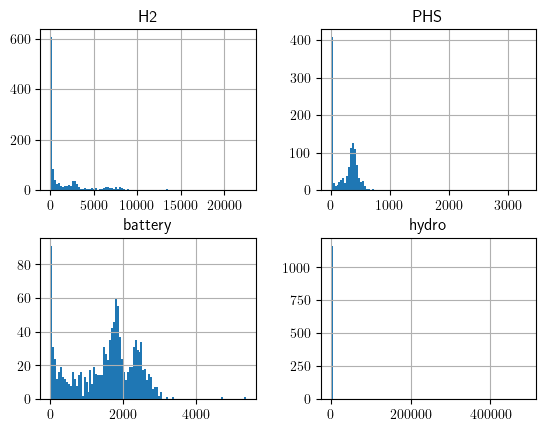

In [ ]:
streak_lenghts.hist(bins=100)

In [ ]:
# calculate line flows
cmap = plt.get_cmap('cividis_r')


bins = np.arange(0, 1.0, 0.02)


hist_vals = np.zeros((len(selected_co2ls), len(bins)-1))


storga_times_lvl = []
for count, co2l in enumerate(selected_co2ls):

   
    n = networks[co2l]

    indices = nx.get_edge_attributes(nx_graph, 'line_index')
    line_limits_dict = nx.get_edge_attributes(nx_graph, 's_nom')

    flows = n.lines_t.p0.abs().sum(axis=1)
    # flows.hist(ax=axs_probs, bins=10, alpha=0.5, color=cmap(ind/len(co2ls), 0.8), label=r'{}\%'.format(int(100*co2l)))
    storga_times_lvl.append(flows)

bins=np.histogram(np.hstack(storga_times_lvl), bins=40)[1]

# Inertia Mitigation

In [ ]:
from utils.plot_mitigation_strategies import plot_map_inertia_placement_final, calc_inertia_placement_ref_loss, color1, color2

# n_nodes = 400
# resolve_strategy = "random"
# delta_rot = 5000
# # for co2_lvl in [0.0 0.1, 0.2, 0.3, 0.4, 0.5]:
# for co2_lvl in [0.1]:
#     print(f"Running for co2_lvl: {co2_lvl}")
#     plot_map_inertia_placement_final(
#         co2_l
# vl,
#         nn=400,
#         max_iter=10000,
#         max_node_size=800,
#         edge_width=0.2,
#         delta_Erot=delta_rot,
#         resolve_strategy=resolve_strategy,
#         save_fig=True,
#     )

In [18]:
co2_lvl_ref = 0.6
inertia_needed_by_lvl = {}
ref_loss_factors = (1,2)
for ref_loss_factor in ref_loss_factors:
    inertia_at_ref_loss_by_lvl = calc_inertia_placement_ref_loss(n_nodes=600,     delta_Erot=1000, co2_lvl_ref=co2_lvl_ref, split_properties=split_properties, ref_loss_factor=ref_loss_factor, co2_lvls=co2ls)
    inertia_needed_by_lvl[ref_loss_factor] = inertia_at_ref_loss_by_lvl

/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.1-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


inertia placed in map:  325000.0
loss_ref_multiple: (2649,)
/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.1-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


inertia placed in map:  170000.0


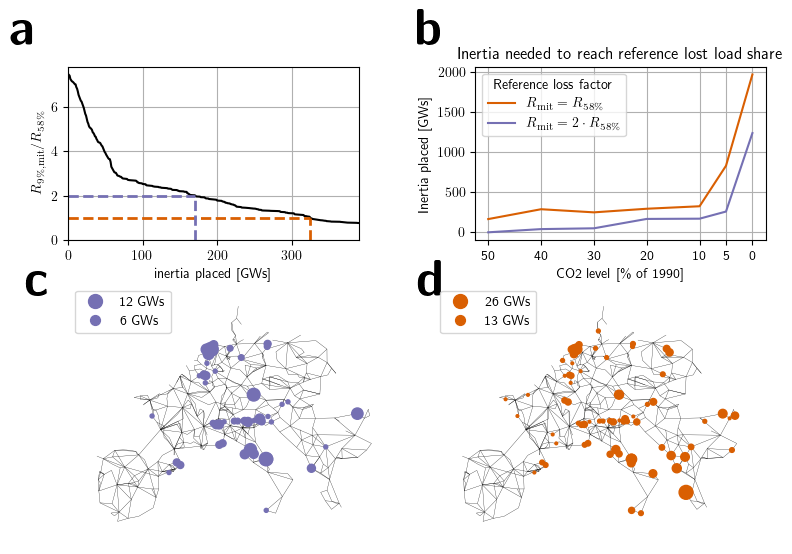

In [19]:
# f.tight_layout()
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

colors = color1, color2
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']

co2_lvl_map = 0.1

f = plt.figure(figsize=(9, 6.2))
gs_vertical = GridSpec(2, 1, figure=f, height_ratios=[1, 1.5], hspace=0.2)
gs_lines = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_vertical[0], wspace=0.4)
gs_maps = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_vertical[1], wspace=0.1)
ax_loss_reduction = f.add_subplot(gs_lines[0])
ax_inertia_needed = f.add_subplot(gs_lines[1])
axs_maps = [f.add_subplot(gs_maps[i]) for i in range(2)]

unit = "GWs"
if unit == "GWs":
    unit_factor = 1e-3
elif unit == "MWs":
    unit_factor = 1
else:
    raise ValueError(f"Unit '{unit}' not known!")

# inertia needed by lvl
for i,ref_loss_factor in enumerate(ref_loss_factors):
    inertia_at_ref_loss_by_lvl = inertia_needed_by_lvl[ref_loss_factor] 
    label = "$R_{\\textrm{mit}}=ref_loss_factor R_{\\textrm{co2refString}}$"
    # label = label.replace("co2string", str(int(100 * co2_lvl_map)) + "\%")
    label = label.replace("co2refString", str(int(100 * get_actual_co2_level(co2_lvl_ref))) + "\%")
    if ref_loss_factor != 1:
        label = label.replace("ref_loss_factor", str(ref_loss_factor)+"\cdot")
    else:
        label = label.replace("ref_loss_factor", "")
    # label = label.replace("ref_loss_factor", str(ref_loss_factor))
    ax_inertia_needed.plot(np.array(list(inertia_at_ref_loss_by_lvl.keys()))*100, np.array(list(inertia_at_ref_loss_by_lvl.values()))*unit_factor, label=label, color=colors[i])
    
# ax_inertia_needed.plot(np.array(co2ls) * 100, np.array(inertia_at_ref_loss_by_lvl) *unit_factor)
# invert x axis
ax_inertia_needed.invert_xaxis()
ax_inertia_needed.legend(title="Reference loss factor")
# plt.legend(title="$\\Delta E_0 [MWhs]$")
ax_inertia_needed.set_ylabel(f"Inertia placed [{unit}]")
ax_inertia_needed.set_xlabel("CO2 level [\% of 1990]")
ax_inertia_needed.set_title("Inertia needed to reach reference lost load share")
ticks = np.array(list(inertia_at_ref_loss_by_lvl.keys()))*100
ax_inertia_needed.set_xticks(ticks, labels=[str(int(i)) for i in ticks])
if ticks[0]<ticks[-1]:
    ax_inertia_needed.invert_xaxis()
ax_inertia_needed.grid(True)
for i, ref_loss_factor in enumerate(ref_loss_factors):
    plot_curve = i==0
    plot_map_inertia_placement_final(
        axes=(axs_maps[1-i], ax_loss_reduction),
        co2_lvl = co2_lvl_map,
        nn=600,
        max_iter=10000,
        max_node_size=100,
        edge_width=0.2,
        delta_Erot=1000,
        rocof_thres=-1,
        l_share=0.0,
        resolve_strategy="random",
        show_step_number = False,
        plot_split_number = False,
        save_fig=False,
        co2_lvl_ref = co2_lvl_ref,
        ref_loss_factor=ref_loss_factors[i],
        unit = unit,
        color=colors[i],
        plot_curve=plot_curve,
        split_properties=split_properties,
        )
    
ax_loss_reduction.set_xlim(0, inertia_needed_by_lvl[1][co2_lvl_map]*unit_factor*1.2)

# f.tight_layout()
for ax, label in zip([ax_loss_reduction, ax_inertia_needed], labels):
    ax.text(0 - 0.2, 1+0.2,
            label,
            fontsize=36,
            weight='bold',
            verticalalignment='center',
            transform=ax.transAxes)
# axs_maps[0].text( 0.5,70, rf"{int(100*get_actual_co2_level(co2_lvl_map))}\% CO$_2$ level", fontsize=19)
axs_maps[0].text(0 - 0.13, 1,
            labels[2],
            fontsize=36,
            weight='bold',
            verticalalignment='center',
            transform=axs_maps[0].transAxes)

# axs_maps[1].text(0.5,70, rf"{int(100*get_actual_co2_level(co2_lvl_map))}\% CO$_2$ level", fontsize=19)
axs_maps[1].text(0 - 0.05, 1,
            labels[3],
            fontsize=36,
            weight='bold',
            verticalalignment='center',
            transform=axs_maps[1].transAxes)
for ax in axs_maps:
    ax.legend(loc='upper left', )

# for i,ax in enumerate(axs_maps):
#     ax.title("Synthetic inertia placement")

# axs_maps[0].text(0.2, 1+0.06,
#         r'\textbf{a}',
#         fontsize=36,
#         weight='bold',
#         verticalalignment='center',
#         transform=axs_maps[0].transAxes)
# axs_maps[0].text(1 , 1+0.06,
#         r'\textbf{b}',
#         fontsize=36,
#         weight='bold',
#         verticalalignment='center',
#         transform=axs_maps[0].transAxes
#         )
# ax_map.text(1 , 0.5,
#         r'\textbf{c}',
#         fontsize=36,
#         weight='bold',
#         verticalalignment='center',
#         transform=ax_map.transAxes
#         )
    

f.savefig(save_path+f'syn_inertia_mitigation_{co2_lvl_map}.pdf',bbox_inches = 'tight')

# line extension mitigation

## inspecting induced loss by trigger line

In [59]:
co2_mitigation = 0.1
split_properties.lost_load_share_blackout = split_properties.lost_load_share_blackout.astype(float)
split_properties["co2l"] = split_properties.index.get_level_values("co2l")
split_properties_mitigation = split_properties[split_properties.co2l == co2_mitigation].copy()

trigger0 = split_properties_mitigation.loc[:,["lost_load_share_blackout","init_failure_0"],].groupby("init_failure_0").sum()
trigger1 = split_properties_mitigation.loc[:,["lost_load_share_blackout","init_failure_1"],].groupby("init_failure_1").sum()
trigger1.rename_axis("trigger", inplace=True)
trigger0.rename_axis("trigger", inplace=True)
loss_by_trigger = pd.Series(index=list(range(n_lines)), data=0)
loss_by_trigger.rename_axis("trigger", inplace=True)


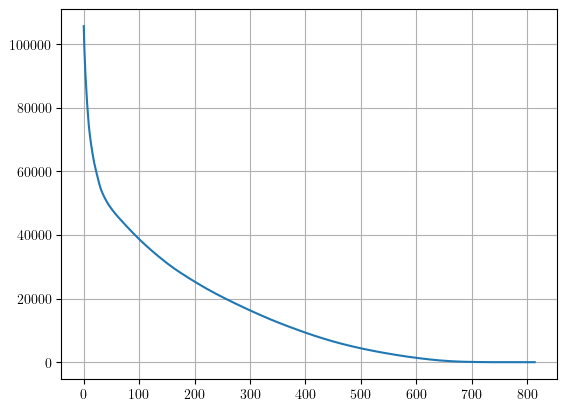

In [ ]:
loss_by_trigger = loss_by_trigger.add(trigger0.lost_load_share_blackout, fill_value=0)
loss_by_trigger = loss_by_trigger.add(trigger1.lost_load_share_blackout, fill_value=0)

loss_by_trigger_sorted = loss_by_trigger.sort_values()
loss_curve = loss_by_trigger_sorted.cumsum()
plt.plot(np.arange(len(loss_curve)),loss_curve.values[::-1])
plt.grid()

## mitigation

In [26]:
branches = networks[0.0].sub_networks["obj"][snet_index].branches()

<Axes: >

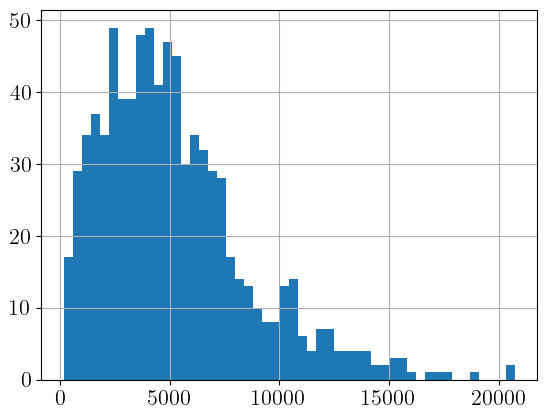

In [27]:
branches.capital_cost.hist(bins=50)

<Axes: >

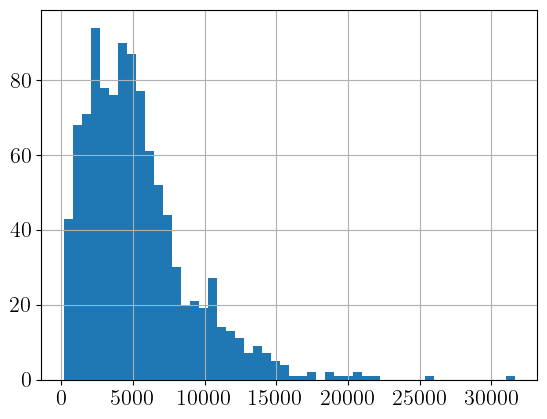

In [30]:
networks[0.0].lines.capital_cost.hist(bins=50)

/tmp/ipykernel_1122490/679201450.py:111: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
/tmp/ipykernel_1122490/679201450.py:111: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))


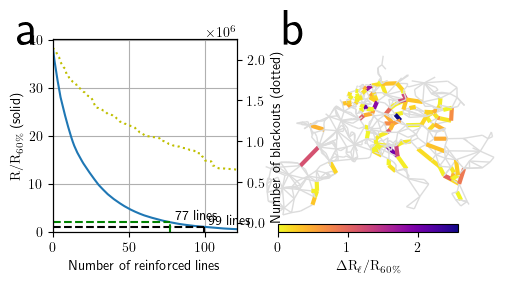

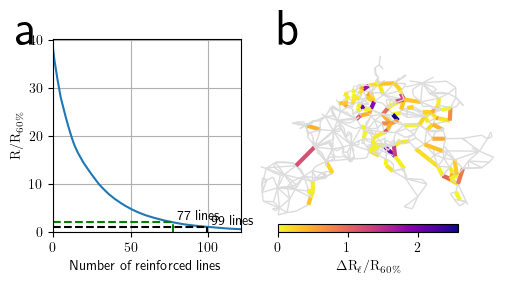

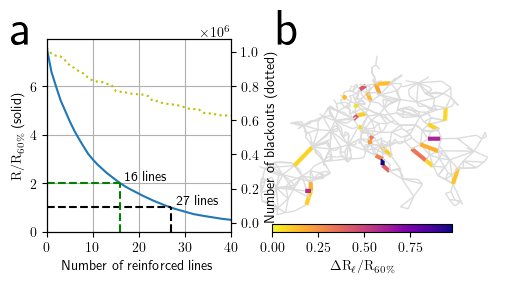

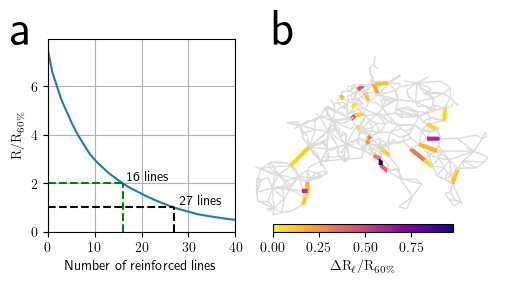

In [ ]:
from utils.config import path_to_line_extension_mitigation_sclopf

co2l_ref=0.6

split_properties_reference = split_properties[split_properties.co2l == co2l_ref].copy()

lost_load_reference_lvl = split_properties_reference.lost_load_share_blackout.sum()

for co2l in [0.0, 0.1]:
    try:
        reinforced_lines, loss_with_mitigation, num_blackouts = pickle.load(open(path_to_line_extension_mitigation_sclopf + f"heuristic_loss_mitigation_Co2L{co2l}_n{n_nodes}.pkl", "rb"))
    except FileNotFoundError:
        split_significance = pd.read_csv(path_to_vis_results_sclopf + f"split_properties_Co2L{co2l}_n{n_nodes}.csv", index_col=0)
        remaining_splits = split_significance[split_significance.lost_load_share_blackout>0]
        remaining_splits = remaining_splits.loc[:, ["lost_load_share_blackout","init_failure_0", "init_failure_1"]]

        loss_with_mitigation = [split_significance.lost_load_share_blackout.sum()]
        reinforced_lines = []
        num_blackouts = [remaining_splits.shape[0]]

        while remaining_splits.shape[0]>0:
            trigger0 = remaining_splits.loc[:,["lost_load_share_blackout","init_failure_0"],].groupby("init_failure_0").sum()
            trigger1 = remaining_splits.loc[:,["lost_load_share_blackout","init_failure_1"],].groupby("init_failure_1").sum()
            trigger1.rename_axis("trigger", inplace=True)
            trigger0.rename_axis("trigger", inplace=True)
            loss_by_trigger = pd.Series(index=list(range(n_lines)), data=0)
            loss_by_trigger.rename_axis("trigger", inplace=True)
            loss_by_trigger = loss_by_trigger.add(trigger0.lost_load_share_blackout, fill_value=0)
            loss_by_trigger = loss_by_trigger.add(trigger1.lost_load_share_blackout, fill_value=0)

            trigger = loss_by_trigger.idxmax()
            remaining_splits = remaining_splits[(remaining_splits.init_failure_1!=trigger) & (remaining_splits.init_failure_0!=trigger)]
            loss_with_mitigation.append(remaining_splits.lost_load_share_blackout.sum())
            reinforced_lines.append(trigger)
            num_blackouts.append(remaining_splits.shape[0])

        with open(path_to_line_extension_mitigation_sclopf + f"heuristic_loss_mitigation_Co2L{co2l}_n{n_nodes}.pkl", "wb") as f:
            pickle.dump((reinforced_lines, loss_with_mitigation, num_blackouts), f)
            

    # use latex
    mpl.style.use('default')
    plt.rc('text', usetex=True)
    plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

    for plot_blackout_number in [True, False]:

        num_lines_to_reach_ref_loss = np.where(loss_with_mitigation < lost_load_reference_lvl)[0][0]
        num_lines_to_reach_double_ref_loss = np.where(loss_with_mitigation < 2*lost_load_reference_lvl)[0][0]

        # fig, (ax, ax_map) = plt.subplots(1,2, figsize=(12,5))
        fig = plt.figure(figsize=(6,2.5))
        
        # gs = GridSpec(1, 2, figure=f)
        if plot_blackout_number:
            wspace=0.02
        else:
            wspace=-0.02
        gs_vertical = GridSpec(1, 2, figure=f, width_ratios=[1.2,1.8], wspace=wspace)
        ax = fig.add_subplot(gs_vertical[0])
        ax_map = fig.add_subplot(gs_vertical[1])

        ax.plot(np.arange(len(loss_with_mitigation)),np.array(loss_with_mitigation)/lost_load_reference_lvl)

        if plot_blackout_number:
            # add second y axis
            ax2 = ax.twinx()
            ax2.plot(np.arange(len(num_blackouts)),num_blackouts, color='y', linestyle='dotted')
            ax2.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
            ax2.set_ylabel('Number of blackouts (dotted)')

        right_xlim = np.where(loss_with_mitigation/lost_load_reference_lvl < 0.5)[0][0]
        ax.plot([0, num_lines_to_reach_ref_loss], [1,1], '--', c='k')
        ax.plot([num_lines_to_reach_ref_loss, num_lines_to_reach_ref_loss], [0,1], '--', c='k')
        ax.text(num_lines_to_reach_ref_loss + right_xlim/200*5, 1, f"{num_lines_to_reach_ref_loss} lines", verticalalignment='bottom', horizontalalignment='left', zorder=np.inf)
        ax.plot([0, num_lines_to_reach_double_ref_loss], [2,2], '--', c='g')
        ax.plot([num_lines_to_reach_double_ref_loss, num_lines_to_reach_double_ref_loss], [0,2], '--', c='g')
        ax.text(num_lines_to_reach_double_ref_loss + right_xlim/200*5, 2, f"{num_lines_to_reach_double_ref_loss} lines", verticalalignment='bottom', horizontalalignment='left', zorder=np.inf)
        ax.set_xlim(0,right_xlim)
        ax.set_ylim(bottom=00)

        ax.set_xlabel('Number of reinforced lines')
        # y_label = "$L_{\\textrm{co2string,mit}}/L_{\\textrm{co2refString}}$"
        # y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
        # y_label = y_label.replace("co2refString", str(int(100 * co2l_ref)) + "\%")
        y_label = "$\\textrm{R}/\\textrm{R}_{\\textrm{co2refString}}$"
        y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
        y_label = y_label.replace("co2refString", str(int(100 * co2l_ref)) + "\%")
        if plot_blackout_number:
            y_label += " (solid)"
        ax.set_ylabel(y_label)
        ax.grid()

        fname = "loss_reduction_"
        if plot_blackout_number:
            fname += "blackouts_"
        fname += f"vs_reinforced_lines_CO2{co2l}.pdf"

        reinforced_lines_selected = np.array(reinforced_lines[:num_lines_to_reach_ref_loss]).astype(int)
        lines_not_extended = np.setdiff1d(np.arange(n_lines), reinforced_lines_selected)
        reinforced_lines_full = list(reinforced_lines_selected) + list(lines_not_extended)
        mitigated_loss = np.array([loss_with_mitigation[i] - loss_with_mitigation[i+1] for i in range(len(loss_with_mitigation)-1)])
        mitigated_loss = np.concatenate((mitigated_loss,-np.ones(n_lines - len(mitigated_loss))))
        mitigated_loss_sorted = mitigated_loss[np.argsort(reinforced_lines_full)]
        mitigated_loss_selected = -np.ones(n_lines)
        mitigated_loss_selected[reinforced_lines_selected] = mitigated_loss[:num_lines_to_reach_ref_loss]/lost_load_reference_lvl

        width= 2*(mitigated_loss_selected>0).astype(int) + 1
        # cmap = "cividis_r"
        # cmap = plt.get_cmap('cividis_r')
        cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
        cmap.set_under('gainsboro', 1.0)

        nodes = nx.draw_networkx_nodes(nx_graph,
                                    pos=pos,
                                    ax=ax_map,
                                    node_color='black',
                                    node_size=0)

        edges = nx.draw_networkx_edges(nx_graph,
                                    pos=pos,
                                    ax=ax_map,
                                    # edge_color=mitigated_loss_selected/mitigated_loss_selected.max(),
                                    edge_color=mitigated_loss_selected,
                                    width=width,
                                    edge_cmap=cmap,
                                    edge_vmin=0,
                                    # edge_vmax=np.log10(vmax)
                                    )
        ax_map_legend = fig.add_axes([0.5, 0.11, 0.3, 0.03])
        # plt.colorbar(edges, ax=ax_map, cax=ax_map_legend, label='Normalized mitigated loss [a.u.]', shrink=0.5, orientation="horizontal")
        y_label = "$\Delta \\textrm{R}_{{\\ell}}/\\textrm{R}_{\\textrm{co2refString}}$"
        y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
        y_label = y_label.replace("co2refString", str(int(100 * co2l_ref)) + "\%")
        plt.colorbar(edges, ax=ax_map, cax=ax_map_legend, label=y_label, shrink=0.5, orientation="horizontal")
        ax_map.axis("off")

        ax.text(0 - 0.2, 1+0.04,
                "a",
                fontsize=36,
                weight='bold',
                verticalalignment='center',
                transform=ax.transAxes)

        ax_map.text(0 + 0.15, 1+0.04,
                "b",
                fontsize=36,
                weight='bold',
                verticalalignment='center',
                transform=ax_map.transAxes)

# plt.savefig(save_path+fname, bbox_inches='tight', dpi=200)

In [164]:
n.branches().index.get_level_values("name")

Index(['0_outage', '1_outage', '10_outage', '100_outage', '1000_outage',
       '1001_outage', '1002_outage', '1003_outage', '1004_outage',
       '1005_outage',
       ...
       'T34', 'T35', 'T36', 'T37', 'T38', 'T39', '6342', '5586+4', '14804+1',
       '14822+1'],
      dtype='object', name='name', length=1104)

In [166]:
n.branches()[n.branches().carrier=="DC"]

b  b_pu  build_year    bus0    bus1  capital_cost carrier  \
component name                                                                  
Link      14811   NaN   NaN           0  IT1 12   GR1 7  40040.795278      DC   
          5640    NaN   NaN           0   ES4 1  ES1 20  37815.046886      DC   
          13589   NaN   NaN           0   IT1 0   IT3 1  59653.075690      DC   
          14802   NaN   NaN           0  IT1 10   ME1 0  52433.675076      DC   
          14825   NaN   NaN           0  FR1 11  ES1 17  25711.633529      DC   
...                ..   ...         ...     ...     ...           ...     ...   
          T39     NaN   NaN           0   GR1 7  DE1 15  88012.361859      DC   
          6342    NaN   NaN           0   PL1 8   LT6 1  31406.632037      DC   
          5586+4  NaN   NaN           0  IT1 17   IT3 1  36903.957375      DC   
          14804+1 NaN   NaN           0   NO2 5  GB0 10  78247.107420      DC   
          14822+1 NaN   NaN           0   DK1 0   NO2 0  43229.713656      DC   

                  committable  down_time_before  efficiency  ...  \
component name                                               ...   
Link      14811         False               0.0         1.0  ...   
          5640          False               0.0         1.0  ...   
          13589         False               0.0         1.0  ...   
          14802         False               0.0         1.0  ...   
          14825         False               0.0         1.0  ...   
...                       ...               ...         ...  ...   
          T39           False               0.0         1.0  ...   
          6342          False               0.0         1.0  ...   
          5586+4        False               0.0         1.0  ...   
          14804+1       False               0.0         1.0  ...   
          14822+1       False               0.0         1.0  ...   

                   under_construction  underground underwater_fraction  \
component name                                                           
Link      14811                 False        False            0.388724   
          5640                  False        False            0.666873   
          13589                 False        False            0.855978   
          14802                  True        False            0.691381   
          14825                 False        False            0.000000   
...                               ...          ...                 ...   
          T39                    True        False            0.104276   
          6342                  False        False            0.000000   
          5586+4                False        False            0.284473   
          14804+1               False        False            0.730851   
          14822+1               False        False            0.433600   

                   up_time_before  v_ang_max  v_ang_min  v_nom   x  x_pu  \
component name                                                             
Link      14811               1.0        NaN        NaN    NaN NaN   NaN   
          5640                1.0        NaN        NaN    NaN NaN   NaN   
          13589               1.0        NaN        NaN    NaN NaN   NaN   
          14802               1.0        NaN        NaN    NaN NaN   NaN   
          14825               1.0        NaN        NaN    NaN NaN   NaN   
...                           ...        ...        ...    ...  ..   ...   
          T39                 1.0        NaN        NaN    NaN NaN   NaN   
          6342                1.0        NaN        NaN    NaN NaN   NaN   
          5586+4              1.0        NaN        NaN    NaN NaN   NaN   
          14804+1             1.0        NaN        NaN    NaN NaN   NaN   
          14822+1             1.0        NaN        NaN    NaN NaN   NaN   

                   x_pu_eff  
component name               
Link      14811         NaN  
          5640          NaN  
         

In [ ]:
n = networks[0.0]
set(n.lines.index.str.split("_").str[0].astype(int)) == set(np.arange(n.lines.shape[0]))

True

In [159]:
g = data_handling.build_networkx_graph(n, assert_order=False)

RuntimeError: There duplicated edges in the PyPSA network

/tmp/ipykernel_1301402/3911791781.py:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
/tmp/ipykernel_1301402/3911791781.py:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))


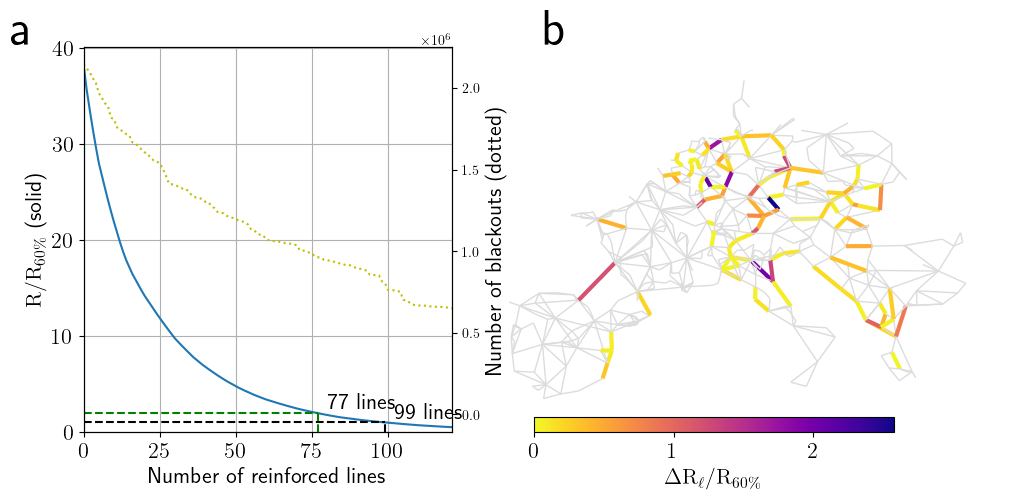

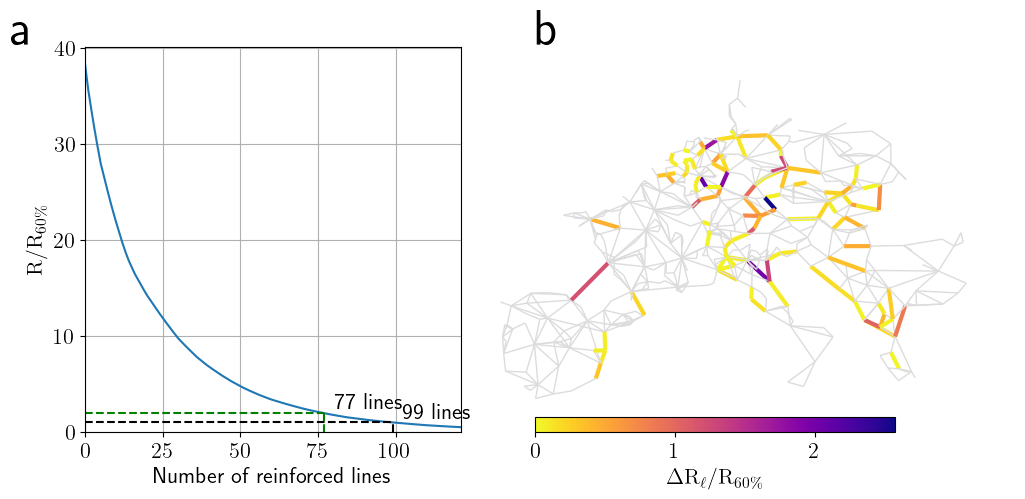

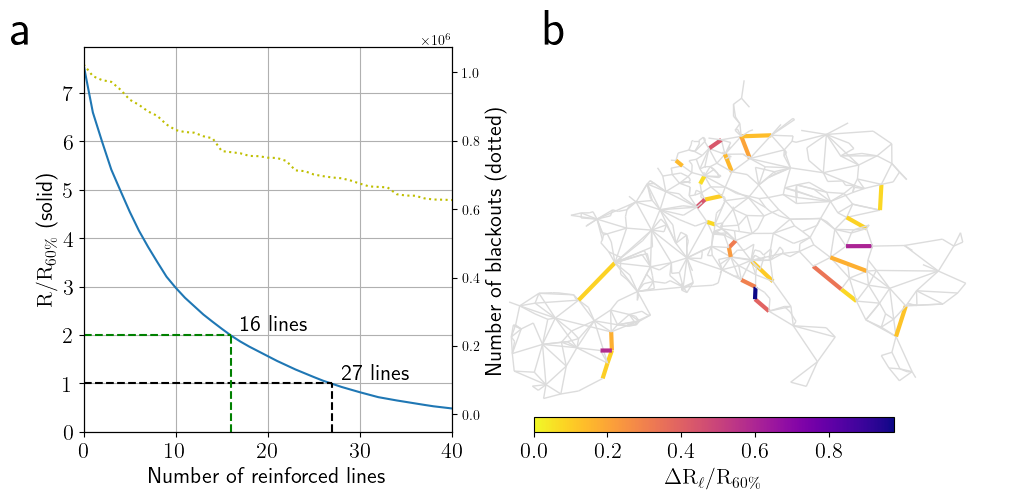

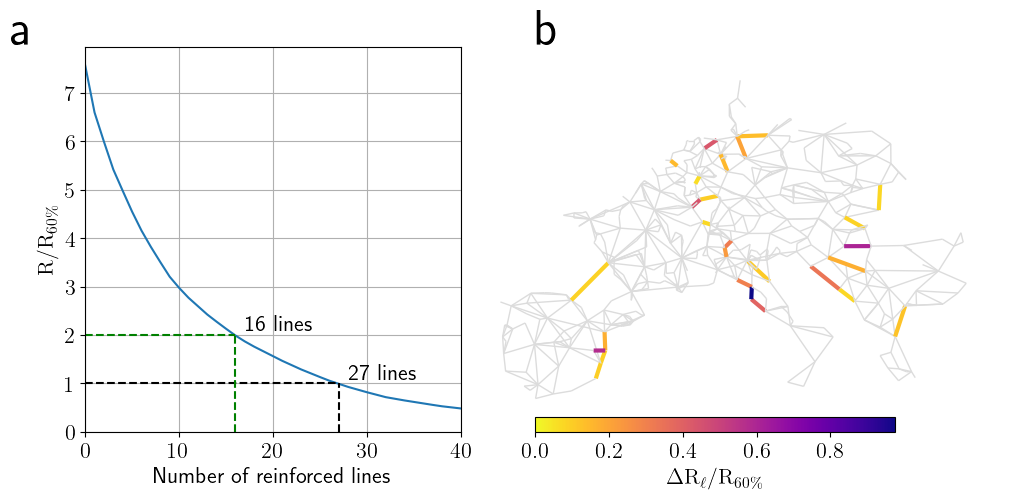

In [68]:
from utils.config import path_to_line_extension_mitigation_sclopf

co2l_ref=0.6
split_properties_reference = split_properties[split_properties.co2l == co2l_ref].copy()
lost_load_reference_lvl = split_properties_reference.lost_load_share_blackout.sum()

for co2l in [0.0, 0.1]:
    try:
        reinforced_lines, loss_with_mitigation, num_blackouts = pickle.load(open(path_to_line_extension_mitigation_sclopf + f"heuristic_loss_mitigation_Co2L{co2l}_n{n_nodes}.pkl", "rb"))
    except FileNotFoundError:
        split_props_lvl = pd.read_csv(path_to_evaluation_results_sclopf + f"split_properties_Co2L{co2l}_n{n_nodes}.csv", index_col=0)
        remaining_splits = split_props_lvl[split_props_lvl.lost_load_share_blackout>0]
        remaining_splits = remaining_splits.loc[:, ["lost_load_share_blackout","init_failure_0", "init_failure_1"]]

        loss_with_mitigation = [split_props_lvl.lost_load_share_blackout.sum()]
        reinforced_lines = []
        num_blackouts = [remaining_splits.shape[0]]

        while remaining_splits.shape[0]>0:
            trigger0 = remaining_splits.loc[:,["lost_load_share_blackout","init_failure_0"],].groupby("init_failure_0").sum()
            trigger1 = remaining_splits.loc[:,["lost_load_share_blackout","init_failure_1"],].groupby("init_failure_1").sum()
            trigger1.rename_axis("trigger", inplace=True)
            trigger0.rename_axis("trigger", inplace=True)
            loss_by_trigger = pd.Series(index=list(range(n_lines)), data=0)
            loss_by_trigger.rename_axis("trigger", inplace=True)
            loss_by_trigger = loss_by_trigger.add(trigger0.lost_load_share_blackout, fill_value=0)
            loss_by_trigger = loss_by_trigger.add(trigger1.lost_load_share_blackout, fill_value=0)

            trigger = loss_by_trigger.idxmax()
            remaining_splits = remaining_splits[(remaining_splits.init_failure_1!=trigger) & (remaining_splits.init_failure_0!=trigger)]
            loss_with_mitigation.append(remaining_splits.lost_load_share_blackout.sum())
            reinforced_lines.append(trigger)
            num_blackouts.append(remaining_splits.shape[0])

        with open(path_to_line_extension_mitigation_sclopf + f"heuristic_loss_mitigation_Co2L{co2l}_n{n_nodes}.pkl", "wb") as f:
            pickle.dump((reinforced_lines, loss_with_mitigation, num_blackouts), f)

        reinforced_lines_selected = np.array(reinforced_lines[:num_lines_to_reach_ref_loss]).astype(int)
        lines_not_extended = np.setdiff1d(np.arange(n_lines), reinforced_lines_selected)
        reinforced_lines_full = list(reinforced_lines_selected) + list(lines_not_extended)

    mpl.style.use('default')
    plt.rc('text', usetex=True)
    plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

    for plot_cost in [True, False]:

        num_lines_to_reach_ref_loss = np.where(loss_with_mitigation < lost_load_reference_lvl)[0][0]
        num_lines_to_reach_double_ref_loss = np.where(loss_with_mitigation < 2*lost_load_reference_lvl)[0][0]

        # fig, (ax, ax_map) = plt.subplots(1,2, figsize=(12,5))
        fig = plt.figure(figsize=(12,5))
        
        # gs = GridSpec(1, 2, figure=f)
        if plot_cost:
            wspace=0.02
        else:
            wspace=-0.02
        gs_vertical = GridSpec(1, 2, figure=f, width_ratios=[1.2,1.8], wspace=wspace)
        ax = fig.add_subplot(gs_vertical[0])
        ax_map = fig.add_subplot(gs_vertical[1])
        
        ax.plot(np.arange(len(loss_with_mitigation)),np.array(loss_with_mitigation)/lost_load_reference_lvl)

        if plot_cost:
            # add second y axis
            ax2 = ax.twinx()
            ax2.plot(np.arange(len(num_blackouts)),num_blackouts, color='y', linestyle='dotted')
            ax2.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
            ax2.set_ylabel('Number of blackouts (dotted)', fontsize=16)
        
        right_xlim = np.where(loss_with_mitigation/lost_load_reference_lvl < 0.5)[0][0]
        ax.plot([0, num_lines_to_reach_ref_loss], [1,1], '--', c='k')
        ax.plot([num_lines_to_reach_ref_loss, num_lines_to_reach_ref_loss], [0,1], '--', c='k')
        ax.text(num_lines_to_reach_ref_loss + right_xlim/200*5, 1, f"{num_lines_to_reach_ref_loss} lines", verticalalignment='bottom', horizontalalignment='left', zorder=np.inf, fontsize=16)
        ax.plot([0, num_lines_to_reach_double_ref_loss], [2,2], '--', c='g')
        ax.plot([num_lines_to_reach_double_ref_loss, num_lines_to_reach_double_ref_loss], [0,2], '--', c='g')
        ax.text(num_lines_to_reach_double_ref_loss + right_xlim/200*5, 2, f"{num_lines_to_reach_double_ref_loss} lines", verticalalignment='bottom', horizontalalignment='left', zorder=np.inf, fontsize=16)
        ax.set_xlim(0,right_xlim)
        ax.set_ylim(bottom=00)
        # increase tick fontsize
        ax.tick_params(axis='both', which='major', labelsize=16)
        
        ax.set_xlabel('Number of reinforced lines')
        y_label = "$\\textrm{R}/\\textrm{R}_{\\textrm{co2refString}}$"
        y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
        y_label = y_label.replace("co2refString", str(int(100 * co2l_ref)) + "\%")
        if plot_cost:
            y_label += " (solid)"
        ax.set_ylabel(y_label, fontsize=16)
        ax.grid()
        # increase xlabel fontsize
        ax.xaxis.label.set_size(16)

        fname = "loss_reduction_"
        if plot_cost:
            fname += "blackouts_"
        fname += f"vs_reinforced_lines_CO2{co2l}.pdf"
        
        reinforced_lines_selected = reinforced_lines[:num_lines_to_reach_ref_loss]
        lines_not_extended = np.setdiff1d(np.arange(n_lines), reinforced_lines_selected)
        reinforced_lines_full = reinforced_lines_selected + list(lines_not_extended)
        mitigated_loss = np.array([loss_with_mitigation[i] - loss_with_mitigation[i+1] for i in range(len(loss_with_mitigation)-1)])
        mitigated_loss = np.concatenate((mitigated_loss,-np.ones(n_lines - len(mitigated_loss))))
        mitigated_loss_sorted = mitigated_loss[np.argsort(reinforced_lines_full)]
        mitigated_loss_selected = -np.ones(n_lines)
        # Convert reinforced_lines_selected to integer indices
        reinforced_lines_selected_int = np.array(reinforced_lines_selected).astype(int)
        mitigated_loss_selected[reinforced_lines_selected_int] = mitigated_loss[:num_lines_to_reach_ref_loss]/lost_load_reference_lvl

        width= 2*(mitigated_loss_selected>0).astype(int) + 1
        # cmap = "cividis_r"
        # cmap = plt.get_cmap('cividis_r')
        cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
        cmap.set_under('gainsboro', 1.0)

        nodes = nx.draw_networkx_nodes(nx_graph,
                                    pos=pos,
                                    ax=ax_map,
                                    node_color='black',
                                    node_size=0)

        edges = nx.draw_networkx_edges(nx_graph,
                                    pos=pos,
                                    ax=ax_map,
                                    # edge_color=mitigated_loss_selected/mitigated_loss_selected.max(),
                                    edge_color=mitigated_loss_selected,
                                    width=width,
                                    edge_cmap=cmap,
                                    edge_vmin=0,
                                    # edge_vmax=np.log10(vmax)
                                    )
        ax_map_legend = fig.add_axes([0.5, 0.11, 0.3, 0.03])
        y_label = "$\Delta \\textrm{R}_{{\\ell}}/\\textrm{R}_{\\textrm{co2refString}}$"
        y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
        y_label = y_label.replace("co2refString", str(int(100 * co2l_ref)) + "\%")
        cbar = plt.colorbar(edges, ax=ax_map, cax=ax_map_legend, label=y_label, shrink=0.5, orientation="horizontal")
        # increase cbar fontsize
        cbar.ax.tick_params(labelsize=16)
        # increase cbar label fontsize
        cbar.ax.set_xlabel(y_label, fontsize=16)
        
        ax_map.axis("off")
        
        ax.text(0 - 0.2, 1+0.04,
                "a",
                fontsize=36,
                weight='bold',
                verticalalignment='center',
                transform=ax.transAxes)
        
        ax_map.text(0 + 0.15, 1+0.04,
                "b",
                fontsize=36,
                weight='bold',
                verticalalignment='center',
                transform=ax_map.transAxes)

        plt.savefig(save_path+fname, bbox_inches='tight')

## cost

In [60]:
from utils.cascade_simulation import LOOKUP_TABLE_NP
table_rounded = np.round(LOOKUP_TABLE_NP, 5)
num_par_paths = {}
for tup in table_rounded:
    current_tup = tup
    num_par_paths[tup[0]] = [current_tup[0]-current_tup[1]]
    while current_tup[1]!= 0:
        current_tup = table_rounded[np.where((table_rounded[:,0]==current_tup[1]))[0][0]]
        num_par_paths[tup[0]].append(current_tup[0]-current_tup[1])
max_num_par = {k: max(v) for k, v in num_par_paths.items()}


In [61]:
costs_ = networks[0.0].lines.copy()
costs_ = costs_.loc[:, ["bus0", "bus1", "capital_cost", "s_nom", "num_parallel"]].copy()
costs_["num_par_ext"] = costs_.num_parallel.apply(lambda x: max_num_par[np.round(x,5)] if x in max_num_par else 1)
costs_["extension_cost"] = costs_.capital_cost * costs_.s_nom * costs_.num_par_ext

In [62]:
brances = networks[0.6].lines.copy()
branches["cost_per_km"] = branches.capital_cost/branches.length

array([[<Axes: title={'center': 'cost_per_km'}>]], dtype=object)

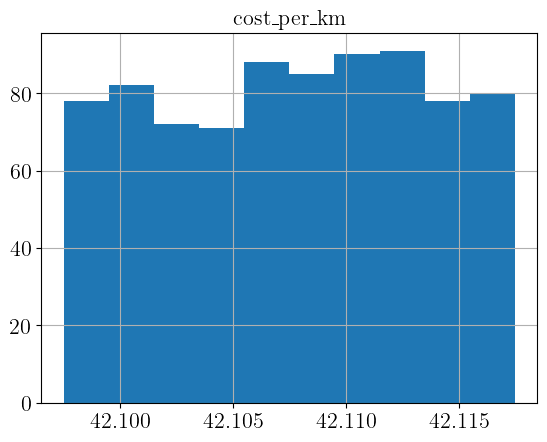

In [63]:
branches[["type", "cost_per_km"]].hist()

Text(0.5, 1.0, 'Distribution of capital costs of lines in the network')

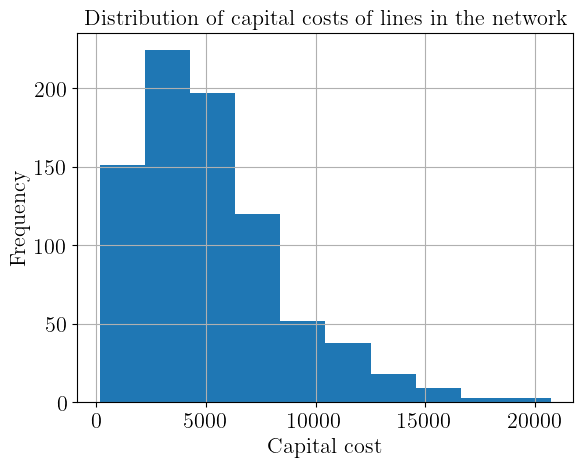

In [64]:
branches.capital_cost.hist()
plt.xlabel("Capital cost")
plt.ylabel("Frequency")
plt.title("Distribution of capital costs of lines in the network")

In [83]:
branches[["num_parallel", "x", "type", "length", "s_nom"]]

num_parallel          x                         type  \
Line 0_outage        1.000000  72.518630  Al/St 240/40 4-bundle 380.0   
     1_outage        1.289474  35.552912  Al/St 240/40 4-bundle 380.0   
     10_outage       0.868421  24.609204  Al/St 240/40 4-bundle 380.0   
     100_outage      1.000000  24.667681  Al/St 240/40 4-bundle 380.0   
     101_outage      2.000000  18.507571  Al/St 240/40 4-bundle 380.0   
...                       ...        ...                          ...   
     989_outage      1.000000  59.008276  Al/St 240/40 4-bundle 380.0   
     99_outage       2.578947   5.424022  Al/St 240/40 4-bundle 380.0   
     990_outage      1.000000  38.620676  Al/St 240/40 4-bundle 380.0   
     991_outage      2.578947   9.710894  Al/St 240/40 4-bundle 380.0   
     992_outage      0.578947  25.329841  Al/St 240/40 4-bundle 380.0   

                     length        s_nom  
Line 0_outage    294.791179  1698.102612  
     1_outage    186.359938  2189.658631  
     10_outage    86.874599  1474.668058  
     100_outage  100.275125  1698.102612  
     101_outage  150.468055  3396.205223  
...                     ...          ...  
     989_outage  239.871039  1698.102612  
     99_outage    56.862871  4379.317262  
     990_outage  156.994616  1698.102612  
     991_outage  101.804411  4379.317262  
     992_outage   59.612378   983.112038  

[815 rows x 5 columns]

<Axes: >

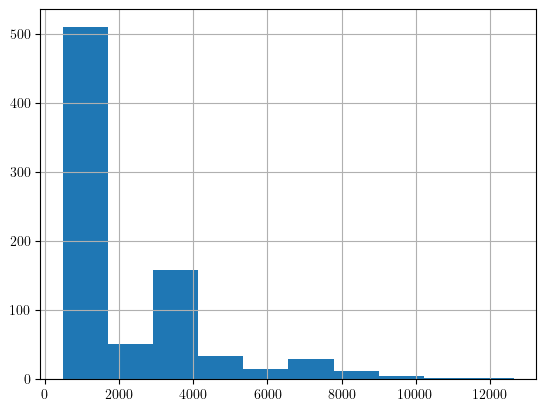

In [88]:
branches.s_nom.hist()

In [66]:
def calculate_investment_cost(eac, r, n):
    """
    Calculate upfront investment cost.
    
    Parameters:
    eac (float): Equivalent Annual Cost
    r (float): Discount rate (as decimal, e.g., 0.08 for 8%)
    n (int): Lifespan in years

    Returns:
    float: Upfront investment cost
    """
    annuity_factor = (1 - (1 + r) ** -n) / r
    return eac * annuity_factor

# Example
eac = 42  # annual cost
r = 0.085    # 8% discount rate
n = 40      # 10-year lifespan

investment_cost = calculate_investment_cost(eac, r, n)
print(f"Upfront Investment Cost: ${investment_cost:.2f}")

Upfront Investment Cost: $475.21


/tmp/ipykernel_1484766/4251949033.py:131: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
/tmp/ipykernel_1484766/4251949033.py:131: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
/tmp/ipykernel_1484766/4251949033.py:131: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
/tmp/ipykernel_1484766/4251949033.py:131: MatplotlibDeprecationWarning: The get

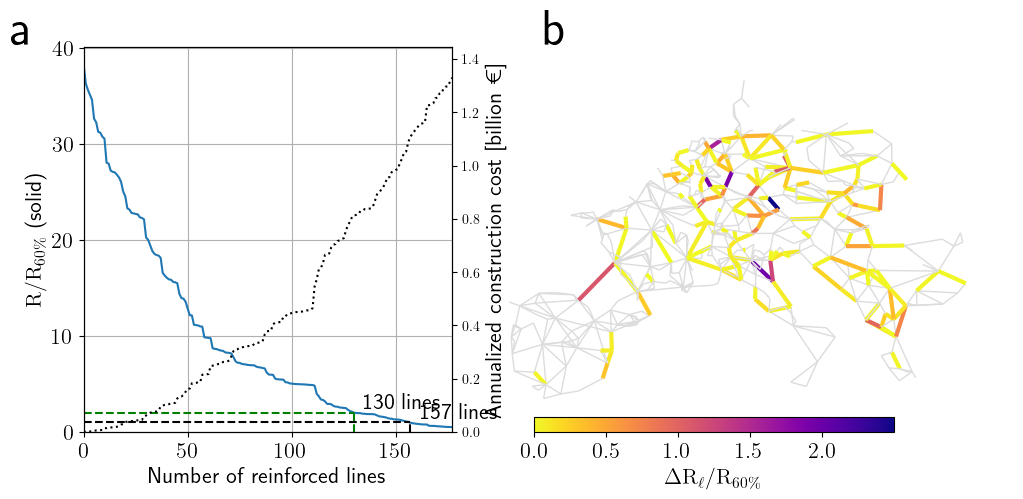

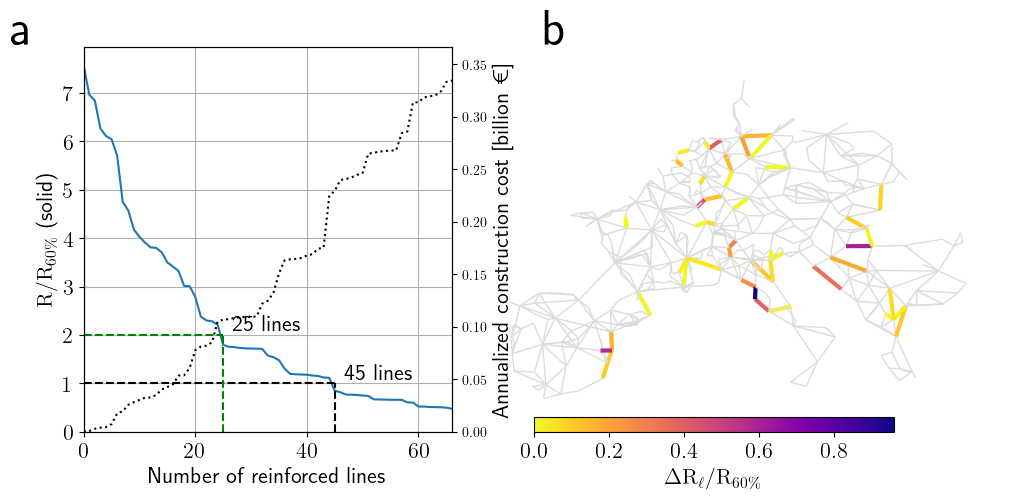

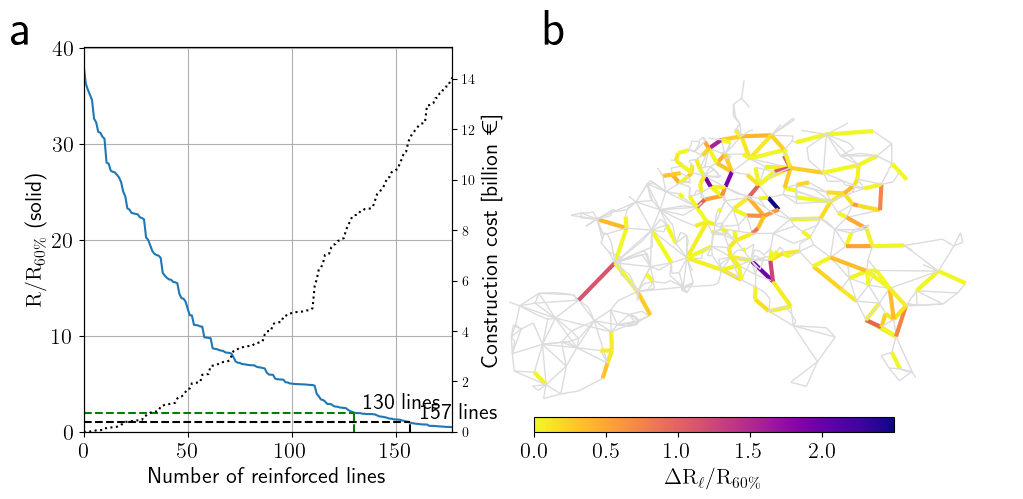

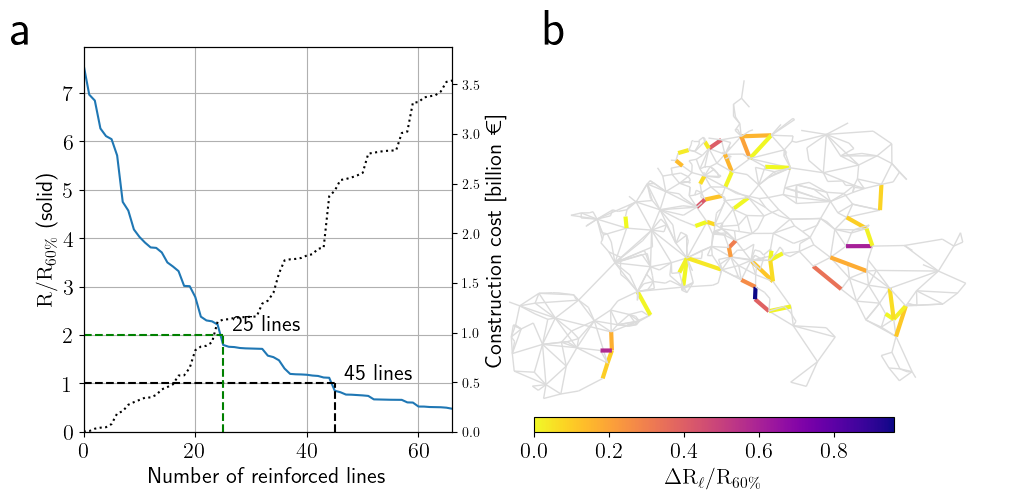

In [79]:
from utils.config import path_to_line_extension_mitigation_sclopf

co2l_ref=0.6
split_properties_reference = split_properties[split_properties.co2l == co2l_ref].copy()
lost_load_reference_lvl = split_properties_reference.lost_load_share_blackout.sum()
extension_cost_per_MWkm = 445
for annualized_costs in [True, False]:
    for co2l in [0.0, 0.1]:
        try:
            reinforced_lines, loss_with_mitigation, num_blackouts, cost = pickle.load(open(path_to_line_extension_mitigation_sclopf + f"_heuristic_costMin_loss_mitigation_Co2L{co2l}_n{n_nodes}.pkl", "rb"))
        except FileNotFoundError:
            split_props_lvl = split_properties[split_properties.co2l == co2l].copy()
            split_props_lvl.lost_load_share_blackout = split_props_lvl.lost_load_share_blackout.astype(float)
            remaining_splits = split_props_lvl[split_props_lvl.lost_load_share_blackout>0]
            remaining_splits = remaining_splits.loc[:, ["lost_load_share_blackout","init_failure_0", "init_failure_1"]]
            costs_ = branches.loc[:, ["bus0", "bus1", "capital_cost", "s_nom", "num_parallel", "length"]].copy()
            costs_["num_par_ext"] = costs_.num_parallel.apply(lambda x: max_num_par[np.round(x,5)] if x in max_num_par else 1)
            if annualized_costs:
                costs_["extension_cost"] = costs_.capital_cost * costs_.s_nom * costs_.num_par_ext
            else:
                costs_["extension_cost"] = extension_cost_per_MWkm * costs_.s_nom * costs_.num_par_ext * costs_.length

            loss_with_mitigation = [split_props_lvl.lost_load_share_blackout.sum()]
            reinforced_lines = []
            cost = []
            num_blackouts = [remaining_splits.shape[0]]

            while remaining_splits.shape[0]>0:
                trigger0 = remaining_splits.loc[:,["lost_load_share_blackout","init_failure_0"],].groupby("init_failure_0").sum()
                trigger1 = remaining_splits.loc[:,["lost_load_share_blackout","init_failure_1"],].groupby("init_failure_1").sum()
                trigger1.rename_axis("trigger", inplace=True)
                trigger0.rename_axis("trigger", inplace=True)
                loss_by_trigger = pd.Series(index=list(range(n_lines)), data=0)
                loss_by_trigger.rename_axis("trigger", inplace=True)
                loss_by_trigger = loss_by_trigger.add(trigger0.lost_load_share_blackout, fill_value=0)
                loss_by_trigger = loss_by_trigger.add(trigger1.lost_load_share_blackout, fill_value=0)
                loss_per_dollar = loss_by_trigger / costs_["extension_cost"].reset_index(drop=True)

                trigger = loss_per_dollar.idxmax()
                cost.append(costs_["extension_cost"][int(trigger)])
                remaining_splits = remaining_splits[(remaining_splits.init_failure_1!=trigger) & (remaining_splits.init_failure_0!=trigger)]
                loss_with_mitigation.append(remaining_splits.lost_load_share_blackout.sum())
                reinforced_lines.append(trigger)
                num_blackouts.append(remaining_splits.shape[0])

            with open(path_to_line_extension_mitigation_sclopf + f"heuristic_costMin_loss_mitigation_Co2L{co2l}_n{n_nodes}.pkl", "wb") as f:
                pickle.dump((reinforced_lines, loss_with_mitigation, num_blackouts, cost), f)

            # latexreinforced_lines_selected = np.array(reinforced_lines[:num_lines_to_reach_ref_loss]).astype(int)
            # lines_not_extended = np.setdiff1d(np.arange(n_lines), reinforced_lines_selected)
            # reinforced_lines_full = list(reinforced_lines_selected) + list(lines_not_extended)

        mpl.style.use('default')
        plt.rc('text', usetex=True)
        plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

        for plot_cost in [True]:

            num_lines_to_reach_ref_loss = np.where(loss_with_mitigation < lost_load_reference_lvl)[0][0]
            num_lines_to_reach_double_ref_loss = np.where(loss_with_mitigation < 2*lost_load_reference_lvl)[0][0]

            # fig, (ax, ax_map) = plt.subplots(1,2, figsize=(12,5))
            fig = plt.figure(figsize=(12,5))
            
            # gs = GridSpec(1, 2, figure=f)
            if plot_cost:
                wspace=0.02
            else:
                wspace=-0.02
            gs_vertical = GridSpec(1, 2, figure=fig, width_ratios=[1.2,1.8], wspace=wspace)
            ax = fig.add_subplot(gs_vertical[0])
            ax_map = fig.add_subplot(gs_vertical[1])
            
            ax.plot(np.arange(len(loss_with_mitigation)),np.array(loss_with_mitigation)/lost_load_reference_lvl)

            right_xlim = np.where(loss_with_mitigation/lost_load_reference_lvl < 0.5)[0][0]
            
            if plot_cost:
                # add second y axis
                ax2 = ax.twinx()
                ax2.plot(np.arange(len(cost)),np.cumsum(cost)/1e9, color='black', linestyle='dotted')
                # ax2.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
                if annualized_costs:
                    y_lable_cost = 'Annualized construction cost [billion €]'
                else:
                    y_lable_cost = 'Construction cost [billion €]'
                ax2.set_ylabel(y_lable_cost, fontsize=16)
                ax2.set_ylim((0, 1.1*sum(cost[:right_xlim])/1e9))
            
            ax.plot([0, num_lines_to_reach_ref_loss], [1,1], '--', c='k')
            ax.plot([num_lines_to_reach_ref_loss, num_lines_to_reach_ref_loss], [0,1], '--', c='k')
            ax.text(num_lines_to_reach_ref_loss + right_xlim/200*5, 1, f"{num_lines_to_reach_ref_loss} lines", verticalalignment='bottom', horizontalalignment='left', zorder=np.inf, fontsize=16)
            ax.plot([0, num_lines_to_reach_double_ref_loss], [2,2], '--', c='g')
            ax.plot([num_lines_to_reach_double_ref_loss, num_lines_to_reach_double_ref_loss], [0,2], '--', c='g')
            ax.text(num_lines_to_reach_double_ref_loss + right_xlim/200*5, 2, f"{num_lines_to_reach_double_ref_loss} lines", verticalalignment='bottom', horizontalalignment='left', zorder=np.inf, fontsize=16)
            ax.set_xlim(0,right_xlim)
            ax.set_ylim(bottom=00)
            # increase tick fontsize
            ax.tick_params(axis='both', which='major', labelsize=16)
            
            ax.set_xlabel('Number of reinforced lines')
            y_label = "$\\textrm{R}/\\textrm{R}_{\\textrm{co2refString}}$"
            y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
            y_label = y_label.replace("co2refString", str(int(100 * co2l_ref)) + "\%")
            if plot_cost:
                y_label += " (solid)"
            ax.set_ylabel(y_label, fontsize=16)
            ax.grid()
            # increase xlabel fontsize
            ax.xaxis.label.set_size(16)

            fname = "costOpt_loss_reduction_blackouts_vs_reinforced_lines_costMin"
            if annualized_costs:
                fname += "annualized"
            fname += f"_CO2{co2l}.pdf"
            
            reinforced_lines_selected = reinforced_lines[:num_lines_to_reach_ref_loss]
            lines_not_extended = np.setdiff1d(np.arange(n_lines), reinforced_lines_selected)
            reinforced_lines_full = reinforced_lines_selected + list(lines_not_extended)
            mitigated_loss = np.array([loss_with_mitigation[i] - loss_with_mitigation[i+1] for i in range(len(loss_with_mitigation)-1)])
            mitigated_loss = np.concatenate((mitigated_loss,-np.ones(n_lines - len(mitigated_loss))))
            mitigated_loss_sorted = mitigated_loss[np.argsort(reinforced_lines_full)]
            mitigated_loss_selected = -np.ones(n_lines)
            # Convert reinforced_lines_selected to integer indices
            reinforced_lines_selected_int = np.array(reinforced_lines_selected).astype(int)
            mitigated_loss_selected[reinforced_lines_selected_int] = mitigated_loss[:num_lines_to_reach_ref_loss]/lost_load_reference_lvl

            width= 2*(mitigated_loss_selected>0).astype(int) + 1
            # cmap = "cividis_r"
            # cmap = plt.get_cmap('cividis_r')
            cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
            cmap.set_under('gainsboro', 1.0)

            nodes = nx.draw_networkx_nodes(nx_graph,
                                        pos=pos,
                                        ax=ax_map,
                                        node_color='black',
                                        node_size=0)

            edges = nx.draw_networkx_edges(nx_graph,
                                        pos=pos,
                                        ax=ax_map,
                                        # edge_color=mitigated_loss_selected/mitigated_loss_selected.max(),
                                        edge_color=mitigated_loss_selected,
                                        width=width,
                                        edge_cmap=cmap,
                                        edge_vmin=0,
                                        # edge_vmax=np.log10(vmax)
                                        )
            ax_map_legend = fig.add_axes([0.5, 0.11, 0.3, 0.03])
            y_label = "$\Delta \\textrm{R}_{{\\ell}}/\\textrm{R}_{\\textrm{co2refString}}$"
            y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
            y_label = y_label.replace("co2refString", str(int(100 * co2l_ref)) + "\%")
            cbar = plt.colorbar(edges, ax=ax_map, cax=ax_map_legend, label=y_label, shrink=0.5, orientation="horizontal")
            # increase cbar fontsize
            cbar.ax.tick_params(labelsize=16)
            # increase cbar label fontsize
            cbar.ax.set_xlabel(y_label, fontsize=16)
            
            ax_map.axis("off")
            
            ax.text(0 - 0.2, 1+0.04,
                    "a",
                    fontsize=36,
                    weight='bold',
                    verticalalignment='center',
                    transform=ax.transAxes)
            
            ax_map.text(0 + 0.15, 1+0.04,
                    "b",
                    fontsize=36,
                    weight='bold',
                    verticalalignment='center',
                    transform=ax_map.transAxes)

            plt.savefig(save_path+fname, bbox_inches='tight')

In [76]:
costs_["extension_cost"] = extension_cost_per_MWkm * costs_.s_nom * costs_.num_par_ext * costs_.length


AttributeError: 'DataFrame' object has no attribute 'length'

In [ ]:
loss_per_dollar = loss_by_trigger / costs_["extension_cost"]

trigger
0.0      2368.488960
1.0      1362.394273
2.0      7534.205904
3.0       690.319361
4.0       245.965637
            ...     
810.0       0.000000
811.0     246.312890
812.0       0.000000
813.0       1.397611
814.0       1.397611
Length: 815, dtype: float64

In [121]:
costs_

,bus0,bus1,capital_cost,s_nom,num_parallel,num_par_ext,extension_cost
Line,,,,,,,
0_outage,AL1 0,GR1 0,12410.992549,1698.102612,1.000000,1.0,2.107514e+07
1_outage,AL1 0,ME1 0,7848.407698,2189.658631,1.289474,1.0,1.718533e+07
10_outage,AT1 0,DE1 38,3657.834193,1474.668058,0.868421,1.0,5.394091e+06
100_outage,CH1 3,CH1 6,4221.823968,1698.102612,1.000000,1.0,7.169090e+06
1000_outage,SE2 0,SE2 6,31636.721925,1698.102612,1.000000,1.0,5.372240e+07
...,...,...,...,...,...,...,...
995_outage,SE2 0,SE2 12,3218.745233,491.556019,0.289474,1.0,1.582194e+06
996_outage,SE2 0,SE2 13,12302.237647,1698.102612,1.000000,1.0,2.089046e+07
997_outage,SE2 0,SE2 16,11578.358141,491.556019,0.289474,1.0,5.691412e+06


In [ ]:
### n_lines and cost vs co2l to reach ref level

nan

## line extension order

In [ ]:
# fig, ax = plt.subplots()

# reinforced_lines_selected = reinforced_lines[:num_lines_to_reach_ref_loss]
# lines_not_extended = np.setdiff1d(np.arange(n_lines), reinforced_lines_selected)
# reinforced_lines_full = reinforced_lines_selected + list(lines_not_extended)
# mitigated_loss = np.array([loss_with_mitigation[i] - loss_with_mitigation[i+1] for i in range(len(loss_with_mitigation)-1)])
# mitigated_loss = np.concatenate((mitigated_loss,-np.ones(n_lines - len(mitigated_loss))))
# mitigated_loss_sorted = mitigated_loss[np.argsort(reinforced_lines_full)]
# mitigated_loss_selected = -np.ones(n_lines)
# mitigated_loss_selected[reinforced_lines_selected] = mitigated_loss[:num_lines_to_reach_ref_loss]

# width= 2*(mitigated_loss_selected>0).astype(int) + 1
# # cmap = "cividis_r"
# # cmap = plt.get_cmap('cividis_r')
# cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
# cmap.set_under('gainsboro', 1.0)

# nodes = nx.draw_networkx_nodes(nx_graph,
#                             pos=pos,
#                             ax=ax,
#                             node_color='black',
#                             node_size=0)

# edges = nx.draw_networkx_edges(nx_graph,
#                             pos=pos,
#                             ax=ax,
#                             edge_color=mitigated_loss_selected/mitigated_loss_selected.max(),
#                             width=width,
#                             edge_cmap=cmap,
#                             edge_vmin=0,
#                             # edge_vmax=np.log10(vmax)
#                             )

# plt.colorbar(edges, ax=ax, label='Normalized mitigated loss [a.u.]', shrink=0.5)
# plt.axis("off")

# communities

In [ ]:
a = centrality.eddge_current_flow_betweenness_centrality(nx_graph)

In [34]:
c = list(community.girvan_newman(nx_graph, most_valuable_edge=centrality.edge_current_flow_betweenness_centrality))

TypeError: Graph.remove_edge() takes 3 positional arguments but 816 were given

In [9]:
from networkx.algorithms import community

communities_all_k = list(community.girvan_newman(nx_graph))

Number of communities for k=8: 8
Number of communities for k=9: 9
Number of communities for k=10: 10
Number of communities for k=11: 11


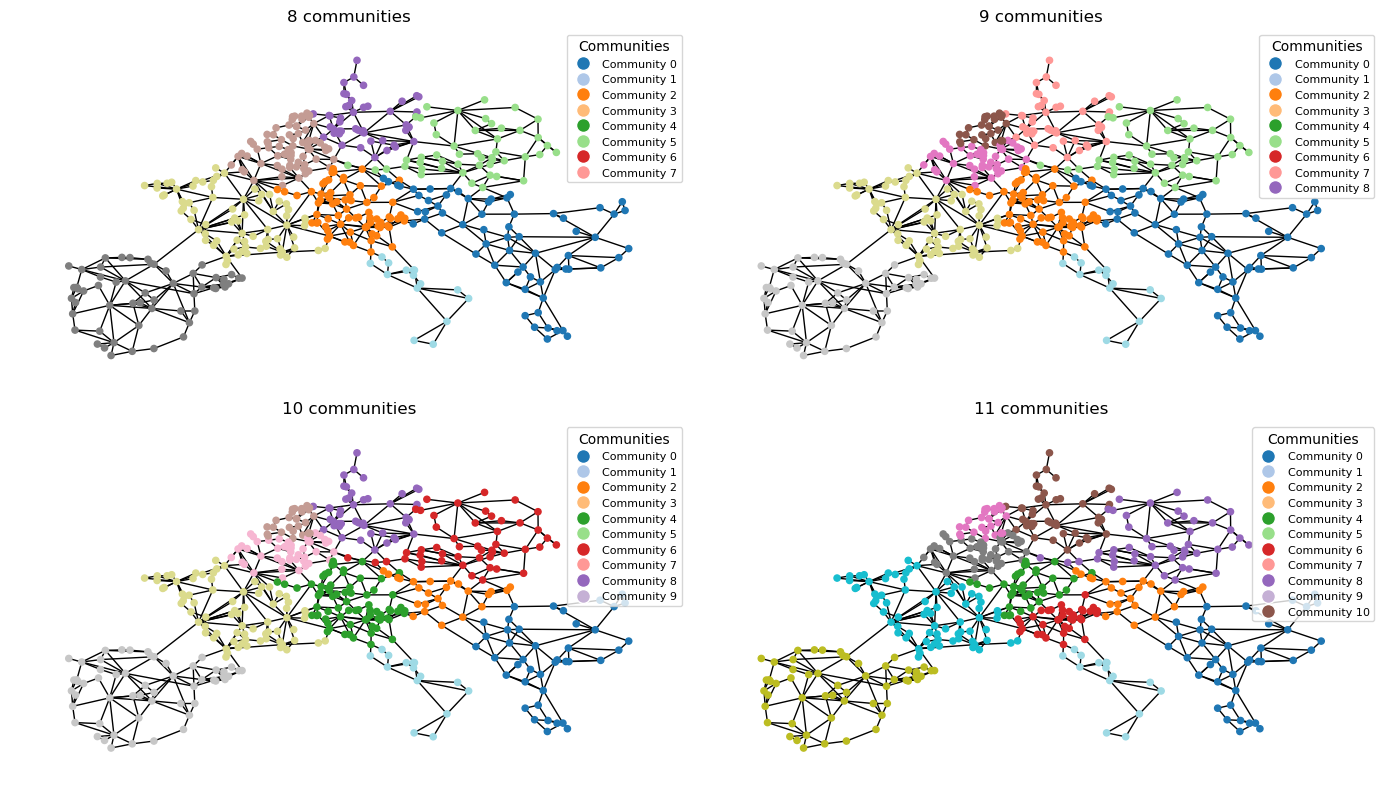

In [136]:
from matplotlib.lines import Line2D


fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
k_values = np.arange(8, 12)
# k_values = np.arange(2, 6)


for idx, k in enumerate(k_values):
    communities = communities_all_k[k-2]
    print(f"Number of communities for k={k}: {len(communities)}")
    # Use greedy modularity communities from networkx
    # communities = list(nx.algorithms.community.greedy_modularity_communities(nx_graph))
    # n_communities = None
    # while n_communities is None or n_communities != k:
    #     try:
    #         communities = list(nx.algorithms.community.greedy_modularity_communities(nx_graph, n_communities=k))
    #         n_communities = len(communities)
    #     except nx.exception.NetworkXError:
    #         n_communities = None
    # communities = list(nx.algorithms.community.louvain_partitions(nx_graph, threshold=threshold, resolution=1.0))
    # communities = list(nx.community.edge_current_flow_betweenness_partition(nx_graph, k, weight='weight'))
    # Sort communities by size and merge/split to get approximately k communities
    # comms = sorted(communities, key=lambda x: -len(x))
    # while len(comms) > k:
    #     # Merge two smallest
    #     c1 = comms.pop()
    #     c2 = comms.pop()
    #     comms.append(c1.union(c2))
    #     comms = sorted(comms, key=lambda x: -len(x))
    # Assign new community labels
    node_colors = np.zeros(nx_graph.number_of_nodes())
    node2idx = {n: i for i, n in enumerate(nx_graph.nodes())}
    for i, nodes in enumerate(communities):
        for n in nodes:
            node_colors[node2idx[n]] = i
    ax = axes[idx]
    cmap = plt.cm.tab20
    # cmap.set_under('gainsboro', 1.0)  # Set under color for nodes not in any community
    # cmap.vmin = 0
    
    nx.draw(nx_graph, pos, node_color=node_colors, cmap=cmap, node_size=20, ax=ax, with_labels=False)
    # Create a legend for community colors

    handles = [Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=cmap(i), markersize=10, label=f'Community {i}')
               for i in range(len(communities))]
    ax.legend(handles=handles, loc='upper right', fontsize=8, title='Communities')
    ax.set_title(f"{k} communities")
    ax.axis('off')
plt.tight_layout()
plt.show()


In [11]:
com = communities_all_k[9]

In [12]:
com_inverted = {n: i for i, nodes in enumerate(com) for n in nodes}

In [96]:
n.carriers

,co2_emissions,color,nice_name,max_growth,max_relative_growth
Carrier,,,,,
AC,0.0000,#70af1d,AC,inf,0.0
DC,0.0000,#8a1caf,DC,inf,0.0
biomass,0.0000,#baa741,biomass,inf,0.0
oil,0.2571,#c9c9c9,oil,inf,0.0
nuclear,0.0000,#ff8c00,nuclear,inf,0.0
coal,0.3361,#545454,coal,inf,0.0
CCGT,0.1980,#a85522,Combined-Cycle Gas,inf,0.0
lignite,0.4069,#826837,lignite,inf,0.0
OCGT,0.1980,#e0986c,Open-Cycle Gas,inf,0.0


In [116]:
gen_year = n.generators_t["p"].sum(axis=0).astype(int).to_frame()
gen_year.columns = ["gen_year"]
gen_year["carrier"] = gen_year.index.str.split(" ").str[-1]
gen_year["bus"] = gen_year.index.map(lambda x: " ".join(x.split(" ")[:-1]))
gen_year["community"] = gen_year.bus.map(com_inverted)

com_car_groups = gen_year.groupby(["community", "carrier"])
com_gen_year = com_car_groups.gen_year.sum().astype(int)


In [13]:
n = networks[0.0]
n.generators["community"] = n.generators.bus.map(com_inverted)
n.generators["community"]

Generator
AL1 0 offwind-ac       0.0
AL1 0 offwind-float    0.0
AL1 0 oil              0.0
AL1 0 onwind           0.0
AL1 0 ror              0.0
                      ... 
SK1 0 art_load         4.0
SK1 1 art_load         4.0
SK1 2 art_load         4.0
SK1 3 art_load         4.0
SK1 4 art_load         4.0
Name: community, Length: 4074, dtype: float64

In [28]:
com_car_groups = n.generators.groupby(["community", "carrier"])
com_gen_sums = com_car_groups.p_nom.sum().astype(int)

In [119]:
n.carriers.color

Carrier
AC               #70af1d
DC               #8a1caf
biomass          #baa741
oil              #c9c9c9
nuclear          #ff8c00
coal             #545454
CCGT             #a85522
lignite          #826837
OCGT             #e0986c
geothermal       #ba91b1
onwind           #235ebc
offwind-float    #b5e2fa
offwind-dc       #74c6f2
hydro            #298c81
offwind-ac       #6895dd
solar            #f9d002
solar-hsat       #fdb915
PHS              #51dbcc
ror              #3dbfb0
                        
battery          #ace37f
H2               #bf13a0
load             #dd2e23
art_load         #38761d
Name: color, dtype: object

<Axes: xlabel='community'>

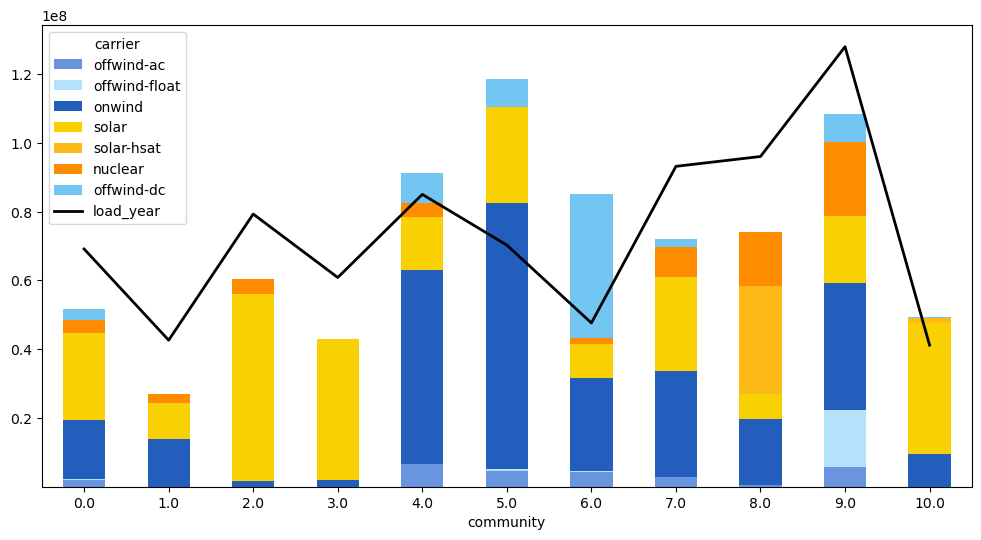

In [121]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_carriers = [carrier for carrier in n.generators.carrier.unique() if "nuclear" in carrier or "solar" in carrier or "wind" in carrier]
colors = [n.carriers.color[carrier] for carrier in plot_carriers]
com_gen_year.unstack()[plot_carriers].plot.bar(stacked=True, ax=ax, color=colors)

load_sum = n.loads_t["p"].sum(axis=0).astype(int).to_frame()
load_sum.columns = ["load_year"]
load_sum["community"] = list(load_sum.index.map(com_inverted))
load_sum.groupby("community").sum().plot(ax=ax, color='black', linewidth=2, label='Total Load')

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
com_gen_sums.unstack()[[carrier for carrier in n.generators.carrier.unique() if "nuclear" in carrier or "solar" in carrier or "wind" in carrier]].plot.bar(stacked=True, ax=ax)

load_sum = n.loads_t["p"].sum(axis=0).astype(int).to_frame()
load_sum.columns = ["load_year"]
load_sum["community"] = list(load_sum.index.map(com_inverted))
load_sum.groupby("community").sum().plot(ax=ax)

In [ ]:
load_sum = n.loads_t["p"].sum(axis=0).astype(int).to_frame()
load_sum.columns = ["load_year"]
load_sum["community"] = list(load_sum.index.map(com_inverted))
load_sum.groupby("community").sum().plot(ax=ax)

,load_year
Load,
AL1 0,2248162
AT1 0,3531617
AT1 1,7554199
AT1 10,754849
AT1 11,534396
...,...
SK1 0,4264041
SK1 1,2442479
SK1 2,1295144


In [90]:
load_sum.groupby("community").sum().plot(ax=ax)

<Axes: xlabel='community'>

In [ ]:
com_groups = n.generators.groupby(["community", "carrier"])
com_groups